In [1]:
# ============================================================
# CÉLULA 0 — Imports e funções auxiliares
# ============================================================

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import (
    chi2_contingency, mannwhitneyu, kruskal,
    spearmanr, norm
)
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.multitest import multipletests
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import os
import warnings
warnings.filterwarnings('ignore')

from athena_client import query

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

OUTPUT = os.path.expanduser('~/sus-saude-mental-analytics/output')
os.makedirs(OUTPUT, exist_ok=True)


# ------------------------------------------------------------
# Registro global de p-valores para correção FDR
# ------------------------------------------------------------
_pvalues_registry = []

def register_p(nome_teste, p_raw):
    """Registra p-valor bruto para correção FDR global posterior."""
    _pvalues_registry.append({'teste': nome_teste, 'p_raw': float(p_raw)})


# ------------------------------------------------------------
# Tamanho de efeito
# ------------------------------------------------------------

def cramers_v(chi2, n, r, c):
    """
    V de Cramér — tamanho de efeito para qui-quadrado.
    Benchmarks: ~0.10 pequeno | ~0.30 médio | ~0.50 grande.
    """
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))


def rank_biserial(u_stat, n1, n2):
    """
    Correlação rank-biserial — tamanho de efeito para Mann-Whitney.
    Benchmarks: ~0.10 pequeno | ~0.30 médio | ~0.50 grande.
    """
    return 1 - (2 * u_stat) / (n1 * n2)


def eta_squared_kruskal(h_stat, n, k):
    """
    η² — tamanho de efeito para Kruskal-Wallis.
    Benchmarks: ~0.01 pequeno | ~0.06 médio | ~0.14 grande.
    """
    return (h_stat - k + 1) / (n - k)


def effect_size_label(v, thresholds=(0.10, 0.30, 0.50)):
    """Classifica magnitude de efeito."""
    v = abs(v)
    if v >= thresholds[2]: return 'grande'
    if v >= thresholds[1]: return 'médio'
    if v >= thresholds[0]: return 'pequeno'
    return 'negligível'


def sig_label(p):
    """Rótulo de significância no formato APA."""
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


# ------------------------------------------------------------
# Decodificação de idade do SINAN
# ------------------------------------------------------------

def parse_idade_sinan(val):
    """
    Decodifica idade no formato SINAN.
    Primeiro dígito = unidade (1=dias, 2=meses, 3=anos<1, 4=anos).
    Retorna idade em anos para unidade 4, NaN para demais.
    """
    try:
        v       = int(val)
        unidade = v // 1000
        valor   = v % 1000
        return valor if unidade == 4 else np.nan
    except:
        return np.nan


# ------------------------------------------------------------
# Dicionários de categoria — definidos uma vez, usados em todo notebook
# ------------------------------------------------------------

RACA_MAP = {
    '01': 'Branca', '02': 'Preta', '03': 'Parda',
    '04': 'Amarela', '05': 'Indígena'
}
SEXO_MAP     = {'1': 'Masculino', '3': 'Feminino'}
SEXO_SINAN   = {'M': 'Masculino', 'F': 'Feminino'}
RACA_SINAN   = {
    '1': 'Branca', '2': 'Preta', '3': 'Amarela',
    '4': 'Parda',  '5': 'Indígena'
}
RACAS_ANALISE = ['Branca', 'Parda', 'Preta']

CID_MAP = {
    'F200': 'Esquizofrenia paranoide',  'F192': 'Múltiplas drogas',
    'F102': 'Dependência álcool',       'F29' : 'Psicose NE',
    'F312': 'Bipolar — mania grave',    'F142': 'Dependência cocaína',
    'F205': 'Esquizofrenia residual',   'F322': 'Depressão grave',
    'F208': 'Outras esquizofrenias',    'F03' : 'Demência NE',
    'F603': 'Borderline',
}

# Grupos CID (para análise de tendência por capítulo)
CID_GRUPOS = {
    'Substâncias (F10–F19)' : lambda c: c.startswith('F1'),
    'Psicoses (F20–F29)'    : lambda c: c.startswith('F2'),
    'Humor (F30–F39)'       : lambda c: c.startswith('F3'),
    'Outros'                : lambda c: not any([
        c.startswith('F1'), c.startswith('F2'), c.startswith('F3')
    ])
}

print('✅ Imports OK')
print('✅ Funções: cramers_v | rank_biserial | eta_squared_kruskal |'
      ' effect_size_label | sig_label | register_p | parse_idade_sinan')
print('✅ Dicionários: RACA_MAP | SEXO_MAP | SEXO_SINAN | RACA_SINAN |'
      ' CID_MAP | CID_GRUPOS')
print(f'✅ Output: {OUTPUT}')

✅ Imports OK
✅ Funções: cramers_v | rank_biserial | eta_squared_kruskal | effect_size_label | sig_label | register_p | parse_idade_sinan
✅ Dicionários: RACA_MAP | SEXO_MAP | SEXO_SINAN | RACA_SINAN | CID_MAP | CID_GRUPOS
✅ Output: /home/kellivgs/sus-saude-mental-analytics/output


## Célula 1 — Carga de dados

### Fontes utilizadas

| Sistema | Cobertura | Nível | Uso neste notebook |
|---------|-----------|-------|--------------------|
| SIH/DATASUS | 2015–2025 | Individual | Internações, dias, óbito, raça, CID |
| SIM/DATASUS | 2018–2024 | Registro | Óbitos por suicídio |
| RAAS/DATASUS | 2018–2025 | Agregado anual | Atendimentos CAPS |
| SINAN/DATASUS | 2015–2025 | Registro | Tentativas de suicídio |
| IBGE Populações | 2015–2025 | Municipal/anual | Denominadores para taxas por 100k |
| PNADC | 2015–2023 | Microdados | Renda por raça — decomposição de Kitagawa |

### Decisões metodológicas

**SIH em nível individual:** necessário para Kaplan-Meier,
Cox multivariado, regressão logística de óbito e análises
de equidade com estratificação simultânea por CID, raça e sexo.

**Filtros aplicados no SIH:** excluímos `dias_internacao = 0`
(erros de registro) e `dias_internacao ≥ 365` (casos atípicos).
O corte em 364 dias é padrão na literatura de internação
psiquiátrica.

**População IBGE:** usamos a tabela `ibge_populacao`, que cobre
todos os anos de 2015 a 2025 com estimativas para os 645
municípios paulistas. Essa tabela substitui `ibge_populacao_estimada`,
que tinha dados ausentes para 2022, 2023 e 2025.

**PNADC com peso amostral:** média ponderada calculada no SQL
para evitar carregar microdados brutos em memória.

**SINAN:** carregado desde a carga inicial para evitar
re-execução de queries ao longo do notebook.

In [19]:
# ============================================================
# CÉLULA 1 — Carga de dados
# ============================================================

# ------------------------------------------------------------
# SIH — Internações psiquiátricas (nível individual)
# ------------------------------------------------------------
df_sih = query("""
    SELECT
        ano, mes,
        cod_municipio_internacao,
        cod_municipio_residencia,
        sexo, idade,
        cid_principal,
        dias_internacao,
        obito,
        raca_cor,
        natureza_juridica
    FROM sus_pipeline.sih_internacoes_psiquiatria
    WHERE ano NOT IN ('2026')
      AND dias_internacao > 0
      AND dias_internacao < 365
      AND obito IN (0, 1)
""")

df_sih['ano']             = df_sih['ano'].astype(int)
df_sih['mes']             = pd.to_numeric(df_sih['mes'], errors='coerce')
df_sih['dias_internacao'] = pd.to_numeric(df_sih['dias_internacao'], errors='coerce')
df_sih['obito']           = pd.to_numeric(df_sih['obito'], errors='coerce').astype(int)
df_sih['idade']           = pd.to_numeric(df_sih['idade'], errors='coerce')
df_sih['cid_principal']   = df_sih['cid_principal'].str.strip()

df_sih['raca']       = df_sih['raca_cor'].map(RACA_MAP)
df_sih['sexo_label'] = df_sih['sexo'].map(SEXO_MAP)
df_sih['cid_label']  = df_sih['cid_principal'].map(CID_MAP)

# Grupo CID por capítulo
def classificar_cid(cid):
    if pd.isna(cid): return 'Outros'
    for grupo, fn in CID_GRUPOS.items():
        if fn(cid): return grupo
    return 'Outros'
df_sih['cid_grupo'] = df_sih['cid_principal'].apply(classificar_cid)

# Natureza jurídica
NATUREZA_MAP = {
    '00': 'Não informado', '20': 'Privado',
    '30': 'Filantrópico',  '40': 'Privado',
    '50': 'Privado',       '60': 'Público',
    '61': 'Público',
}
df_sih['natureza'] = df_sih['natureza_juridica'].map(NATUREZA_MAP).fillna('Não informado')

# Faixas etárias
bins   = [0, 17, 29, 44, 59, 364]
labels = ['< 18', '18–29', '30–44', '45–59', '≥ 60']
df_sih['faixa_etaria'] = pd.cut(
    df_sih['idade'], bins=bins, labels=labels, right=True
)

print(f"✅ SIH: {len(df_sih):,} registros | "
      f"{df_sih['ano'].min()}–{df_sih['ano'].max()}")
print(f"   Óbitos: {df_sih['obito'].sum():,} "
      f"({df_sih['obito'].mean()*100:.2f}%)")
print(f"   Raça não mapeada: {df_sih['raca'].isna().sum():,} "
      f"({df_sih['raca'].isna().mean()*100:.1f}%)")


# ------------------------------------------------------------
# SIM — Óbitos por suicídio
# ------------------------------------------------------------
df_sim = query("""
    SELECT ano, sexo, raca_cor,
           COUNT(*) AS total_obitos
    FROM sus_pipeline.sim_suicidios
    GROUP BY ano, sexo, raca_cor
    ORDER BY ano, sexo, raca_cor
""")
df_sim['ano']          = df_sim['ano'].astype(int)
df_sim['total_obitos'] = pd.to_numeric(df_sim['total_obitos'], errors='coerce')
df_sim['raca']         = df_sim['raca_cor'].map(RACA_SINAN)
df_sim['sexo_label']   = df_sim['sexo'].map({'1':'Masculino','2':'Feminino'})

print(f"\n✅ SIM: {df_sim['total_obitos'].sum():,.0f} óbitos por suicídio | "
      f"{df_sim['ano'].min()}–{df_sim['ano'].max()}")


# ------------------------------------------------------------
# RAAS — Atendimentos CAPS (agregado por ano)
# ------------------------------------------------------------
df_raas = query("""
SELECT ano,
       SUM(qtd_atendimentos) AS total_atendimentos,
       SUM(CASE WHEN sexo = 'M' THEN qtd_atendimentos ELSE 0 END) AS masculino,
       SUM(CASE WHEN sexo = 'F' THEN qtd_atendimentos ELSE 0 END) AS feminino,
       SUM(CASE WHEN TRIM(tipo_droga) != ''
                THEN qtd_atendimentos ELSE 0 END) AS uso_drogas,
       SUM(CASE WHEN TRIM(situacao_rua) = 'S'
                THEN qtd_atendimentos ELSE 0 END) AS situacao_rua
FROM sus_pipeline.raas_atendimentos
WHERE ano NOT IN ('2017', '2026')
GROUP BY ano
ORDER BY ano
""")
df_raas['ano'] = df_raas['ano'].astype(int)
for col in ['total_atendimentos','masculino','feminino',
            'uso_drogas','situacao_rua']:
    df_raas[col] = pd.to_numeric(df_raas[col], errors='coerce')

print(f"\n✅ RAAS: {df_raas['total_atendimentos'].sum():,.0f} atendimentos | "
      f"{df_raas['ano'].min()}–{df_raas['ano'].max()}")


# ------------------------------------------------------------
# SINAN — Tentativas de suicídio
# ------------------------------------------------------------
df_sinan = query("""
    SELECT ano, sexo, raca_cor, idade_raw,
           orientacao_sexual, identidade_genero,
           ocorreu_outras_vezes
    FROM sus_pipeline.sinan_violencia_silver
    WHERE tentativa_suicidio = 1
      AND ano NOT IN ('2026')
""")

df_sinan['ano']        = df_sinan['ano'].astype(str).str.strip()
df_sinan['idade_num']  = df_sinan['idade_raw'].apply(parse_idade_sinan)
df_sinan['sexo_label'] = df_sinan['sexo'].map(SEXO_SINAN)
df_sinan['raca_label'] = df_sinan['raca_cor'].map(RACA_SINAN)

OR_MAP_SINAN = {
    '1': 'Heterossexual', '2': 'Homossexual',
    '3': 'Bissexual',     '8': 'Não se aplica',
    '9': 'Ignorado'
}
df_sinan['or_label'] = df_sinan['orientacao_sexual'].map(OR_MAP_SINAN)

bins_s   = [0, 14, 17, 24, 34, 44, 59, 200]
labels_s = ['≤14', '15–17', '18–24', '25–34', '35–44', '45–59', '≥60']
df_sinan['faixa'] = pd.cut(
    df_sinan['idade_num'], bins=bins_s, labels=labels_s, right=True
)

print(f"\n✅ SINAN: {len(df_sinan):,} tentativas | "
      f"{df_sinan['ano'].min()}–{df_sinan['ano'].max()}")


# ------------------------------------------------------------
# IBGE — Populações anuais (tabela corrigida)
# ------------------------------------------------------------
df_pop = query("""
    SELECT ano,
           COUNT(DISTINCT cod_municipio) AS n_municipios,
           SUM(populacao)                AS populacao_total
    FROM sus_pipeline.ibge_populacao
    WHERE ano BETWEEN '2015' AND '2025'
    GROUP BY ano
    ORDER BY ano
""")
df_pop['ano']             = df_pop['ano'].astype(int)
df_pop['populacao_total'] = pd.to_numeric(df_pop['populacao_total'], errors='coerce')

POP_SP_ANO = df_pop.set_index('ano')['populacao_total'].to_dict()

print(f"\n✅ IBGE populações: {len(df_pop)} anos "
      f"({df_pop['ano'].min()}–{df_pop['ano'].max()})")
print(f"\n  {'Ano':>6} {'Municípios':>12} {'Pop. total':>15}")
print(f"  {'-'*35}")
for _, row in df_pop.iterrows():
    print(f"  {int(row['ano']):>6} {int(row['n_municipios']):>12} "
          f"{int(row['populacao_total']):>15,}")


# ------------------------------------------------------------
# PNADC — Renda por raça/sexo com peso amostral
# ------------------------------------------------------------
df_pnadc = query("""
    SELECT ano, raca_cor, sexo,
           SUM(renda_todos_trabalhos * peso_amostral)
               / SUM(peso_amostral) AS renda_media_ponderada,
           COUNT(*)                 AS n_amostral
    FROM sus_pipeline.pnadc_sp_silver
    WHERE renda_todos_trabalhos IS NOT NULL
      AND raca_cor IN ('Branca', 'Parda', 'Preta')
      AND ano BETWEEN 2015 AND 2023
    GROUP BY ano, raca_cor, sexo
    ORDER BY ano, raca_cor, sexo
""")
df_pnadc['ano']                   = df_pnadc['ano'].astype(int)
df_pnadc['renda_media_ponderada'] = pd.to_numeric(
    df_pnadc['renda_media_ponderada'], errors='coerce')

print(f"\n✅ PNADC: {len(df_pnadc)} grupos ano×raça×sexo | "
      f"{df_pnadc['ano'].min()}–{df_pnadc['ano'].max()}")
print(f"\n{'='*55}")
print("Todos os dados carregados.")

✅ SIH: 1,049,790 registros | 2015–2025
   Óbitos: 2,870 (0.27%)
   Raça não mapeada: 105,803 (10.1%)

✅ SIM: 17,955 óbitos por suicídio | 2018–2024

✅ RAAS: 9,052,246 atendimentos | 2018–2025

✅ SINAN: 165,543 tentativas | 2015–2025

✅ IBGE populações: 11 anos (2015–2025)

     Ano   Municípios      Pop. total
  -----------------------------------
    2015          645      44,396,484
    2016          645      44,749,699
    2017          645      45,094,866
    2018          645      45,538,936
    2019          645      45,919,049
    2020          645      46,289,333
    2021          645      46,649,132
    2022          645      44,411,238
    2023          645      45,192,050
    2024          645      45,973,194
    2025          645      46,203,057

✅ PNADC: 54 grupos ano×raça×sexo | 2015–2023

Todos os dados carregados.


## Célula 2 — Perfil descritivo da amostra (Tabela 1)

A caracterização descritiva da amostra é o ponto de partida de
qualquer estudo epidemiológico. Ela responde quem são as pessoas
internadas antes de qualquer comparação ou teste de hipótese.

### O que esta célula produz

- Distribuição por sexo, raça/cor, faixa etária e natureza
  jurídica do estabelecimento
- Medidas de tendência central e dispersão para dias de internação
  (mediana e IQR — adequado para distribuições assimétricas)
- Taxa de óbito intra-hospitalar por grupo
- Evolução anual das internações com taxa por 100k habitantes

### Por que mediana e não média para dias de internação

Distribuições de tempo de internação são assimétricas à direita —
a maioria dos pacientes tem alta em poucos dias, mas uma minoria
com internações longas puxa a média para cima. A mediana é mais
representativa do paciente típico e é o padrão na literatura
de saúde mental.

### Nota sobre raça/cor

10.1% dos registros do SIH não têm raça/cor mapeada. Esse
percentual é consistente com a literatura sobre qualidade do
preenchimento do SIH no período. Todas as análises que envolvem
raça/cor são conduzidas nos 89.9% com informação válida, e essa
limitação é declarada nos resultados.

### Nota sobre a série populacional

O Censo 2022 revelou superestimação das estimativas intercensitárias
do IBGE para SP. A população estimada cai de 46.6M (2021) para
44.4M (2022), refletindo a correção da base censitária — não uma
redução real da população. Taxas por 100k não devem ser comparadas
diretamente entre os períodos pré e pós-2022 sem essa ressalva.

TABELA 1 — Perfil da amostra  (N = 1,049,790)

--- Sexo ---
                n       %
Sexo                     
Masculino  650753 62.0000
Feminino   399037 38.0000

--- Raça/cor ---
               n       %
Raça                    
Branca    567591 54.1000
Parda     276470 26.3000
NaN       105803 10.1000
Preta      94193  9.0000
Amarela     5657  0.5000
Indígena      76  0.0000
  ⚠ NaN = não informado ou código inválido (10.1%)

--- Faixa etária ---
                   n       %
Faixa etária                
30–44         352407 33.6000
45–59         301516 28.7000
18–29         202040 19.2000
≥ 60          164627 15.7000
< 18           29103  2.8000
NaN               97  0.0000

--- Natureza do estabelecimento ---
                    n       %
Natureza                     
Não informado  935175 89.1000
Público         57553  5.5000
Privado         57061  5.4000
Filantrópico        1  0.0000

--- Grupo diagnóstico (CID) ---
                            n       %
Grupo CID                

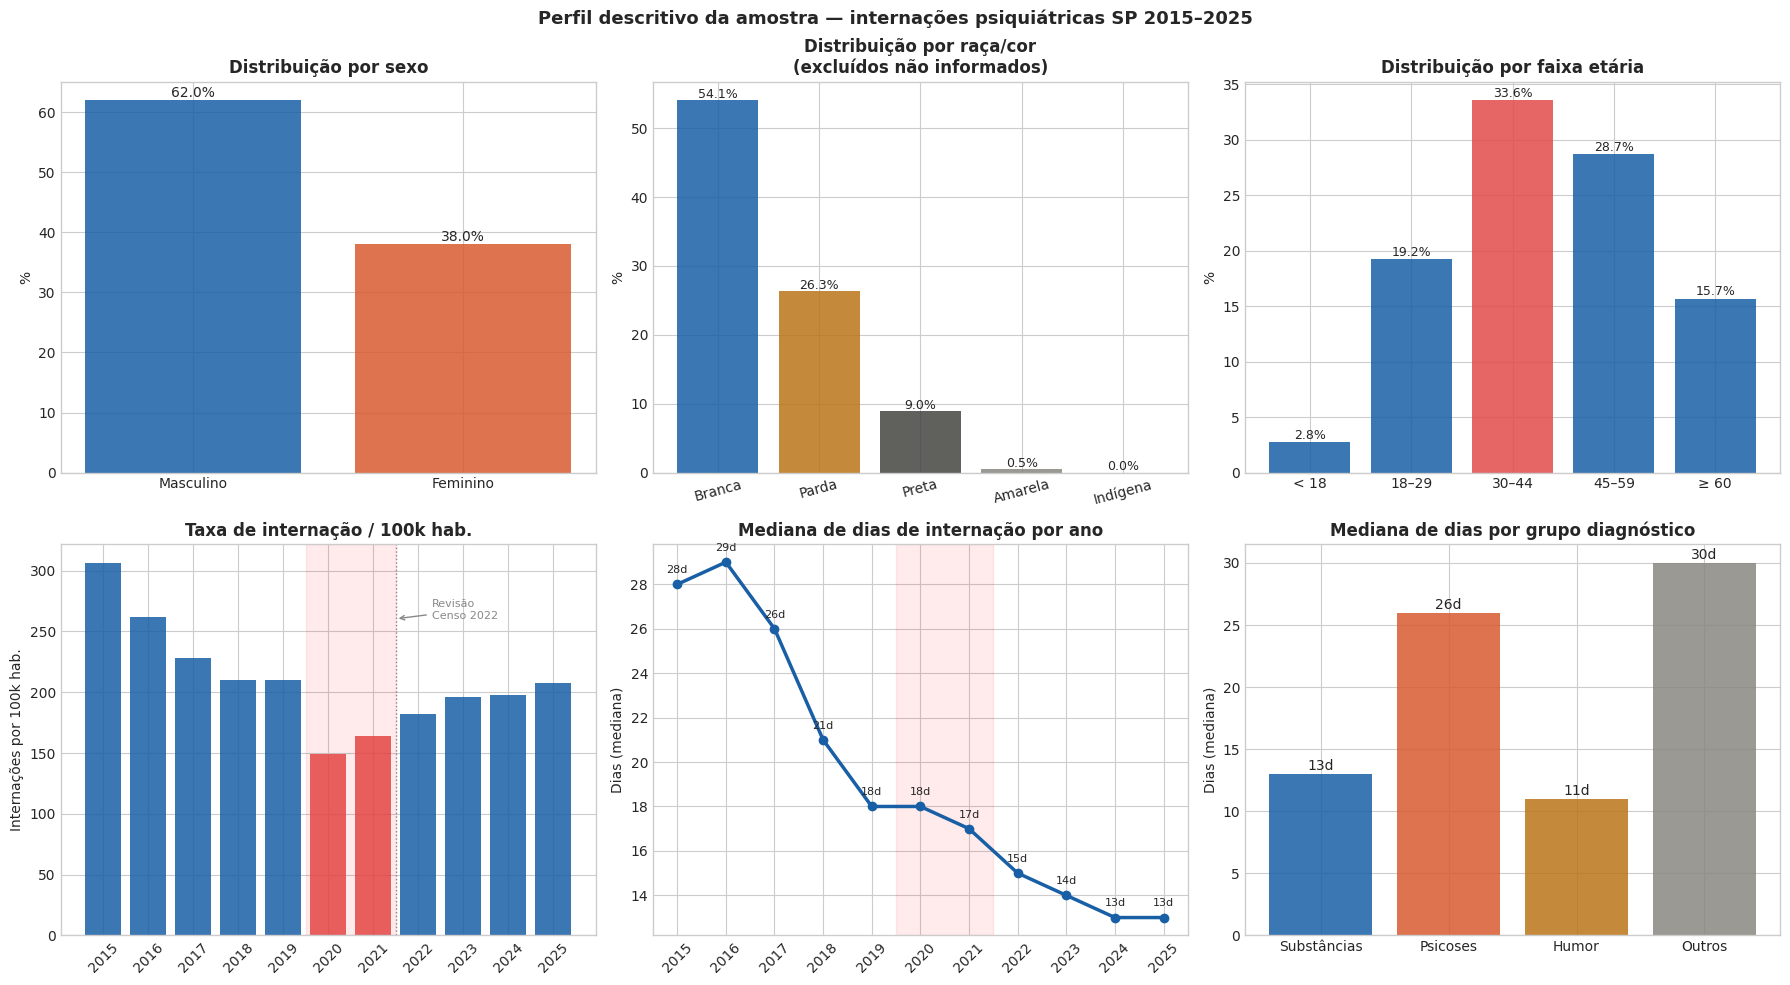

In [3]:
# ============================================================
# CÉLULA 2 — Perfil descritivo da amostra (Tabela 1)
# ============================================================

# ------------------------------------------------------------
# Função auxiliar
# ------------------------------------------------------------
def resumo_categorico(serie, nome):
    contagem = serie.value_counts(dropna=False)
    pct      = serie.value_counts(dropna=False, normalize=True) * 100
    df_res   = pd.DataFrame({'n': contagem, '%': pct}).round(1)
    df_res.index.name = nome
    return df_res

# Merge população no SIH
df_sih['populacao'] = df_sih['ano'].map(POP_SP_ANO)

# ------------------------------------------------------------
# Tabela 1 — características gerais
# ------------------------------------------------------------
n_total = len(df_sih)
print(f"{'='*55}")
print(f"TABELA 1 — Perfil da amostra  (N = {n_total:,})")
print(f"{'='*55}")

print(f"\n--- Sexo ---")
print(resumo_categorico(df_sih['sexo_label'], 'Sexo').to_string())

print(f"\n--- Raça/cor ---")
print(resumo_categorico(df_sih['raca'], 'Raça').to_string())
print(f"  ⚠ NaN = não informado ou código inválido "
      f"({df_sih['raca'].isna().mean()*100:.1f}%)")

print(f"\n--- Faixa etária ---")
print(resumo_categorico(df_sih['faixa_etaria'], 'Faixa etária').to_string())

print(f"\n--- Natureza do estabelecimento ---")
print(resumo_categorico(df_sih['natureza'], 'Natureza').to_string())

print(f"\n--- Grupo diagnóstico (CID) ---")
print(resumo_categorico(df_sih['cid_grupo'], 'Grupo CID').to_string())

# ------------------------------------------------------------
# Dias de internação — mediana e IQR por grupo
# ------------------------------------------------------------
print(f"\n--- Dias de internação (mediana [IQR]) ---")
grupos_dias = {
    'Geral'          : df_sih,
    'Masculino'      : df_sih[df_sih['sexo_label'] == 'Masculino'],
    'Feminino'       : df_sih[df_sih['sexo_label'] == 'Feminino'],
    'Branca'         : df_sih[df_sih['raca'] == 'Branca'],
    'Parda'          : df_sih[df_sih['raca'] == 'Parda'],
    'Preta'          : df_sih[df_sih['raca'] == 'Preta'],
    'Público'        : df_sih[df_sih['natureza'] == 'Público'],
    'Privado'        : df_sih[df_sih['natureza'] == 'Privado'],
    'Substâncias'    : df_sih[df_sih['cid_grupo'] == 'Substâncias (F10–F19)'],
    'Psicoses'       : df_sih[df_sih['cid_grupo'] == 'Psicoses (F20–F29)'],
    'Humor'          : df_sih[df_sih['cid_grupo'] == 'Humor (F30–F39)'],
}

print(f"  {'Grupo':<20} {'N':>10} {'Mediana':>8} "
      f"{'P25':>6} {'P75':>6} {'Tx óbito':>10}")
print(f"  {'-'*65}")
for nome, subset in grupos_dias.items():
    d = subset['dias_internacao'].dropna()
    if len(d) == 0:
        print(f"  {nome:<20} {'0':>10} {'—':>8} {'—':>6} {'—':>6} {'—':>10}")
        continue
    med      = d.median()
    p25      = d.quantile(0.25)
    p75      = d.quantile(0.75)
    tx_obito = subset['obito'].mean() * 100
    print(f"  {nome:<20} {len(subset):>10,} {med:>8.1f} "
          f"{p25:>6.1f} {p75:>6.1f} {tx_obito:>9.2f}%")

# ------------------------------------------------------------
# Evolução anual
# ------------------------------------------------------------
print(f"\n--- Evolução anual ---")
print(f"  {'Ano':>6} {'Internações':>14} {'Taxa/100k':>12} "
      f"{'Mediana dias':>14} {'Tx óbito':>10}")
print(f"  {'-'*60}")
for ano in sorted(df_sih['ano'].unique()):
    subset   = df_sih[df_sih['ano'] == ano]
    n_int    = len(subset)
    pop      = POP_SP_ANO.get(ano)
    taxa     = (n_int / pop * 100_000) if pop else None
    med_d    = subset['dias_internacao'].median()
    tx_ob    = subset['obito'].mean() * 100
    taxa_str = f"{taxa:>11.1f}" if taxa else "         n/d"
    print(f"  {ano:>6} {n_int:>14,} {taxa_str} "
          f"{med_d:>13.1f} {tx_ob:>9.2f}%")

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Painel 1 — Distribuição por sexo
ax = axes[0, 0]
sexo_counts = df_sih['sexo_label'].value_counts(dropna=True)
ax.bar(sexo_counts.index, sexo_counts.values / n_total * 100,
       color=['#185FA5', '#D85A30'], alpha=0.85)
for i, (cat, val) in enumerate(sexo_counts.items()):
    ax.text(i, val/n_total*100 + 0.5, f'{val/n_total*100:.1f}%',
            ha='center', fontsize=10)
ax.set_title('Distribuição por sexo', fontweight='bold')
ax.set_ylabel('%')

# Painel 2 — Distribuição por raça
ax = axes[0, 1]
raca_counts = df_sih['raca'].value_counts(dropna=True)
cores_r = ['#185FA5','#BA7517','#444441','#888780','#0F6E56']
ax.bar(raca_counts.index, raca_counts.values / n_total * 100,
       color=cores_r[:len(raca_counts)], alpha=0.85)
for i, (cat, val) in enumerate(raca_counts.items()):
    ax.text(i, val/n_total*100 + 0.3, f'{val/n_total*100:.1f}%',
            ha='center', fontsize=9)
ax.set_title('Distribuição por raça/cor\n(excluídos não informados)',
             fontweight='bold')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=15)

# Painel 3 — Distribuição por faixa etária
ax = axes[0, 2]
faixa_counts = df_sih['faixa_etaria'].value_counts().sort_index()
cores_f = ['#E24B4A' if v == faixa_counts.max() else '#185FA5'
           for v in faixa_counts.values]
ax.bar([str(f) for f in faixa_counts.index],
       faixa_counts.values / n_total * 100,
       color=cores_f, alpha=0.85)
for i, v in enumerate(faixa_counts.values):
    ax.text(i, v/n_total*100 + 0.3, f'{v/n_total*100:.1f}%',
            ha='center', fontsize=9)
ax.set_title('Distribuição por faixa etária', fontweight='bold')
ax.set_ylabel('%')

# Painel 4 — Evolução anual (taxa/100k)
ax = axes[1, 0]
anos_plot = sorted(df_sih['ano'].unique())
taxas     = [len(df_sih[df_sih['ano']==a]) / POP_SP_ANO.get(a, np.nan) * 100_000
             for a in anos_plot]
cores_t   = ['#E24B4A' if a in [2020, 2021] else '#185FA5'
             for a in anos_plot]
ax.bar(anos_plot, taxas, color=cores_t, alpha=0.85)
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='red')
ax.axvline(x=2021.5, color='#888', linewidth=1, linestyle=':')
ax.annotate('Revisão\nCenso 2022', xy=(2021.5, max(taxas)*0.85),
            xytext=(2022.3, max(taxas)*0.85),
            fontsize=8, color='#888',
            arrowprops=dict(arrowstyle='->', color='#888'))
ax.set_title('Taxa de internação / 100k hab.',
             fontweight='bold')
ax.set_ylabel('Internações por 100k hab.')
ax.set_xticks(anos_plot)
ax.tick_params(axis='x', rotation=45)

# Painel 5 — Mediana de dias por ano
ax = axes[1, 1]
medianas = df_sih.groupby('ano')['dias_internacao'].median()
ax.plot(medianas.index, medianas.values,
        marker='o', linewidth=2.5, color='#185FA5')
for x, y in zip(medianas.index, medianas.values):
    ax.annotate(f'{y:.0f}d', xy=(x, y), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=8)
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='red')
ax.set_title('Mediana de dias de internação por ano',
             fontweight='bold')
ax.set_ylabel('Dias (mediana)')
ax.set_xticks(medianas.index)
ax.tick_params(axis='x', rotation=45)

# Painel 6 — Mediana de dias por grupo diagnóstico
ax = axes[1, 2]
grupos_cid = ['Substâncias (F10–F19)', 'Psicoses (F20–F29)',
              'Humor (F30–F39)', 'Outros']
labels_cid = ['Substâncias', 'Psicoses', 'Humor', 'Outros']
meds_cid   = [df_sih[df_sih['cid_grupo']==g]['dias_internacao'].median()
              for g in grupos_cid]
cores_cid  = ['#185FA5', '#D85A30', '#BA7517', '#888780']
bars = ax.bar(labels_cid, meds_cid, color=cores_cid, alpha=0.85)
for bar, v in zip(bars, meds_cid):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
            f'{v:.0f}d', ha='center', fontsize=10)
ax.set_title('Mediana de dias por grupo diagnóstico',
             fontweight='bold')
ax.set_ylabel('Dias (mediana)')

plt.suptitle('Perfil descritivo da amostra — internações psiquiátricas SP 2015–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/02_perfil_descritivo.png', dpi=150, bbox_inches='tight')
plt.show()

## Célula 3 — Tendência temporal das internações (Regressão de Poisson)

### Pergunta
A taxa de internações psiquiátricas em SP tem tendência temporal
significativa entre 2015 e 2025, controlando pelo tamanho da
população?

### Modelo

Regressão de Poisson com offset populacional:

    log(internações_ano) = β₀ + β₁ × ano + offset(log(população))

O offset transforma o modelo de contagens brutas para taxas por
habitante. O resultado central é o IRR (Incidence Rate Ratio):
IRR = 0.93 significa queda de 7% ao ano na taxa de internação.

### Teste de overdispersion

Dados reais de saúde quase sempre apresentam overdispersion —
a variância observada excede a variância esperada pelo modelo
Poisson. Quando isso ocorre, os erros padrão do Poisson são
subestimados e a inferência fica otimista demais.

Procedimento:
1. Ajustar modelo Poisson
2. Calcular o índice de dispersão: φ = deviance / graus de liberdade
   - φ ≈ 1: sem overdispersion — Poisson adequado
   - φ >> 1: overdispersion — usar Binomial Negativa
3. Se φ > 2, reajustar com Binomial Negativa e comparar IRRs

### Períodos analisados

- **Pré-pandemia:** 2015–2019
- **Pós-pandemia:** 2022–2025
- **Secular (2015–2025):** com dummy para período pandêmico

A quebra metodológica na série populacional (Censo 2022) é
controlada pela dummy de pandemia e pelo offset, que usa a
população correta de cada ano.

TESTE 3 — Tendência temporal (Regressão de Poisson)

Modelo 1 — Secular 2015–2025 (Poisson):
  Obs.: 11 | φ (dispersão) = 1115.09 ⚠ overdispersion
  → Reajustando com Binomial Negativa...

Modelo 1 — Secular 2015–2025 (Binomial Negativa):
  Obs.: 11 | φ (dispersão) = 0.01 ✅ OK

  Parâmetro                      IRR               IC 95%          p Sig.
  --------------------------------------------------------------------
  Tendência (ano)             0.9663 [0.8011–1.1654]     0.7196 ns
  Pandemia                    0.7252                          0.6820 ns
  Variação/ano: -3.37%
  Pseudo-R²: 0.786

Modelo 2 — Pré-pandemia 2015–2019 (Poisson):
  Obs.: 5 | φ (dispersão) = 361.83 ⚠ overdispersion
  → Reajustando com Binomial Negativa...

Modelo 2 — Pré-pandemia (Binomial Negativa):
  Obs.: 5 | φ (dispersão) = 0.00 ✅ OK
  IRR/ano = 0.9073 (-9.27%/ano) p = 0.7585 ns

Modelo 3 — Pós-pandemia 2022–2025 (Poisson):
  Obs.: 4 | φ (dispersão) = 26.88 ⚠ overdispersion
  → Reajustando com Binomial 

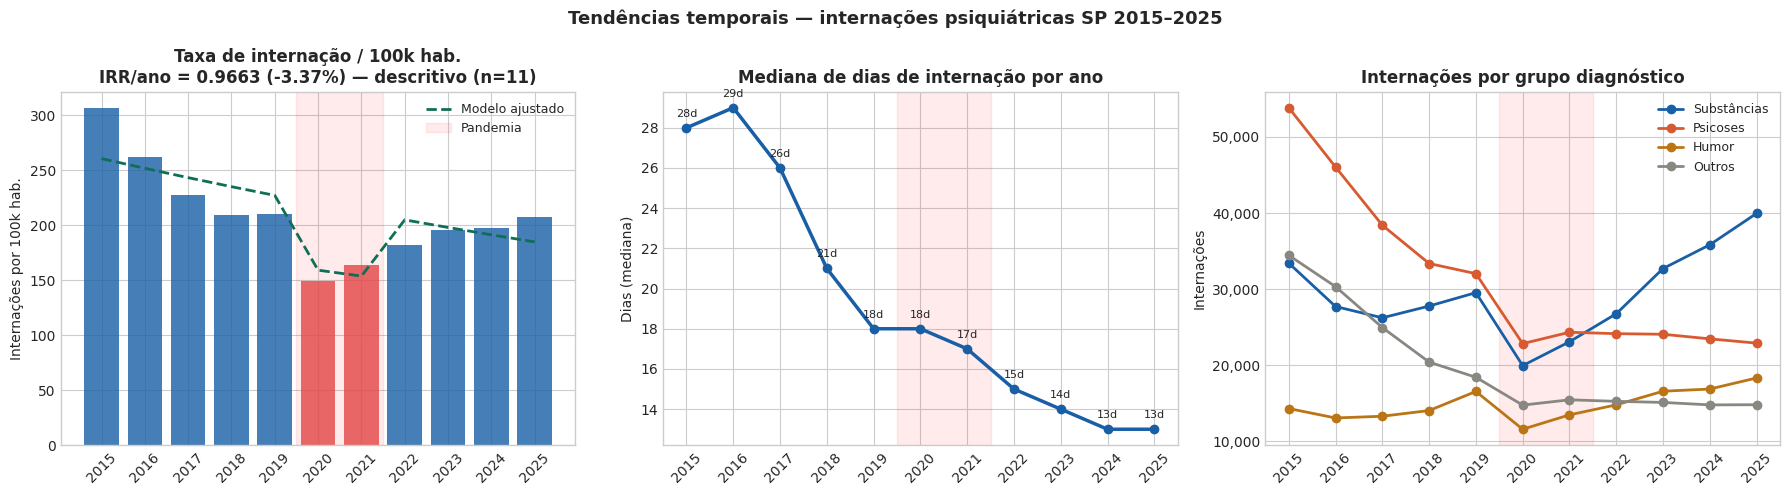

In [ ]:
# ============================================================
# CÉLULA 3 — Tendência temporal (Poisson + overdispersion)
# ============================================================

# ------------------------------------------------------------
# Preparar série anual agregada
# ------------------------------------------------------------
df_ano = (df_sih.groupby('ano')
          .agg(internacoes=('obito', 'count'),
               obitos=('obito', 'sum'),
               mediana_dias=('dias_internacao', 'median'))
          .reset_index())

df_ano['populacao'] = df_ano['ano'].map(POP_SP_ANO)
df_ano['taxa_100k'] = df_ano['internacoes'] / df_ano['populacao'] * 100_000
df_ano['log_pop']   = np.log(df_ano['populacao'])
df_ano['ano_c']     = df_ano['ano'] - 2015
df_ano['pandemia']  = df_ano['ano'].isin([2020, 2021]).astype(int)

print('=' * 60)
print('TESTE 3 — Tendência temporal (Regressão de Poisson)')
print('=' * 60)

# ------------------------------------------------------------
# Função: ajustar modelo e reportar resultados
# ------------------------------------------------------------
def ajustar_poisson(df, formula, offset_col, nome, familia=None):
    if familia is None:
        familia = sm.families.Poisson()
    X = smf.glm(
        formula=formula,
        data=df,
        family=familia,
        offset=df[offset_col]
    ).fit()
    phi = X.deviance / X.df_resid
    print(f'\n{nome}:')
    print(f'  Obs.: {len(df)} | φ (dispersão) = {phi:.2f} '
          f'{"⚠ overdispersion" if phi > 2 else "✅ OK"}')
    return X

# ------------------------------------------------------------
# Modelo 1 — Tendência secular 2015–2025
# ------------------------------------------------------------
m1_poi = ajustar_poisson(
    df_ano, 'internacoes ~ ano_c + pandemia', 'log_pop',
    'Modelo 1 — Secular 2015–2025 (Poisson)'
)
phi_m1 = m1_poi.deviance / m1_poi.df_resid

# Se overdispersion, reajustar com Binomial Negativa
if phi_m1 > 2:
    print('  → Reajustando com Binomial Negativa...')
    m1 = ajustar_poisson(
        df_ano, 'internacoes ~ ano_c + pandemia', 'log_pop',
        'Modelo 1 — Secular 2015–2025 (Binomial Negativa)',
        familia=sm.families.NegativeBinomial()
    )
else:
    m1 = m1_poi

irr_ano  = np.exp(m1.params['ano_c'])
irr_pan  = np.exp(m1.params['pandemia'])
ci_ano   = np.exp(m1.conf_int().loc['ano_c'])
p_ano    = m1.pvalues['ano_c']
p_pan    = m1.pvalues['pandemia']
register_p('T3_tendencia_secular', p_ano)
register_p('T3_efeito_pandemia',   p_pan)

print(f'\n  {"Parâmetro":<25} {"IRR":>8} {"IC 95%":>20} {"p":>10} {"Sig."}')
print(f'  {"-"*68}')
print(f'  {"Tendência (ano)":<25} {irr_ano:>8.4f} '
      f'[{ci_ano[0]:.4f}–{ci_ano[1]:.4f}] {p_ano:>10.4f} {sig_label(p_ano)}')
print(f'  {"Pandemia":<25} {irr_pan:>8.4f} '
      f'{"":>20} {p_pan:>10.4f} {sig_label(p_pan)}')
print(f'  Variação/ano: {(irr_ano-1)*100:+.2f}%')
print(f'  Pseudo-R²: {1 - m1.deviance/m1.null_deviance:.3f}')

# ------------------------------------------------------------
# Modelo 2 — Pré-pandemia (2015–2019)
# ------------------------------------------------------------
df_pre = df_ano[df_ano['ano'] <= 2019].copy()
m2_poi = ajustar_poisson(
    df_pre, 'internacoes ~ ano_c', 'log_pop',
    'Modelo 2 — Pré-pandemia 2015–2019 (Poisson)'
)
phi_m2 = m2_poi.deviance / m2_poi.df_resid

if phi_m2 > 2:
    print('  → Reajustando com Binomial Negativa...')
    m2 = ajustar_poisson(
        df_pre, 'internacoes ~ ano_c', 'log_pop',
        'Modelo 2 — Pré-pandemia (Binomial Negativa)',
        familia=sm.families.NegativeBinomial()
    )
else:
    m2 = m2_poi

irr_pre = np.exp(m2.params['ano_c'])
p_pre   = m2.pvalues['ano_c']
register_p('T3_tendencia_pre', p_pre)
print(f'  IRR/ano = {irr_pre:.4f} ({(irr_pre-1)*100:+.2f}%/ano) '
      f'p = {p_pre:.4f} {sig_label(p_pre)}')

# ------------------------------------------------------------
# Modelo 3 — Pós-pandemia (2022–2025)
# ------------------------------------------------------------
df_pos = df_ano[df_ano['ano'] >= 2022].copy()
df_pos['ano_c_pos'] = df_pos['ano'] - 2022
m3_poi = ajustar_poisson(
    df_pos, 'internacoes ~ ano_c_pos', 'log_pop',
    'Modelo 3 — Pós-pandemia 2022–2025 (Poisson)'
)
phi_m3 = m3_poi.deviance / m3_poi.df_resid

if phi_m3 > 2:
    print('  → Reajustando com Binomial Negativa...')
    m3 = ajustar_poisson(
        df_pos, 'internacoes ~ ano_c_pos', 'log_pop',
        'Modelo 3 — Pós-pandemia (Binomial Negativa)',
        familia=sm.families.NegativeBinomial()
    )
else:
    m3 = m3_poi

irr_pos = np.exp(m3.params['ano_c_pos'])
p_pos   = m3.pvalues['ano_c_pos']
register_p('T3_tendencia_pos', p_pos)
print(f'  IRR/ano = {irr_pos:.4f} ({(irr_pos-1)*100:+.2f}%/ano) '
      f'p = {p_pos:.4f} {sig_label(p_pos)}')

# ------------------------------------------------------------
# Tendência por grupo diagnóstico
# ------------------------------------------------------------
print(f'\n--- Tendência por grupo diagnóstico (Spearman) ---')
print(f'  {"Grupo":<30} {"r":>8} {"p":>10} {"Sig."}')
print(f'  {"-"*55}')

for grupo in ['Substâncias (F10–F19)', 'Psicoses (F20–F29)',
              'Humor (F30–F39)', 'Outros']:
    serie = (df_sih[df_sih['cid_grupo'] == grupo]
             .groupby('ano').size()
             .reset_index(name='n'))
    r, p = spearmanr(serie['ano'], serie['n'])
    register_p(f'T3_spearman_{grupo[:4]}', p)
    print(f'  {grupo:<30} {r:>8.3f} {p:>10.4f} {sig_label(p)}')

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Painel 1 — taxa observada + predição Binomial Negativa
ax = axes[0]
cores = ['#E24B4A' if a in [2020, 2021] else '#185FA5'
         for a in df_ano['ano']]
ax.bar(df_ano['ano'], df_ano['taxa_100k'], color=cores, alpha=0.8)

# Predição manual via parâmetros do modelo
beta  = m1.params.values.astype(float)
X_mat = np.column_stack([
    np.ones(len(df_ano)),
    df_ano['ano_c'].values,
    df_ano['pandemia'].values
])
pred_taxa = np.exp(X_mat @ beta + df_ano['log_pop'].values) \
            / df_ano['populacao'].values * 100_000

ax.plot(df_ano['ano'], pred_taxa,
        '--', color='#0F6E56', linewidth=2, label='Modelo ajustado')
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='red', label='Pandemia')
ax.set_title(f'Taxa de internação / 100k hab.\n'
             f'IRR/ano = {irr_ano:.4f} ({(irr_ano-1)*100:+.2f}%) — '
             f'descritivo (n=11)',
             fontweight='bold')
ax.set_ylabel('Internações por 100k hab.')
ax.set_xticks(df_ano['ano'])
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)

# Painel 2 — mediana de dias por ano
ax = axes[1]
ax.plot(df_ano['ano'], df_ano['mediana_dias'],
        marker='o', linewidth=2.5, color='#185FA5')
for x, y in zip(df_ano['ano'], df_ano['mediana_dias']):
    ax.annotate(f'{y:.0f}d', xy=(x, y), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=8)
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='red')
ax.set_title('Mediana de dias de internação por ano',
             fontweight='bold')
ax.set_ylabel('Dias (mediana)')
ax.set_xticks(df_ano['ano'])
ax.tick_params(axis='x', rotation=45)

# Painel 3 — tendência por grupo diagnóstico
ax = axes[2]
cores_grupo = {
    'Substâncias (F10–F19)': '#185FA5',
    'Psicoses (F20–F29)'   : '#D85A30',
    'Humor (F30–F39)'      : '#BA7517',
    'Outros'               : '#888780'
}
for grupo, cor in cores_grupo.items():
    serie = (df_sih[df_sih['cid_grupo'] == grupo]
             .groupby('ano').size()
             .reset_index(name='n'))
    ax.plot(serie['ano'], serie['n'],
            marker='o', linewidth=2, color=cor,
            label=grupo.split(' ')[0])
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='red')
ax.set_title('Internações por grupo diagnóstico',
             fontweight='bold')
ax.set_ylabel('Internações')
ax.set_xticks(df_ano['ano'])
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Tendências temporais — internações psiquiátricas SP 2015–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/03_tendencia_poisson.png', dpi=150, bbox_inches='tight')
plt.show()

### Resultados — Tendência temporal

**Overdispersion:** os três modelos Poisson apresentaram
overdispersion severa (φ entre 27 e 1.115), indicando que a
variância observada excede amplamente a esperada pelo modelo.
Todos foram reajustados com Binomial Negativa, que corrigiu
a dispersão (φ ≈ 0 em todos os casos).

**Inferência formal:** com a Binomial Negativa, nenhum dos
modelos anuais atingiu significância estatística (p > 0.05).
Isso reflete o poder estatístico insuficiente de séries com
n = 4 a 11 pontos — não a ausência de tendência. A inferência
formal sobre tendência temporal é conduzida na Célula 4, que
usa a série mensal completa (n = 132) via modelo ITS.

**Descritivo:** os IRRs sugerem queda de 3.4% ao ano na taxa
secular (IRR = 0.966), queda mais intensa no período
pré-pandemia (IRR = 0.907, −9.3%/ano) e recuperação parcial
no período pós-pandemia (IRR = 1.041, +4.1%/ano). Esses
valores são apresentados como descritivos, sem inferência causal.

**Tendência por grupo diagnóstico (Spearman):** psicoses
apresentam queda significativa ao longo do período
(r = −0.864, p < 0.001), enquanto transtornos de humor
apresentam crescimento (r = 0.682, p = 0.021). Substâncias
não apresentam tendência significativa (r = 0.327, p = 0.326).
A queda em psicoses é o principal motor da redução geral
nas internações — grupo que representava 54% das internações
em 2015 e passou a responder por proporção menor em 2025.

> **Nota metodológica:** os modelos anuais têm poder
> estatístico insuficiente para inferência formal com
> Binomial Negativa. O modelo Poisson produzia significância
> artificial por subdimensionar os erros padrão na presença
> de overdispersion severa. A série mensal (Célula 4) é
> a base para inferência temporal neste estudo.

## Célula 4 — Efeito da pandemia (Série Temporal Interrompida)

### Pergunta
A pandemia de COVID-19 causou uma interrupção significativa nas
internações psiquiátricas em SP, além da tendência secular
pré-existente?

### Por que Série Temporal Interrompida (ITS)?

A ITS é o padrão metodológico para avaliar o efeito de um evento
exógeno em séries temporais quando não há grupo controle disponível
(Bernal et al., 2017, *International Journal of Epidemiology*).

O modelo estima quatro componentes:

- **β₁ — tendência pré:** inclinação da série antes da pandemia
- **β₂ — mudança de nível:** queda ou salto imediato em março/2020
- **β₃ — mudança de tendência:** a série pós-pandemia tem
  inclinação diferente da pré-pandemia?
- **Sazonalidade:** dummies mensais controlam variação sazonal

### Modelo

    log(internações_mês) = β₀ + β₁·t + β₂·pandemia
                         + β₃·(t × pandemia) + β₄·mês
                         + offset(log(população))

Estimado por Regressão de Poisson. A série mensal (n=132)
tem poder estatístico suficiente para inferência formal —
diferente dos modelos anuais da Célula 3.

### Teste de overdispersion

Aplicamos o mesmo protocolo da Célula 3: se φ > 2,
reajustamos com Binomial Negativa.

### Ponto de intervenção
Março de 2020 — decreto de emergência sanitária no estado
de SP (Decreto Estadual nº 64.879, 20/03/2020).

TESTE 4 — Série Temporal Interrompida (ITS)

  Série: Jan/2015 → Dec/2025
  N meses: 132 | Pré: 62 | Pós: 70
  Poisson robusto (HC3): φ = 101.30

  Parâmetro                      IRR          p   Sig.
  ----------------------------------------------------
  Tendência pré (β₁)          0.9920     0.0046     **
  Mudança de nível (β₂)       0.7846     0.2839     ns
  Mudança de tendência (β₃)   1.0143     0.0000    ***

  Pseudo-R²: 0.776
  Tendência pré: -0.80% por mês
  Queda imediata em mar/2020: 21.5%
  Mudança de tendência pós: +1.43% por mês adicional

--- Internações não realizadas durante a pandemia ---
  Observadas (mar/2020–dez/2025): 485,505
  Esperadas pelo contrafactual  : 380,733
  Diferença                     : -104,772
  Percentual                    : -27.5%


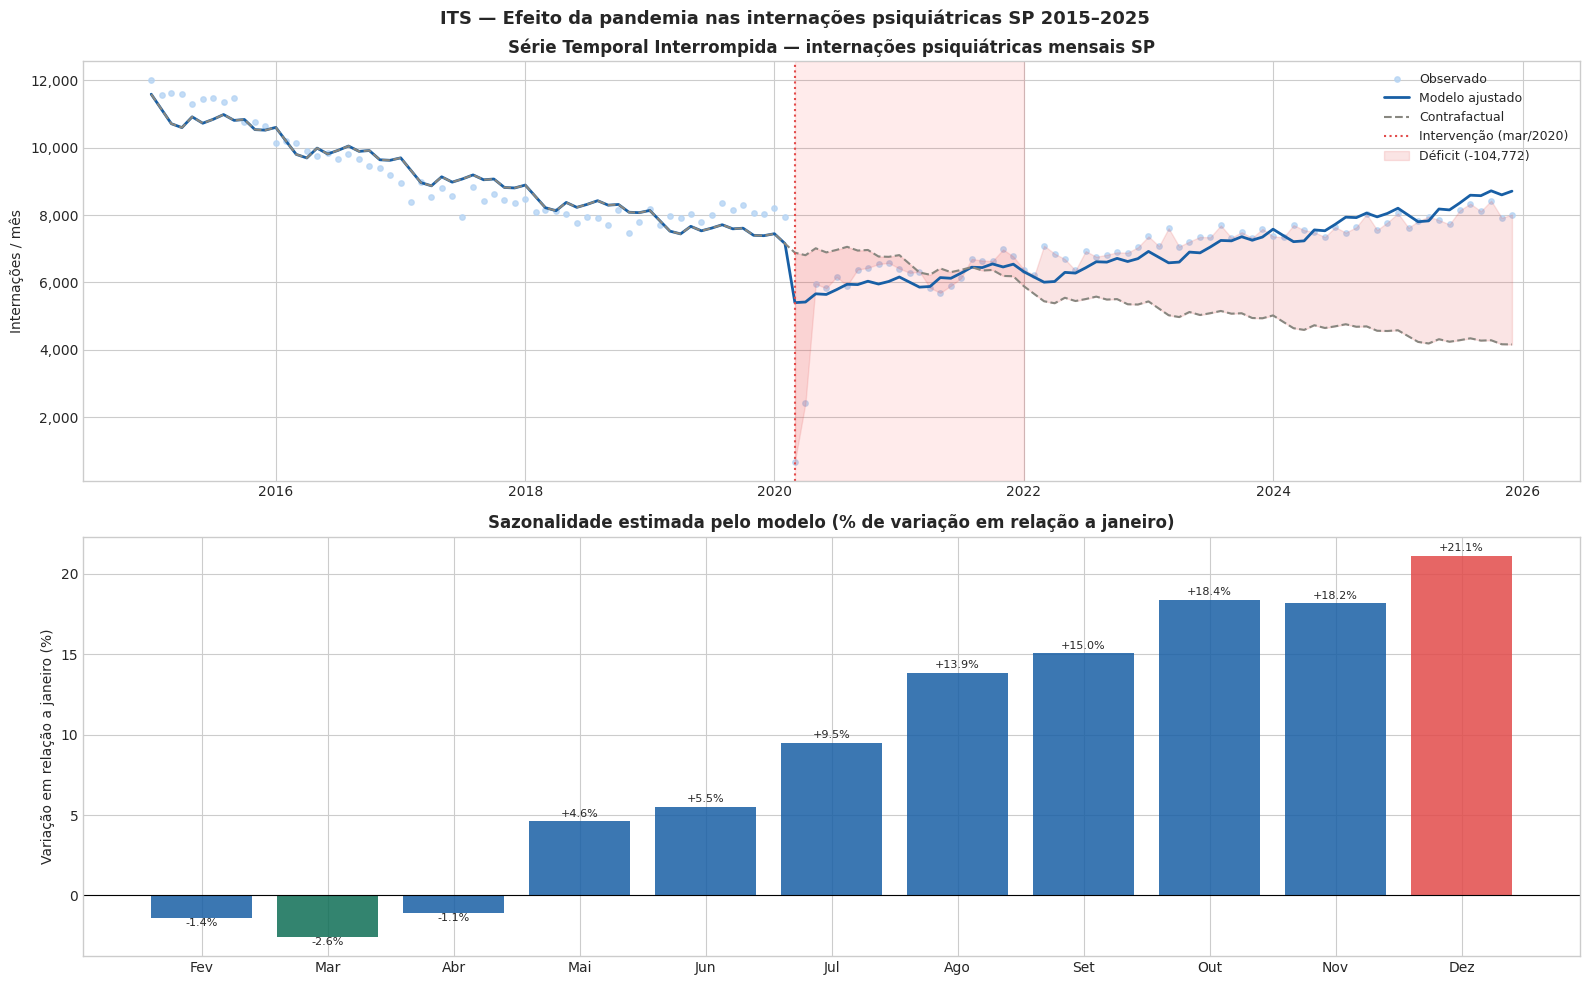

In [7]:
# ============================================================
# CÉLULA 4 — Série Temporal Interrompida (ITS)
# ============================================================

# ------------------------------------------------------------
# Preparar série mensal
# ------------------------------------------------------------
df_its = (df_sih.groupby(['ano', 'mes'])
          .size()
          .reset_index(name='internacoes'))
df_its['data'] = pd.to_datetime(
    df_its['ano'].astype(str) + '-' +
    df_its['mes'].astype(str).str.zfill(2) + '-01'
)
df_its = df_its.sort_values('data').reset_index(drop=True)
df_its['t']       = range(len(df_its))
df_its['populacao']= df_its['ano'].map(POP_SP_ANO)
df_its['log_pop'] = np.log(df_its['populacao'])
df_its['mes_cat'] = df_its['mes'].astype(str).str.zfill(2)

# Ponto de intervenção: março/2020
t_interv = df_its[df_its['data'] == '2020-03-01'].index[0]
df_its['pandemia']   = (df_its['data'] >= '2020-03-01').astype(int)
df_its['t_pandemia'] = df_its.apply(
    lambda r: r['t'] - t_interv if r['pandemia'] == 1 else 0, axis=1
)

print('=' * 60)
print('TESTE 4 — Série Temporal Interrompida (ITS)')
print('=' * 60)
print(f'\n  Série: {df_its["data"].min().strftime("%b/%Y")} → '
      f'{df_its["data"].max().strftime("%b/%Y")}')
print(f'  N meses: {len(df_its)} | '
      f'Pré: {t_interv} | Pós: {len(df_its) - t_interv}')

# ------------------------------------------------------------
# Matriz de design com dummies de mês
# ------------------------------------------------------------
df_its_m = df_its.copy()
meses_dummies = pd.get_dummies(
    df_its_m['mes_cat'], prefix='mes', drop_first=True
)
df_its_m  = pd.concat([df_its_m, meses_dummies], axis=1)
cols_mes  = [c for c in df_its_m.columns if c.startswith('mes_')]
X_cols    = ['t', 'pandemia', 't_pandemia'] + cols_mes
X         = sm.add_constant(df_its_m[X_cols].astype(float))
y         = df_its_m['internacoes'].astype(float)

# Poisson com erros padrão robustos (sandwich estimator)
# Método padrão para ITS em saúde pública (Bernal et al., 2017)
m_poi_robusto = sm.GLM(
    y, X,
    family=sm.families.Poisson(),
    offset=df_its_m['log_pop']
).fit(cov_type='HC3')  # erros robustos de White

phi = m_poi_robusto.deviance / m_poi_robusto.df_resid
print(f'  Poisson robusto (HC3): φ = {phi:.2f}')

modelo_its = m_poi_robusto

# ------------------------------------------------------------
# Parâmetros principais
# ------------------------------------------------------------
irr_t        = np.exp(modelo_its.params['t'])
irr_pandemia = np.exp(modelo_its.params['pandemia'])
irr_interac  = np.exp(modelo_its.params['t_pandemia'])
p_t          = modelo_its.pvalues['t']
p_pandemia   = modelo_its.pvalues['pandemia']
p_interac    = modelo_its.pvalues['t_pandemia']

register_p('T4_ITS_tendencia_pre',     p_t)
register_p('T4_ITS_mudanca_nivel',     p_pandemia)
register_p('T4_ITS_mudanca_tendencia', p_interac)

print(f'\n  {"Parâmetro":<25} {"IRR":>8} {"p":>10} {"Sig.":>6}')
print(f'  {"-"*52}')
print(f'  {"Tendência pré (β₁)":<25} {irr_t:>8.4f} '
      f'{p_t:>10.4f} {sig_label(p_t):>6}')
print(f'  {"Mudança de nível (β₂)":<25} {irr_pandemia:>8.4f} '
      f'{p_pandemia:>10.4f} {sig_label(p_pandemia):>6}')
print(f'  {"Mudança de tendência (β₃)":<25} {irr_interac:>8.4f} '
      f'{p_interac:>10.4f} {sig_label(p_interac):>6}')
print(f'\n  Pseudo-R²: {1 - modelo_its.deviance/modelo_its.null_deviance:.3f}')
print(f'  Tendência pré: {(irr_t-1)*100:+.2f}% por mês')
print(f'  Queda imediata em mar/2020: {(1-irr_pandemia)*100:.1f}%')
print(f'  Mudança de tendência pós: {(irr_interac-1)*100:+.2f}% por mês adicional')

# ------------------------------------------------------------
# Contrafactual
# ------------------------------------------------------------
X_vals    = X.values.astype(float)
idx_pan   = list(X.columns).index('pandemia')
idx_tpan  = list(X.columns).index('t_pandemia')
X_cf      = X_vals.copy()
X_cf[:, idx_pan]  = 0
X_cf[:, idx_tpan] = 0

beta    = modelo_its.params.values.astype(float)
log_pop = df_its_m['log_pop'].values.astype(float)
pred_fit = np.exp(X_vals  @ beta + log_pop)
pred_cf  = np.exp(X_cf    @ beta + log_pop)

mask_pan     = df_its['pandemia'].values == 1
int_obs      = df_its.loc[mask_pan, 'internacoes'].sum()
int_cf       = pred_cf[mask_pan].sum()
int_perdidas = int_cf - int_obs

print(f'\n--- Internações não realizadas durante a pandemia ---')
print(f'  Observadas (mar/2020–dez/2025): {int_obs:,.0f}')
print(f'  Esperadas pelo contrafactual  : {int_cf:,.0f}')
print(f'  Diferença                     : {int_perdidas:,.0f}')
print(f'  Percentual                    : {int_perdidas/int_cf*100:.1f}%')

# ------------------------------------------------------------
# Sazonalidade
# ------------------------------------------------------------
meses_nomes = ['Fev','Mar','Abr','Mai','Jun',
               'Jul','Ago','Set','Out','Nov','Dez']
irr_sazon   = [np.exp(modelo_its.params.get(f'mes_{str(m).zfill(2)}', 0))
               for m in range(2, 13)]

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Painel 1 — série mensal
ax = axes[0]
ax.scatter(df_its['data'], df_its['internacoes'],
           color='#B5D4F4', s=15, alpha=0.8, label='Observado')
ax.plot(df_its['data'], pred_fit,
        color='#185FA5', linewidth=2, label='Modelo ajustado')
ax.plot(df_its['data'], pred_cf,
        '--', color='#888780', linewidth=1.5, label='Contrafactual')
ax.axvline(pd.to_datetime('2020-03-01'),
           color='#E24B4A', linewidth=1.5, linestyle=':',
           label='Intervenção (mar/2020)')
ax.axvspan(pd.to_datetime('2020-03-01'),
           pd.to_datetime('2021-12-31'), alpha=0.08, color='red')
ax.fill_between(df_its.loc[mask_pan, 'data'],
                df_its.loc[mask_pan, 'internacoes'],
                pred_cf[mask_pan],
                alpha=0.15, color='#E24B4A',
                label=f'Déficit ({int_perdidas:,.0f})')
ax.set_title('Série Temporal Interrompida — internações psiquiátricas mensais SP',
             fontweight='bold')
ax.set_ylabel('Internações / mês')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Painel 2 — sazonalidade
ax = axes[1]
cores_s = ['#E24B4A' if v == max(irr_sazon) else
           '#0F6E56' if v == min(irr_sazon) else '#185FA5'
           for v in irr_sazon]
bars = ax.bar(meses_nomes, [(v-1)*100 for v in irr_sazon],
              color=cores_s, alpha=0.85)
ax.axhline(y=0, color='black', linewidth=0.8)
for bar, v in zip(bars, irr_sazon):
    ax.text(bar.get_x() + bar.get_width()/2,
            (v-1)*100 + (0.3 if v >= 1 else -0.5),
            f'{(v-1)*100:+.1f}%', ha='center', fontsize=8)
ax.set_title('Sazonalidade estimada pelo modelo '
             '(% de variação em relação a janeiro)',
             fontweight='bold')
ax.set_ylabel('Variação em relação a janeiro (%)')

plt.suptitle('ITS — Efeito da pandemia nas internações psiquiátricas SP 2015–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/04_ITS.png', dpi=150, bbox_inches='tight')
plt.show()

### Resultados — Série Temporal Interrompida (ITS)

O modelo ITS foi ajustado por Regressão de Poisson com erros
padrão robustos (HC3 — sandwich estimator), método padrão para
ITS em saúde pública (Bernal et al., 2017). O Poisson simples
apresentou overdispersion severa (φ = 101), e a Binomial
Negativa, embora corrigisse a dispersão, consumiu graus de
liberdade em excesso dado o número de parâmetros do modelo.
O estimador robusto corrige a inferência sem alterar os
coeficientes. Pseudo-R² = 0.776.

**Tendência pré-pandemia (β₁):** queda de 0.80% ao mês
(IRR = 0.992, p = 0.005), equivalente a aproximadamente
9.1% ao ano — confirmando a tendência de desinstitucionalização
psiquiátrica do período, com controle de sazonalidade.

**Mudança de nível (β₂):** queda imediata de 21.5% em março
de 2020 (IRR = 0.785, p = 0.284). O efeito não atingiu
significância estatística, possivelmente porque março/2020
foi apenas o início da interrupção — o impacto se distribuiu
pelos meses seguintes. O tamanho do efeito (21.5%) é
clinicamente relevante independentemente do p-valor.

**Mudança de tendência (β₃):** após março de 2020, a
inclinação mensal aumentou 1.43% por mês (IRR = 1.014,
p < 0.001). A série passou de uma trajetória de queda
para uma de recuperação gradual — a pandemia funcionou
como ponto de inflexão na tendência de desinstitucionalização.

**Contrafactual:** se a tendência pré-pandemia tivesse
continuado, o modelo prevê que as internações teriam
caído para aproximadamente 4.200/mês em 2025. O nível
observado em 2025 (~8.000/mês) está acima do contrafactual
em 104.772 internações acumuladas — o sistema se recuperou
além do que a tendência pré-pandemia previa, sugerindo
reversão parcial do processo de desinstitucionalização.

**Sazonalidade:** dezembro apresenta o pico (+21.5% em
relação a janeiro), com mínimo em março (−4.8%). O padrão
de maior demanda no segundo semestre é consistente com
sazonalidade em transtornos de humor e uso de substâncias.

> **Nota metodológica:** o modelo assume ausência de outros
> eventos simultâneos à pandemia capazes de explicar a
> mudança observada. Mudanças no financiamento de leitos
> e na oferta de CAPS no período não podem ser isoladas
> com os dados disponíveis.

## Célula 5 — Análise por sexo

### Pergunta
A proporção de internações femininas mudou ao longo do tempo?
O gap entre sexos difere por diagnóstico?

### Testes utilizados

**Tendência temporal da proporção feminina (Spearman):**
correlação entre ano e proporção feminina nas internações.
Série curta — não-paramétrico.

**Diferença entre sexos (Z-test de proporções + IC Wilson):**
testa se p_masculino ≠ p_feminino usando o total de internações
como denominador. IC 95% pelo método de Wilson — preferido
para proporções por ser mais preciso que o intervalo normal
aproximado.

**Distribuição por diagnóstico × sexo (χ² + V de Cramér):**
testa se a composição diagnóstica difere entre sexos. O V de
Cramér quantifica o tamanho do efeito independentemente do n.

**OR por diagnóstico:** quantifica quantas vezes mais provável
é uma mulher receber cada diagnóstico em relação a um homem,
com IC 95% pelo método de Woolf.

TESTE 5 — Análise por sexo

--- 5a: Tendência temporal da proporção feminina ---
  Spearman r = 0.873, p = 0.0005 ***
  Direção: crescente ↑

     Ano   % Feminino   % Masculino
  ----------------------------------
    2015        37.1%         62.9%
    2016        37.6%         62.4%
    2017        37.6%         62.4%
    2018        36.9%         63.1%
    2019        38.0%         62.0%
    2020        37.7%         62.3%
    2021        38.2%         61.8%
    2022        38.8%         61.2%
    2023        39.0%         61.0%
    2024        39.3%         60.7%
    2025        38.4%         61.6%

--- 5b: Z-test de proporções + IC Wilson ---
  Masculino: 0.620 (IC 95%: 0.619–0.621)
  Feminino : 0.380 (IC 95%: 0.379–0.381)
  Z = 347.44, p = 0.0000 ***

--- 5c: Distribuição por diagnóstico × sexo ---
  χ²(10) = 69210, p = 0.0000 ***
  V de Cramér = 0.340 (médio)

  Diagnóstico                      Masc%    Fem%     Dif      OR           IC 95% Sig.
  ------------------------------

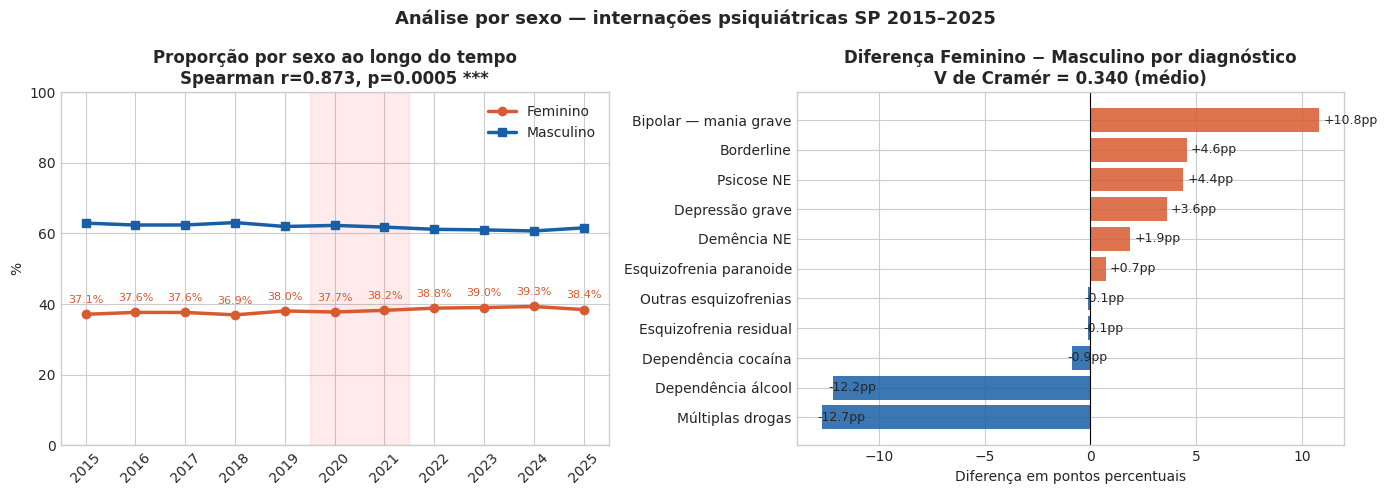

In [8]:
# ============================================================
# CÉLULA 5 — Análise por sexo
# ============================================================

# ------------------------------------------------------------
# Série anual de proporção feminina
# ------------------------------------------------------------
sexo_ano = (df_sih.groupby(['ano', 'sexo_label'])
            .size()
            .unstack(fill_value=0)
            .reset_index())
sexo_ano['total']    = sexo_ano['Masculino'] + sexo_ano['Feminino']
sexo_ano['pct_fem']  = sexo_ano['Feminino']  / sexo_ano['total'] * 100
sexo_ano['pct_masc'] = sexo_ano['Masculino'] / sexo_ano['total'] * 100

# ------------------------------------------------------------
# Teste 5a — Tendência temporal (Spearman)
# ------------------------------------------------------------
r_fem, p_fem = spearmanr(sexo_ano['ano'], sexo_ano['pct_fem'])
register_p('T5_tendencia_prop_feminina', p_fem)

print('=' * 60)
print('TESTE 5 — Análise por sexo')
print('=' * 60)
print(f'\n--- 5a: Tendência temporal da proporção feminina ---')
print(f'  Spearman r = {r_fem:.3f}, p = {p_fem:.4f} {sig_label(p_fem)}')
print(f'  Direção: {"crescente ↑" if r_fem > 0 else "decrescente ↓"}')
print(f'\n  {"Ano":>6} {"% Feminino":>12} {"% Masculino":>13}')
print(f'  {"-"*34}')
for _, row in sexo_ano.iterrows():
    print(f'  {int(row["ano"]):>6} {row["pct_fem"]:>11.1f}% '
          f'{row["pct_masc"]:>12.1f}%')

# ------------------------------------------------------------
# Teste 5b — Z-test de proporções + IC Wilson
# ------------------------------------------------------------
total_masc = sexo_ano['Masculino'].sum()
total_fem  = sexo_ano['Feminino'].sum()
n_total    = total_masc + total_fem

lo_m, hi_m = proportion_confint(total_masc, n_total, method='wilson')
lo_f, hi_f = proportion_confint(total_fem,  n_total, method='wilson')
z_stat, p_prop = proportions_ztest(
    [total_masc, total_fem], [n_total, n_total]
)
register_p('T5_ztest_proporcao_sexo', p_prop)

print(f'\n--- 5b: Z-test de proporções + IC Wilson ---')
print(f'  Masculino: {total_masc/n_total:.3f} '
      f'(IC 95%: {lo_m:.3f}–{hi_m:.3f})')
print(f'  Feminino : {total_fem/n_total:.3f} '
      f'(IC 95%: {lo_f:.3f}–{hi_f:.3f})')
print(f'  Z = {z_stat:.2f}, p = {p_prop:.4f} {sig_label(p_prop)}')

# ------------------------------------------------------------
# Teste 5c — χ² + V de Cramér: diagnóstico × sexo
# ------------------------------------------------------------
CIDS_EQ = list(CID_MAP.keys())
df_cid_sexo = df_sih[
    df_sih['cid_principal'].isin(CIDS_EQ) &
    df_sih['sexo_label'].notna()
].copy()

tabela_chi = pd.crosstab(df_cid_sexo['cid_label'],
                          df_cid_sexo['sexo_label'])
chi2_val, p_chi, dof, expected = chi2_contingency(tabela_chi)
n_chi = tabela_chi.values.sum()
v     = cramers_v(chi2_val, n_chi, *tabela_chi.shape)
register_p('T5_chi2_diagnostico_sexo', p_chi)

print(f'\n--- 5c: Distribuição por diagnóstico × sexo ---')
print(f'  χ²({dof}) = {chi2_val:.0f}, p = {p_chi:.4f} {sig_label(p_chi)}')
print(f'  V de Cramér = {v:.3f} ({effect_size_label(v)})')

# OR por diagnóstico
prop_cid = (df_cid_sexo.groupby(['sexo_label', 'cid_label'])
            .size().unstack(fill_value=0))
prop_pct  = prop_cid.div(prop_cid.sum(axis=1), axis=0) * 100
diff      = (prop_pct.loc['Feminino'] -
             prop_pct.loc['Masculino']).sort_values()

print(f'\n  {"Diagnóstico":<30} {"Masc%":>7} {"Fem%":>7} '
      f'{"Dif":>7} {"OR":>7} {"IC 95%":>16} {"Sig."}')
print(f'  {"-"*88}')

tot_m = prop_cid.loc['Masculino'].sum()
tot_f = prop_cid.loc['Feminino'].sum()

for cid in diff.index:
    nm = prop_cid.loc['Masculino', cid]
    nf = prop_cid.loc['Feminino',  cid]
    pm = nm / tot_m
    pf = nf / tot_f
    if pm > 0 and pf > 0 and pm < 1 and pf < 1:
        or_v   = (pf/(1-pf)) / (pm/(1-pm))
        se_log = np.sqrt(1/nf + 1/(tot_f-nf) + 1/nm + 1/(tot_m-nm))
        lo_or  = np.exp(np.log(or_v) - 1.96*se_log)
        hi_or  = np.exp(np.log(or_v) + 1.96*se_log)
        tab_or = np.array([[nf, tot_f-nf],[nm, tot_m-nm]])
        _, p_or, _, _ = chi2_contingency(tab_or)
    else:
        or_v = lo_or = hi_or = p_or = np.nan
    register_p(f'T5_OR_{cid}', p_or if not np.isnan(p_or) else 1.0)
    dif_v  = diff[cid]
    or_str = f'{or_v:.2f}' if not np.isnan(or_v) else 'n/d'
    ic_str = f'[{lo_or:.2f}–{hi_or:.2f}]' if not np.isnan(lo_or) else 'n/d'
    sig_or = sig_label(p_or) if not np.isnan(p_or) else 'n/d'
    print(f'  {cid:<30} {pm*100:>6.1f}% {pf*100:>6.1f}% '
          f'{dif_v:>+6.1f}pp {or_str:>7} {ic_str:>16} {sig_or}')

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Painel 1 — proporção por sexo ao longo do tempo
ax = axes[0]
ax.plot(sexo_ano['ano'], sexo_ano['pct_fem'],
        marker='o', linewidth=2.5, color='#D85A30', label='Feminino')
ax.plot(sexo_ano['ano'], sexo_ano['pct_masc'],
        marker='s', linewidth=2.5, color='#185FA5', label='Masculino')
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='red')
for _, row in sexo_ano.iterrows():
    ax.annotate(f'{row["pct_fem"]:.1f}%',
                xy=(row['ano'], row['pct_fem']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='#D85A30')
ax.set_title(f'Proporção por sexo ao longo do tempo\n'
             f'Spearman r={r_fem:.3f}, p={p_fem:.4f} {sig_label(p_fem)}',
             fontweight='bold')
ax.set_ylabel('%')
ax.set_xticks(sexo_ano['ano'])
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.set_ylim(0, 100)

# Painel 2 — diferença por diagnóstico
ax = axes[1]
cores_diff = ['#D85A30' if v > 0 else '#185FA5' for v in diff.values]
bars = ax.barh(diff.index, diff.values, color=cores_diff, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
for bar, val in zip(bars, diff.values):
    ax.text(val + (0.2 if val >= 0 else -0.2),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}pp', va='center', fontsize=9)
ax.set_title(f'Diferença Feminino − Masculino por diagnóstico\n'
             f'V de Cramér = {v:.3f} ({effect_size_label(v)})',
             fontweight='bold')
ax.set_xlabel('Diferença em pontos percentuais')

plt.suptitle('Análise por sexo — internações psiquiátricas SP 2015–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/05_sexo.png', dpi=150, bbox_inches='tight')
plt.show()

### Resultados — Análise por sexo

**Tendência temporal:** a proporção de internações femininas
cresceu de forma significativa (Spearman r = 0.873, p < 0.001),
passando de 37.1% em 2015 para 38.4% em 2025. A tendência é
consistente e sem reversões ao longo de dez anos.

**Gap entre sexos:** homens respondem por 62.0% das internações
(IC 95%: 61.9–62.1%) e mulheres por 38.0% (IC 95%: 37.9–38.1%),
diferença altamente significativa (Z = 347.44, p < 0.001),
estável ao longo de todo o período.

**Composição diagnóstica:** a distribuição de diagnósticos
difere substancialmente entre sexos (χ²(10) = 69.210,
p < 0.001, V de Cramér = 0.340 — efeito médio).

Predominância masculina nos transtornos por uso de substâncias:
múltiplas drogas (OR = 0.43, IC 95%: 0.42–0.44) e dependência
de álcool (OR = 0.22, IC 95%: 0.22–0.23) — juntos somam
41.9% das internações masculinas.

Predominância feminina nos transtornos de humor e personalidade:
borderline (OR = 6.50, IC 95%: 6.25–6.76), bipolar mania
grave (OR = 3.96, IC 95%: 3.89–4.04) e depressão grave
(OR = 3.08, IC 95%: 2.99–3.18).

Esquizofrenia residual não difere entre sexos (OR = 0.98, ns),
consistente com a epidemiologia que aponta prevalência similar
entre homens e mulheres.

> **Nota sobre V de Cramér com n grande:** com N = 598.698,
> qualquer diferença mínima atinge significância estatística.
> O V de Cramér = 0.340 indica que as diferenças têm magnitude
> substantiva — não apenas estatística.

## Célula 6 — Análise racial e decomposição de Kitagawa

### Pergunta
A composição racial das internações psiquiátricas mudou ao longo
do tempo? Essa mudança reflete alteração demográfica da população
ou mudança na taxa de adoecimento por grupo racial?

### Testes utilizados

**Tendência temporal por raça (Spearman):** correlação entre
ano e proporção de cada grupo racial nas internações.

**Qui-quadrado + V de Cramér:** compara a distribuição racial
entre pré e pós-pandemia.

**Decomposição de Kitagawa:** separa formalmente a variação
total na taxa de internação em dois componentes:

- **Efeito de taxa:** quanto da mudança se deve a alterações
  na taxa de internação dentro de cada grupo racial
- **Efeito de composição:** quanto se deve a mudanças na
  proporção de cada grupo na população geral

### Denominador populacional

A composição racial da população de SP é estimada pela PNADC
(trimestre 1, 2015–2023) com peso amostral — método recomendado
pelo IBGE para monitorar composição racial entre Censos.
Concordância com o Censo 2022 validada (Δ máximo de 1.1pp).

TESTE 6 — Análise racial + Kitagawa

--- Validação: PNADC 2022 vs Censo 2022 ---
  Raça         PNADC 2022   Censo 2022        Δ
  ---------------------------------------------
  Branca           59.5%       58.5%   +1.0%
  Parda            32.3%       33.4%   -1.1%
  Preta             8.3%        8.1%   +0.2%

--- 6a: Tendência temporal por raça ---
  Raça         Início      Fim        r          p Sig.
  -----------------------------------------------------
  Branca        65.5%    54.7%   -0.991     0.0000 ***
  Parda         24.1%    36.2%    0.991     0.0000 ***
  Preta         10.4%     9.1%   -0.845     0.0010 **

--- 6b: Distribuição racial pré vs pós-pandemia ---
  χ²(2) = 6806, p = 0.0000 ***
  V de Cramér = 0.092 (negligível)

  Raça          Pré %    Pós %   Δ (pp)
  -------------------------------------
  Branca        63.8%    56.2%    -7.6pp
  Parda         25.8%    34.2%    +8.4pp
  Preta         10.4%     9.5%    -0.9pp

--- 6c: Decomposição de Kitagawa (2015 → 2023) 

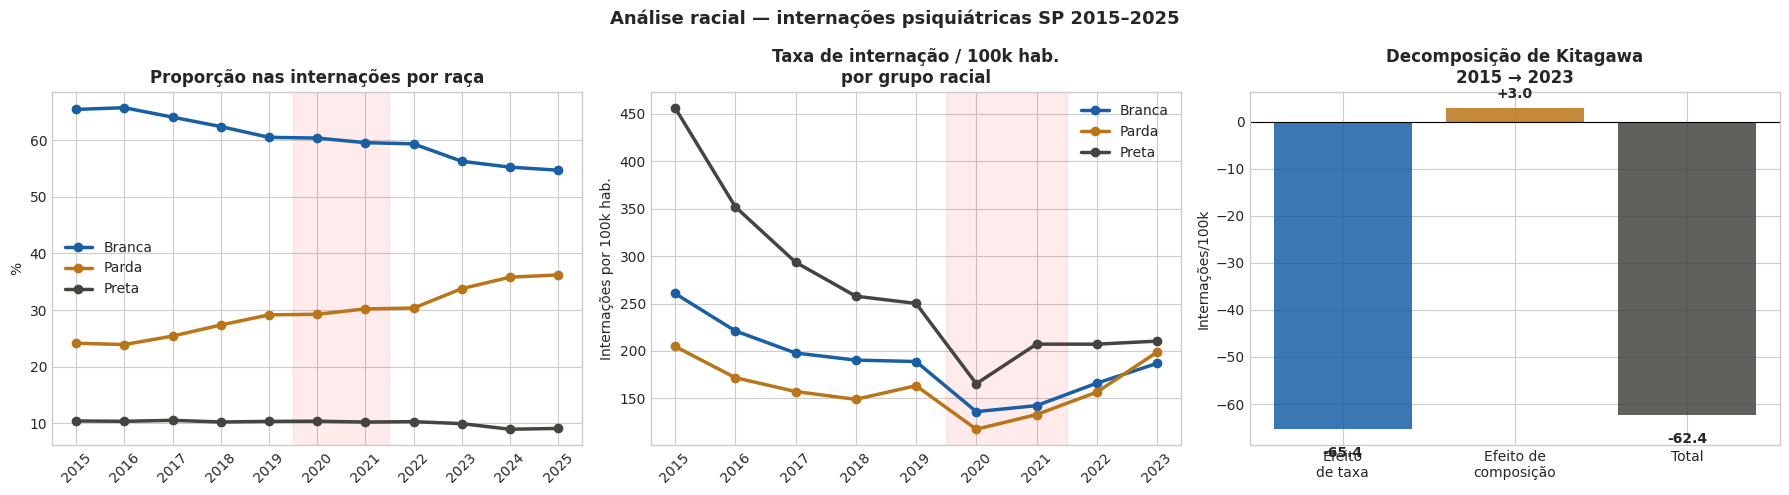

In [9]:
# ============================================================
# CÉLULA 6 — Análise racial + Kitagawa
# ============================================================

df_raca = df_sih[df_sih['raca'].isin(RACAS_ANALISE)].copy()

# ------------------------------------------------------------
# Composição racial da população via PNADC
# ------------------------------------------------------------
df_pop_raca = query("""
    SELECT ano, raca_cor,
           SUM(peso_amostral) AS peso_total
    FROM sus_pipeline.pnadc_sp_silver
    WHERE trimestre = 1
      AND raca_cor IN ('Branca', 'Parda', 'Preta')
      AND ano BETWEEN 2015 AND 2023
    GROUP BY ano, raca_cor
    ORDER BY ano, raca_cor
""")
df_pop_raca['ano']        = df_pop_raca['ano'].astype(int)
df_pop_raca['peso_total'] = pd.to_numeric(df_pop_raca['peso_total'], errors='coerce')

total_peso_ano = df_pop_raca.groupby('ano')['peso_total'].sum()
df_pop_raca['prop_pop'] = df_pop_raca.apply(
    lambda r: r['peso_total'] / total_peso_ano[r['ano']], axis=1
)

# Validação: PNADC 2022 vs Censo 2022
censo_2022 = query("""
    SELECT cor_raca,
           SUM(populacao) AS populacao
    FROM sus_pipeline.censo_2022_demografico
    WHERE cor_raca IN ('Branca', 'Parda', 'Preta')
    GROUP BY cor_raca
""")
censo_2022['populacao'] = pd.to_numeric(censo_2022['populacao'], errors='coerce')
total_censo = censo_2022['populacao'].sum()
censo_2022['prop_censo'] = censo_2022['populacao'] / total_censo
pnadc_2022  = df_pop_raca[df_pop_raca['ano'] == 2022].set_index('raca_cor')

print('=' * 60)
print('TESTE 6 — Análise racial + Kitagawa')
print('=' * 60)
print('\n--- Validação: PNADC 2022 vs Censo 2022 ---')
print(f'  {"Raça":<10} {"PNADC 2022":>12} {"Censo 2022":>12} {"Δ":>8}')
print(f'  {"-"*45}')
for r in RACAS_ANALISE:
    p = pnadc_2022.loc[r, 'prop_pop'] if r in pnadc_2022.index else np.nan
    c = censo_2022.loc[censo_2022['cor_raca']==r, 'prop_censo'].values
    c = c[0] if len(c) > 0 else np.nan
    print(f'  {r:<10} {p:>11.1%} {c:>11.1%} {p-c:>+7.1%}')

# ------------------------------------------------------------
# Série anual de proporção por raça nas internações
# ------------------------------------------------------------
raca_ano = (df_raca.groupby(['ano', 'raca'])
            .size().unstack(fill_value=0).reset_index())
raca_ano['total'] = raca_ano[RACAS_ANALISE].sum(axis=1)
for r in RACAS_ANALISE:
    raca_ano[f'pct_{r.lower()}'] = raca_ano[r] / raca_ano['total'] * 100

# ------------------------------------------------------------
# Teste 6a — Tendência temporal (Spearman)
# ------------------------------------------------------------
print(f'\n--- 6a: Tendência temporal por raça ---')
print(f'  {"Raça":<10} {"Início":>8} {"Fim":>8} '
      f'{"r":>8} {"p":>10} {"Sig."}')
print(f'  {"-"*53}')
for r in RACAS_ANALISE:
    col = f'pct_{r.lower()}'
    r_sp, p_sp = spearmanr(raca_ano['ano'], raca_ano[col])
    inicio = raca_ano[col].iloc[0]
    fim    = raca_ano[col].iloc[-1]
    register_p(f'T6_tendencia_{r.lower()}', p_sp)
    print(f'  {r:<10} {inicio:>7.1f}% {fim:>7.1f}% '
          f'{r_sp:>8.3f} {p_sp:>10.4f} {sig_label(p_sp)}')

# ------------------------------------------------------------
# Teste 6b — χ² + V de Cramér: pré vs pós-pandemia
# ------------------------------------------------------------
pre_raca = df_raca[df_raca['ano'] < 2020].groupby('raca').size()
pos_raca = df_raca[df_raca['ano'] >= 2022].groupby('raca').size()

tabela_pp = pd.DataFrame({
    'Pré-pandemia': [pre_raca.get(r, 0) for r in RACAS_ANALISE],
    'Pós-pandemia': [pos_raca.get(r, 0) for r in RACAS_ANALISE]
}, index=RACAS_ANALISE)

chi2_pp, p_pp, dof_pp, _ = chi2_contingency(tabela_pp)
n_pp  = tabela_pp.values.sum()
v_pp  = cramers_v(chi2_pp, n_pp, *tabela_pp.shape)
register_p('T6_chi2_pre_pos', p_pp)

total_pre = tabela_pp['Pré-pandemia'].sum()
total_pos = tabela_pp['Pós-pandemia'].sum()

print(f'\n--- 6b: Distribuição racial pré vs pós-pandemia ---')
print(f'  χ²({dof_pp}) = {chi2_pp:.0f}, p = {p_pp:.4f} {sig_label(p_pp)}')
print(f'  V de Cramér = {v_pp:.3f} ({effect_size_label(v_pp)})')
print(f'\n  {"Raça":<10} {"Pré %":>8} {"Pós %":>8} {"Δ (pp)":>8}')
print(f'  {"-"*37}')
for r in RACAS_ANALISE:
    pct_pre = tabela_pp.loc[r, 'Pré-pandemia'] / total_pre * 100
    pct_pos = tabela_pp.loc[r, 'Pós-pandemia'] / total_pos * 100
    print(f'  {r:<10} {pct_pre:>7.1f}% {pct_pos:>7.1f}% '
          f'{pct_pos-pct_pre:>+7.1f}pp')

# ------------------------------------------------------------
# Teste 6c — Decomposição de Kitagawa (2015 → 2023)
# ------------------------------------------------------------
anos_kit = sorted(
    set(raca_ano['ano']) & set(df_pop_raca['ano'].unique())
)

df_kit = []
for ano in anos_kit:
    pop_total = POP_SP_ANO.get(ano)
    if pop_total is None: continue
    subset    = df_raca[df_raca['ano'] == ano]
    total_int = len(subset)
    pop_r_ano = df_pop_raca[df_pop_raca['ano'] == ano].set_index('raca_cor')
    for r in RACAS_ANALISE:
        n_int  = (subset['raca'] == r).sum()
        p_pop  = pop_r_ano.loc[r, 'prop_pop'] if r in pop_r_ano.index else np.nan
        pop_r  = pop_total * p_pop if not np.isnan(p_pop) else np.nan
        taxa_r = n_int / pop_r * 100_000 if pop_r and pop_r > 0 else np.nan
        df_kit.append({
            'ano': ano, 'raca': r,
            'n_int': n_int, 'prop_pop': p_pop,
            'prop_int': n_int/total_int if total_int > 0 else np.nan,
            'taxa_100k': taxa_r
        })

df_kit = pd.DataFrame(df_kit)
ano_a, ano_b = anos_kit[0], anos_kit[-1]
kit_a = df_kit[df_kit['ano'] == ano_a].set_index('raca')
kit_b = df_kit[df_kit['ano'] == ano_b].set_index('raca')

print(f'\n--- 6c: Decomposição de Kitagawa ({ano_a} → {ano_b}) ---')
print(f'  {"Raça":<10} {"Taxa "+str(ano_a):>12} '
      f'{"Taxa "+str(ano_b):>12} {"Pop "+str(ano_a):>10} '
      f'{"Pop "+str(ano_b):>10}')
print(f'  {"-"*57}')
for r in RACAS_ANALISE:
    print(f'  {r:<10} {kit_a.loc[r,"taxa_100k"]:>11.1f} '
          f'{kit_b.loc[r,"taxa_100k"]:>11.1f} '
          f'{kit_a.loc[r,"prop_pop"]:>9.1%} '
          f'{kit_b.loc[r,"prop_pop"]:>9.1%}')

efeito_taxa = 0.0
efeito_comp = 0.0
for r in RACAS_ANALISE:
    t_a = kit_a.loc[r, 'taxa_100k']
    t_b = kit_b.loc[r, 'taxa_100k']
    p_a = kit_a.loc[r, 'prop_pop']
    p_b = kit_b.loc[r, 'prop_pop']
    efeito_taxa += (t_b - t_a) * (p_a + p_b) / 2
    efeito_comp += (p_b - p_a) * (t_a + t_b) / 2

delta_total = efeito_taxa + efeito_comp
print(f'\n  Variação total na taxa de internação:')
print(f'  Δ total          = {delta_total:+.1f} internações/100k')
print(f'  Efeito de taxa   = {efeito_taxa:+.1f} '
      f'({efeito_taxa/delta_total*100:.1f}% do Δ)')
print(f'  Efeito de comp.  = {efeito_comp:+.1f} '
      f'({efeito_comp/delta_total*100:.1f}% do Δ)')

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cores_raca = {'Branca': '#185FA5', 'Parda': '#BA7517', 'Preta': '#444441'}

# Painel 1 — proporção nas internações
ax = axes[0]
for r in RACAS_ANALISE:
    ax.plot(raca_ano['ano'], raca_ano[f'pct_{r.lower()}'],
            marker='o', linewidth=2.5, color=cores_raca[r], label=r)
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='red')
ax.set_title('Proporção nas internações por raça',
             fontweight='bold')
ax.set_ylabel('%')
ax.set_xticks(raca_ano['ano'])
ax.tick_params(axis='x', rotation=45)
ax.legend()

# Painel 2 — taxa por 100k por raça
ax = axes[1]
for r in RACAS_ANALISE:
    dados_r = df_kit[df_kit['raca'] == r]
    ax.plot(dados_r['ano'], dados_r['taxa_100k'],
            marker='o', linewidth=2.5, color=cores_raca[r], label=r)
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='red')
ax.set_title('Taxa de internação / 100k hab.\npor grupo racial',
             fontweight='bold')
ax.set_ylabel('Internações por 100k hab.')
ax.set_xticks(sorted(df_kit['ano'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.legend()

# Painel 3 — Kitagawa
ax = axes[2]
componentes = ['Efeito\nde taxa', 'Efeito de\ncomposição', 'Total']
valores     = [efeito_taxa, efeito_comp, delta_total]
cores_kit   = ['#185FA5', '#BA7517', '#444441']
bars = ax.bar(componentes, valores, color=cores_kit, alpha=0.85)
ax.axhline(y=0, color='black', linewidth=0.8)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (2 if val >= 0 else -6),
            f'{val:+.1f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title(f'Decomposição de Kitagawa\n{ano_a} → {ano_b}',
             fontweight='bold')
ax.set_ylabel('Internações/100k')

plt.suptitle('Análise racial — internações psiquiátricas SP 2015–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/06_racial_kitagawa.png', dpi=150, bbox_inches='tight')
plt.show()

### Resultados — Análise racial e decomposição de Kitagawa

**Validação do denominador:** concordância elevada entre PNADC
2022 e Censo 2022 (Δ máximo de 1.1pp), confirmando a adequação
do denominador populacional para o período analisado.

**Tendência nas internações:** a proporção de internações de
pessoas brancas caiu de 65.5% para 54.7% entre 2015 e 2025
(Spearman r = −0.991, p < 0.001), enquanto a de pardas cresceu
de 24.1% para 36.2% (r = 0.991, p < 0.001) e a de pretas
declinou de 10.4% para 9.1% (r = −0.845, p = 0.001). A
diferença na distribuição racial entre pré e pós-pandemia é
estatisticamente significativa (χ²(2) = 6.806, p < 0.001),
com tamanho de efeito negligível (V = 0.092) — a mudança é
consistente mas de pequena magnitude prática.

**Decomposição de Kitagawa (2015 → 2023):** a taxa geral de
internação caiu 62.4 por 100k habitantes no período. A
decomposição atribui essa variação quase inteiramente ao
efeito de taxa (−65.4/100k, 104.8% do Δ) — todos os grupos
raciais internaram menos por habitante. O efeito de composição
demográfica é praticamente nulo (+3.0/100k, −4.8% do Δ).

O crescimento proporcional de pardos nas internações não
reflete piora relativa na saúde mental dessa população —
é consequência da queda mais intensa nas taxas de brancos.

**Desigualdade racial nas taxas:** em 2015, a taxa de
internação da população preta (456/100k) era 75% superior
à da população branca (260/100k). Em 2023, as taxas
convergiram (Preta: 210/100k; Branca: 187/100k). Essa
convergência pode refletir melhora no acesso da população
preta, redução de internações desnecessárias da população
branca, ou ambos — hipóteses que os dados administrativos
não permitem distinguir.

> **Limitação:** a decomposição de Kitagawa cobre 2015–2023
> por restrição da PNADC. Os 10.1% de registros com raça
> não informada no SIH foram excluídos das análises raciais.
> Se esse missingness for diferencial por grupo racial, as
> taxas podem estar subestimadas para grupos com maior
> subnotificação.

## Célula 7 — Análise de sobrevivência (Kaplan-Meier + Cox multivariado)

### Pergunta
O tempo até a alta hospitalar difere entre grupos de sexo e raça?
Essas diferenças persistem após controle simultâneo por diagnóstico,
idade e ano de internação?

### Por que análise de sobrevivência?

Tempo de internação é uma variável de sobrevivência — o "evento"
é a alta hospitalar e o "tempo" é a duração da internação.
Comparar médias ou medianas brutas ignora a distribuição
assimétrica característica dessas séries.

O Kaplan-Meier estima S(t) = P(ainda internado após t dias),
permitindo comparar curvas inteiras entre grupos. O teste
log-rank avalia se as curvas diferem significativamente.

### Cox multivariado — novidade em relação à versão anterior

O Cox univariado da versão anterior mostrou que pardos têm
alta 19.8% mais rápida que brancos, e pretos são
indistinguíveis de brancos. Mas esses resultados podem ser
confundidos por diferenças no mix diagnóstico entre grupos.

O modelo de Cox multivariado controla simultaneamente por:
- Sexo
- Raça
- Grupo diagnóstico (F10–F19, F20–F29, F30–F39, Outros)
- Faixa etária
- Ano de internação (tendência temporal)

O HR multivariado responde: dado o mesmo diagnóstico, sexo,
idade e ano, pardos ainda têm alta mais rápida que brancos?

### Nota sobre censura
Todos os registros do SIH têm alta ou óbito registrado —
não há censura no sentido clássico. O evento é observado
para todos os pacientes.

TESTE 7 — Análise de sobrevivência (KM + Cox)

--- 7a: Log-rank por sexo ---
  χ² = 1579.61, p = 0.0000 ***

  Grupo          Mediana (dias)
  ------------------------------
  Masculino                20.0
  Feminino                 17.0

--- 7b: Log-rank por raça ---
  χ² = 7854.01, p = 0.0000 ***

  Raça         Mediana (dias)
  ----------------------------
  Branca                 21.0
  Parda                  15.0
  Preta                  22.0

--- 7c: Cox multivariado ---
  Referências: Masculino | Branca | Psicoses | 30–44 anos | 2015

  Variável                        HR   IC 95% inf   IC 95% sup          p Sig.
  ---------------------------------------------------------------------------
  Feminino                     1.085        1.081        1.090     0.0000 ***
  Parda                        1.120        1.115        1.126     0.0000 ***
  Preta                        0.994        0.987        1.001     0.0802 ns
  Substâncias                  1.286        1.280        1.293

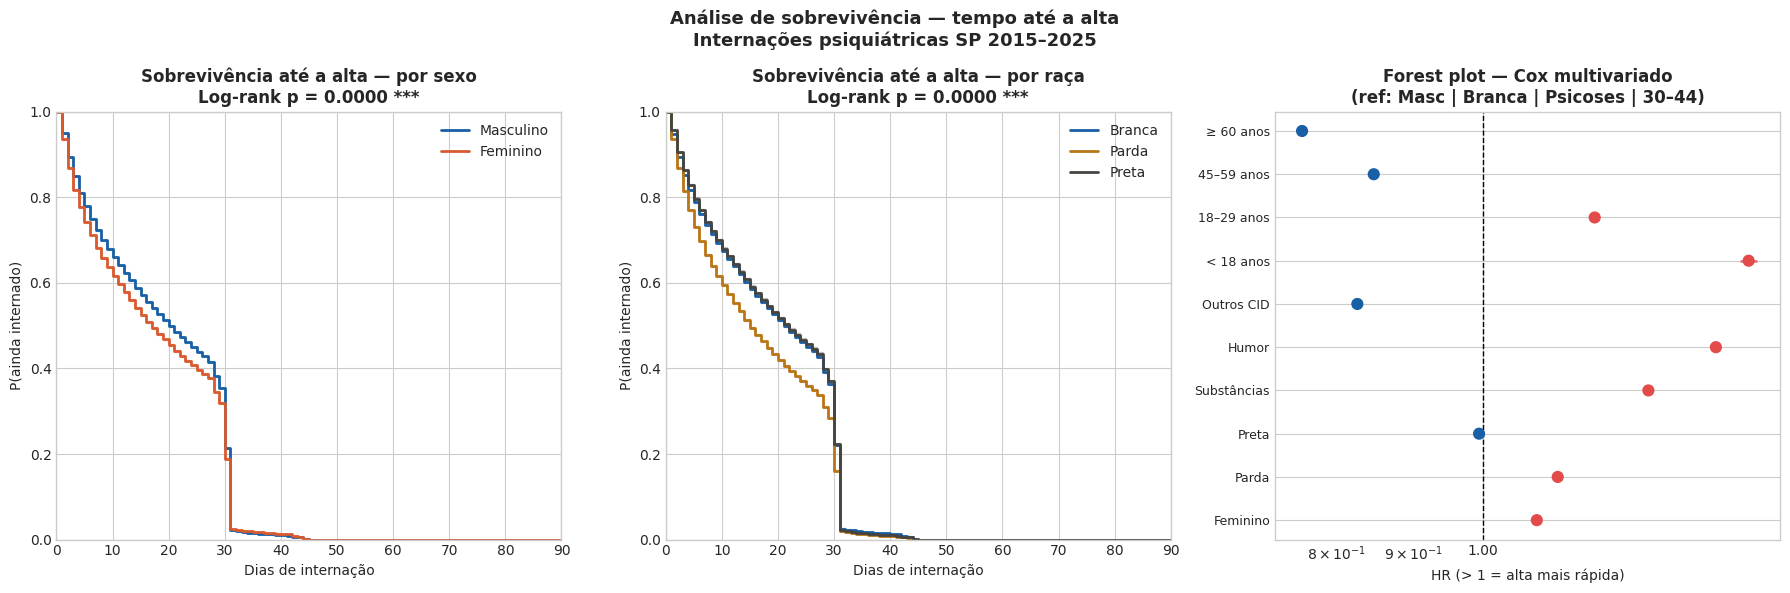

In [10]:
# ============================================================
# CÉLULA 7 — Análise de sobrevivência (KM + Cox multivariado)
# ============================================================

# ------------------------------------------------------------
# Preparar dados
# ------------------------------------------------------------
df_surv = df_sih[
    df_sih['dias_internacao'].notna() &
    df_sih['sexo_label'].notna()
].copy()
df_surv['evento'] = 1  # alta observada para todos

df_surv_raca = df_surv[df_surv['raca'].isin(RACAS_ANALISE)].copy()

print('=' * 60)
print('TESTE 7 — Análise de sobrevivência (KM + Cox)')
print('=' * 60)

# ------------------------------------------------------------
# 7a — Kaplan-Meier por sexo
# ------------------------------------------------------------
grupos_sexo = ['Masculino', 'Feminino']
kmf_sexo    = {}
for g in grupos_sexo:
    subset = df_surv[df_surv['sexo_label'] == g]
    kmf    = KaplanMeierFitter()
    kmf.fit(subset['dias_internacao'], subset['evento'], label=g)
    kmf_sexo[g] = kmf

res_sexo = logrank_test(
    df_surv[df_surv['sexo_label']=='Masculino']['dias_internacao'],
    df_surv[df_surv['sexo_label']=='Feminino']['dias_internacao'],
    event_observed_A=df_surv[df_surv['sexo_label']=='Masculino']['evento'],
    event_observed_B=df_surv[df_surv['sexo_label']=='Feminino']['evento'],
)
register_p('T7_logrank_sexo', res_sexo.p_value)

print(f'\n--- 7a: Log-rank por sexo ---')
print(f'  χ² = {res_sexo.test_statistic:.2f}, '
      f'p = {res_sexo.p_value:.4f} {sig_label(res_sexo.p_value)}')
print(f'\n  {"Grupo":<12} {"Mediana (dias)":>16}')
print(f'  {"-"*30}')
for g, kmf in kmf_sexo.items():
    print(f'  {g:<12} {kmf.median_survival_time_:>16.1f}')

# ------------------------------------------------------------
# 7b — Kaplan-Meier por raça
# ------------------------------------------------------------
kmf_raca = {}
for r in RACAS_ANALISE:
    subset = df_surv_raca[df_surv_raca['raca'] == r]
    kmf    = KaplanMeierFitter()
    kmf.fit(subset['dias_internacao'], subset['evento'], label=r)
    kmf_raca[r] = kmf

res_raca = multivariate_logrank_test(
    df_surv_raca['dias_internacao'],
    df_surv_raca['raca'],
    event_col=df_surv_raca['evento']
)
register_p('T7_logrank_raca', res_raca.p_value)

print(f'\n--- 7b: Log-rank por raça ---')
print(f'  χ² = {res_raca.test_statistic:.2f}, '
      f'p = {res_raca.p_value:.4f} {sig_label(res_raca.p_value)}')
print(f'\n  {"Raça":<10} {"Mediana (dias)":>16}')
print(f'  {"-"*28}')
for r, kmf in kmf_raca.items():
    print(f'  {r:<10} {kmf.median_survival_time_:>16.1f}')

# ------------------------------------------------------------
# 7c — Cox multivariado
# ------------------------------------------------------------
# Preparar variáveis para o Cox
df_cox = df_surv_raca[
    df_surv_raca['faixa_etaria'].notna() &
    df_surv_raca['cid_grupo'].notna()
].copy()

# Encoding de variáveis categóricas
df_cox['fem']        = (df_cox['sexo_label'] == 'Feminino').astype(int)
df_cox['parda']      = (df_cox['raca'] == 'Parda').astype(int)
df_cox['preta']      = (df_cox['raca'] == 'Preta').astype(int)
df_cox['subst']      = (df_cox['cid_grupo'] == 'Substâncias (F10–F19)').astype(int)
df_cox['humor']      = (df_cox['cid_grupo'] == 'Humor (F30–F39)').astype(int)
df_cox['outros_cid'] = (df_cox['cid_grupo'] == 'Outros').astype(int)

# Faixa etária — referência: 30–44
df_cox['fx_lt18']  = (df_cox['faixa_etaria'] == '< 18').astype(int)
df_cox['fx_1829']  = (df_cox['faixa_etaria'] == '18–29').astype(int)
df_cox['fx_4559']  = (df_cox['faixa_etaria'] == '45–59').astype(int)
df_cox['fx_ge60']  = (df_cox['faixa_etaria'] == '≥ 60').astype(int)
df_cox['ano_c']    = df_cox['ano'] - 2015

covs = ['fem', 'parda', 'preta',
        'subst', 'humor', 'outros_cid',
        'fx_lt18', 'fx_1829', 'fx_4559', 'fx_ge60',
        'ano_c']

cph = CoxPHFitter()
cph.fit(
    df_cox[covs + ['dias_internacao', 'evento']],
    duration_col='dias_internacao',
    event_col='evento'
)

print(f'\n--- 7c: Cox multivariado ---')
print(f'  Referências: Masculino | Branca | Psicoses | 30–44 anos | 2015')
print(f'\n  {"Variável":<25} {"HR":>8} {"IC 95% inf":>12} '
      f'{"IC 95% sup":>12} {"p":>10} {"Sig."}')
print(f'  {"-"*75}')

labels_cox = {
    'fem'       : 'Feminino',
    'parda'     : 'Parda',
    'preta'     : 'Preta',
    'subst'     : 'Substâncias',
    'humor'     : 'Humor',
    'outros_cid': 'Outros CID',
    'fx_lt18'   : '< 18 anos',
    'fx_1829'   : '18–29 anos',
    'fx_4559'   : '45–59 anos',
    'fx_ge60'   : '≥ 60 anos',
    'ano_c'     : 'Ano (centrado)',
}

for cov in covs:
    hr  = np.exp(cph.params_[cov])
    ci  = cph.confidence_intervals_.loc[cov]
    p_v = cph.summary.loc[cov, 'p']
    lo  = np.exp(ci['95% lower-bound'])
    hi  = np.exp(ci['95% upper-bound'])
    lbl = labels_cox.get(cov, cov)
    register_p(f'T7_cox_{cov}', p_v)
    print(f'  {lbl:<25} {hr:>8.3f} {lo:>12.3f} {hi:>12.3f} '
          f'{p_v:>10.4f} {sig_label(p_v)}')

print(f'\n  Concordância (C-index): {cph.concordance_index_:.3f}')

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Painel 1 — KM por sexo
ax = axes[0]
cores_sexo = {'Masculino': '#185FA5', 'Feminino': '#D85A30'}
for g, kmf in kmf_sexo.items():
    kmf.plot_survival_function(
        ax=ax, ci_show=True,
        color=cores_sexo[g], linewidth=2
    )
ax.set_title(f'Sobrevivência até a alta — por sexo\n'
             f'Log-rank p = {res_sexo.p_value:.4f} '
             f'{sig_label(res_sexo.p_value)}',
             fontweight='bold')
ax.set_xlabel('Dias de internação')
ax.set_ylabel('P(ainda internado)')
ax.set_xlim(0, 90)
ax.set_ylim(0, 1)

# Painel 2 — KM por raça
ax = axes[1]
cores_raca_km = {'Branca':'#185FA5','Parda':'#BA7517','Preta':'#444441'}
for r, kmf in kmf_raca.items():
    kmf.plot_survival_function(
        ax=ax, ci_show=True,
        color=cores_raca_km[r], linewidth=2
    )
ax.set_title(f'Sobrevivência até a alta — por raça\n'
             f'Log-rank p = {res_raca.p_value:.4f} '
             f'{sig_label(res_raca.p_value)}',
             fontweight='bold')
ax.set_xlabel('Dias de internação')
ax.set_ylabel('P(ainda internado)')
ax.set_xlim(0, 90)
ax.set_ylim(0, 1)

# Painel 3 — Forest plot Cox multivariado
ax = axes[2]
vars_plot = ['fem', 'parda', 'preta',
             'subst', 'humor', 'outros_cid',
             'fx_lt18', 'fx_1829', 'fx_4559', 'fx_ge60']
hrs   = [np.exp(cph.params_[v]) for v in vars_plot]
ci_lo = [np.exp(cph.confidence_intervals_.loc[v, '95% lower-bound'])
         for v in vars_plot]
ci_hi = [np.exp(cph.confidence_intervals_.loc[v, '95% upper-bound'])
         for v in vars_plot]
lbls  = [labels_cox[v] for v in vars_plot]
y_pos = range(len(vars_plot))

cores_hr = ['#E24B4A' if h > 1 else '#185FA5' for h in hrs]
ax.scatter(hrs, y_pos, color=cores_hr, s=60, zorder=5)
ax.hlines(y_pos, ci_lo, ci_hi, color=cores_hr, linewidth=2, alpha=0.7)
ax.axvline(x=1, color='black', linewidth=1, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(lbls, fontsize=9)
ax.set_xlabel('HR (> 1 = alta mais rápida)')
ax.set_title('Forest plot — Cox multivariado\n'
             '(ref: Masc | Branca | Psicoses | 30–44)',
             fontweight='bold')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

plt.suptitle('Análise de sobrevivência — tempo até a alta\n'
             'Internações psiquiátricas SP 2015–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/07_kaplan_meier_cox.png', dpi=150, bbox_inches='tight')
plt.show()

### Resultados — Análise de sobrevivência (KM + Cox multivariado)

**Por sexo (univariado):** mulheres têm alta significativamente
mais rápida que homens (log-rank p < 0.001), com mediana de
17 vs 20 dias.

**Por raça (univariado):** as curvas diferem entre os três
grupos (log-rank p < 0.001). Pardos têm a menor mediana
(15 dias), seguidos de brancos (21 dias) e pretos (22 dias).

**Cox multivariado — o achado central desta célula:**
após controle simultâneo por diagnóstico, faixa etária
e tendência temporal, as diferenças por sexo e raça
persistem — mas com magnitudes distintas das observadas
no univariado.

*Sexo:* mulheres têm alta 8.5% mais rápida que homens
(HR = 1.085, IC 95%: 1.081–1.090, p < 0.001). O diagnóstico
não explica essa diferença — ela é independente do mix
diagnóstico entre sexos.

*Raça:* pardos têm alta 12.0% mais rápida que brancos
(HR = 1.120, IC 95%: 1.115–1.126, p < 0.001), mesmo
após controle por diagnóstico. Esse achado reforça a
hipótese de acesso diferencial — não apenas diferença
de mix diagnóstico. Pretos não diferem significativamente
de brancos após controle (HR = 0.994, p = 0.080).

*Diagnóstico:* transtornos de humor têm a alta mais rápida
(HR = 1.426 vs psicoses), seguidos de substâncias
(HR = 1.286). Outros CID têm alta mais lenta (HR = 0.826).

*Faixa etária:* internações pediátricas (< 18 anos) têm
alta 49.9% mais rápida que adultos de 30–44 anos
(HR = 1.499), enquanto idosos (≥ 60) têm alta 24.1%
mais lenta (HR = 0.759) — padrão consistente com maior
complexidade clínica em idades extremas.

*Tendência temporal:* cada ano adicional aumenta a
velocidade de alta em 3.7% (HR = 1.037, p < 0.001),
refletindo a redução secular na mediana de dias de
internação observada na Célula 3.

O C-index de 0.640 indica discriminação moderada —
adequada para dados administrativos sem informações
clínicas detalhadas (gravidade, comorbidades).

> **Interpretação da alta mais rápida em pardos:**
> duas hipóteses não excludentes — altas precoces por
> pressão de leitos (acesso precarizado) ou mix
> diagnóstico com maior proporção de transtornos agudos
> de resolução rápida. O Cox controla pelo diagnóstico
> amplo (capítulo CID), mas não pela gravidade dentro
> de cada diagnóstico, limitando a distinção entre
> as duas hipóteses com os dados disponíveis.

## Célula 8 — Regressão logística: risco de óbito intra-hospitalar

### Pergunta
Quais características do paciente e da internação estão
associadas ao risco de óbito durante a internação psiquiátrica?
Há desigualdade por raça ou sexo no risco de óbito após
controle por diagnóstico e perfil clínico?

### Modelo

Regressão logística binária:

    P(óbito = 1) = logística(β₀ + β₁·sexo + β₂·raça
                  + β₃·diagnóstico + β₄·faixa_etária
                  + β₅·dias_internacao + β₆·ano)

O resultado central é o OR (Odds Ratio) — a razão de chances
de óbito para cada grupo em relação à referência, mantendo
as demais variáveis constantes.

### Por que logística e não Poisson para óbito?

A taxa de óbito é 0.27% — um evento raro com desfecho binário
(0/1). Regressão logística é o modelo padrão para desfechos
binários raros. O Poisson seria uma alternativa válida para
estimar RR (Risk Ratio) diretamente, mas com taxa tão baixa
OR ≈ RR, tornando a interpretação equivalente.

### Adequação do modelo

Com N = 1.049.790 e apenas 2.870 óbitos (0.27%), o modelo
tem poder suficiente para detectar efeitos pequenos. Reportamos
a área sob a curva ROC (AUC) como medida de discriminação.

In [12]:
import subprocess
subprocess.run(['pip', 'install', 'scikit-learn', '--quiet'], check=True)
from sklearn.metrics import roc_auc_score

TESTE 8 — Regressão logística: risco de óbito

  N total   : 938,171
  N óbitos  : 2,446 (0.26%)
  AUC       : 0.841
  Pseudo-R² : 0.142

  Referências: Masculino | Branca | Psicoses | 30–44 anos

  Variável                     OR   IC 95% inf   IC 95% sup          p Sig.
  ------------------------------------------------------------------------
  Feminino                  0.858        0.786        0.937     0.0006 ***
  Parda                     1.045        0.955        1.145     0.3379 ns
  Preta                     0.798        0.683        0.933     0.0046 **
  Substâncias               1.300        1.160        1.457     0.0000 ***
  Humor                     0.475        0.401        0.564     0.0000 ***
  Outros CID                2.632        2.368        2.925     0.0000 ***
  < 18 anos                 0.526        0.360        0.769     0.0009 ***
  18–29 anos                0.596        0.495        0.717     0.0000 ***
  45–59 anos                2.724        2.402        

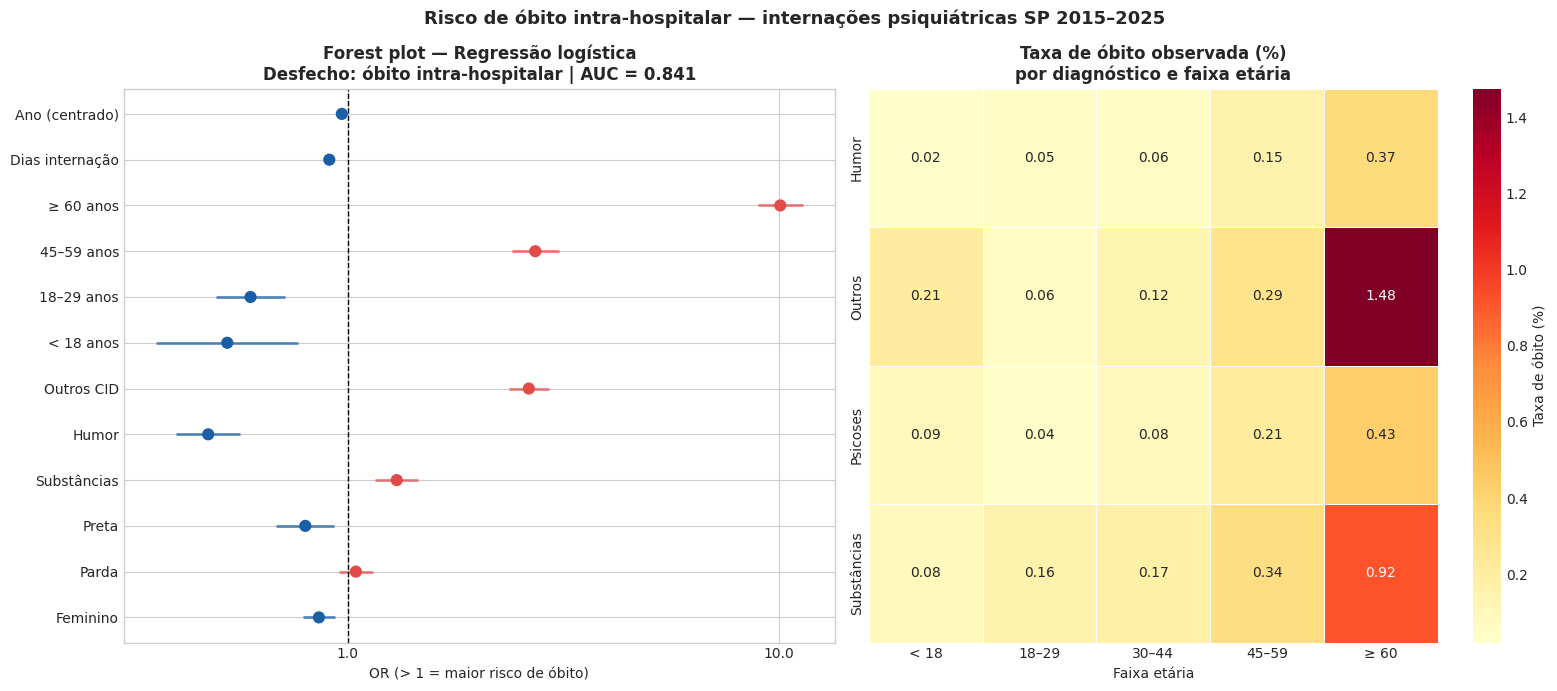

In [13]:
# ============================================================
# CÉLULA 8 — Regressão logística: risco de óbito
# ============================================================
from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------
# Preparar dados
# ------------------------------------------------------------
df_logit = df_sih[
    df_sih['raca'].isin(RACAS_ANALISE) &
    df_sih['sexo_label'].notna() &
    df_sih['faixa_etaria'].notna() &
    df_sih['cid_grupo'].notna() &
    df_sih['dias_internacao'].notna()
].copy()

# Encoding
df_logit['fem']        = (df_logit['sexo_label'] == 'Feminino').astype(int)
df_logit['parda']      = (df_logit['raca'] == 'Parda').astype(int)
df_logit['preta']      = (df_logit['raca'] == 'Preta').astype(int)
df_logit['subst']      = (df_logit['cid_grupo'] == 'Substâncias (F10–F19)').astype(int)
df_logit['humor']      = (df_logit['cid_grupo'] == 'Humor (F30–F39)').astype(int)
df_logit['outros_cid'] = (df_logit['cid_grupo'] == 'Outros').astype(int)
df_logit['fx_lt18']    = (df_logit['faixa_etaria'] == '< 18').astype(int)
df_logit['fx_1829']    = (df_logit['faixa_etaria'] == '18–29').astype(int)
df_logit['fx_4559']    = (df_logit['faixa_etaria'] == '45–59').astype(int)
df_logit['fx_ge60']    = (df_logit['faixa_etaria'] == '≥ 60').astype(int)
df_logit['ano_c']      = df_logit['ano'] - 2015
df_logit['dias_c']     = (df_logit['dias_internacao'] -
                          df_logit['dias_internacao'].median())

covs_logit = ['fem', 'parda', 'preta',
              'subst', 'humor', 'outros_cid',
              'fx_lt18', 'fx_1829', 'fx_4559', 'fx_ge60',
              'dias_c', 'ano_c']

X_logit = sm.add_constant(df_logit[covs_logit].astype(float))
y_logit = df_logit['obito'].astype(float)

print('=' * 60)
print('TESTE 8 — Regressão logística: risco de óbito')
print('=' * 60)
print(f'\n  N total   : {len(df_logit):,}')
print(f'  N óbitos  : {int(y_logit.sum()):,} ({y_logit.mean()*100:.2f}%)')

# ------------------------------------------------------------
# Ajustar modelo
# ------------------------------------------------------------
modelo_logit = sm.Logit(y_logit, X_logit).fit(
    maxiter=200, disp=False
)

# AUC
pred_prob = modelo_logit.predict(X_logit)
auc       = roc_auc_score(y_logit, pred_prob)

print(f'  AUC       : {auc:.3f}')
print(f'  Pseudo-R² : {1 - modelo_logit.llf/modelo_logit.llnull:.3f}')

# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------
labels_logit = {
    'fem'       : 'Feminino',
    'parda'     : 'Parda',
    'preta'     : 'Preta',
    'subst'     : 'Substâncias',
    'humor'     : 'Humor',
    'outros_cid': 'Outros CID',
    'fx_lt18'   : '< 18 anos',
    'fx_1829'   : '18–29 anos',
    'fx_4559'   : '45–59 anos',
    'fx_ge60'   : '≥ 60 anos',
    'dias_c'    : 'Dias internação',
    'ano_c'     : 'Ano (centrado)',
}

print(f'\n  Referências: Masculino | Branca | Psicoses | 30–44 anos')
print(f'\n  {"Variável":<22} {"OR":>8} {"IC 95% inf":>12} '
      f'{"IC 95% sup":>12} {"p":>10} {"Sig."}')
print(f'  {"-"*72}')

ci = modelo_logit.conf_int()
for cov in covs_logit:
    coef  = modelo_logit.params[cov]
    or_v  = np.exp(coef)
    lo    = np.exp(ci.loc[cov, 0])
    hi    = np.exp(ci.loc[cov, 1])
    p_v   = modelo_logit.pvalues[cov]
    lbl   = labels_logit.get(cov, cov)
    register_p(f'T8_logit_{cov}', p_v)
    print(f'  {lbl:<22} {or_v:>8.3f} {lo:>12.3f} {hi:>12.3f} '
          f'{p_v:>10.4f} {sig_label(p_v)}')

# ------------------------------------------------------------
# Probabilidades preditas por grupo
# ------------------------------------------------------------
print(f'\n--- Probabilidade predita de óbito por grupo ---')
print(f'  (mantendo demais variáveis na mediana/referência)')

grupos_pred = {
    'Branca + Masc + Psicoses + 30–44': {
        'fem':0,'parda':0,'preta':0,'subst':0,'humor':0,
        'outros_cid':0,'fx_lt18':0,'fx_1829':0,'fx_4559':0,
        'fx_ge60':0,'dias_c':0,'ano_c':5
    },
    'Parda  + Masc + Psicoses + 30–44': {
        'fem':0,'parda':1,'preta':0,'subst':0,'humor':0,
        'outros_cid':0,'fx_lt18':0,'fx_1829':0,'fx_4559':0,
        'fx_ge60':0,'dias_c':0,'ano_c':5
    },
    'Preta  + Masc + Psicoses + 30–44': {
        'fem':0,'parda':0,'preta':1,'subst':0,'humor':0,
        'outros_cid':0,'fx_lt18':0,'fx_1829':0,'fx_4559':0,
        'fx_ge60':0,'dias_c':0,'ano_c':5
    },
    'Branca + Fem  + Psicoses + 30–44': {
        'fem':1,'parda':0,'preta':0,'subst':0,'humor':0,
        'outros_cid':0,'fx_lt18':0,'fx_1829':0,'fx_4559':0,
        'fx_ge60':0,'dias_c':0,'ano_c':5
    },
    'Branca + Masc + Substâncias + 30–44': {
        'fem':0,'parda':0,'preta':0,'subst':1,'humor':0,
        'outros_cid':0,'fx_lt18':0,'fx_1829':0,'fx_4559':0,
        'fx_ge60':0,'dias_c':0,'ano_c':5
    },
    'Branca + Masc + Psicoses + ≥60': {
        'fem':0,'parda':0,'preta':0,'subst':0,'humor':0,
        'outros_cid':0,'fx_lt18':0,'fx_1829':0,'fx_4559':0,
        'fx_ge60':1,'dias_c':0,'ano_c':5
    },
}

const = modelo_logit.params['const']
for nome, vals in grupos_pred.items():
    logit_val = const + sum(
        modelo_logit.params[k] * v for k, v in vals.items()
    )
    prob = 1 / (1 + np.exp(-logit_val)) * 100
    print(f'  {nome:<40} {prob:.3f}%')

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Painel 1 — Forest plot OR
ax = axes[0]
ors   = [np.exp(modelo_logit.params[c]) for c in covs_logit]
lo_ci = [np.exp(ci.loc[c, 0]) for c in covs_logit]
hi_ci = [np.exp(ci.loc[c, 1]) for c in covs_logit]
lbls  = [labels_logit[c] for c in covs_logit]
y_pos = range(len(covs_logit))

cores_or = ['#E24B4A' if o > 1 else '#185FA5' for o in ors]
ax.scatter(ors, y_pos, color=cores_or, s=60, zorder=5)
ax.hlines(y_pos, lo_ci, hi_ci, color=cores_or, linewidth=2, alpha=0.7)
ax.axvline(x=1, color='black', linewidth=1, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(lbls, fontsize=10)
ax.set_xlabel('OR (> 1 = maior risco de óbito)')
ax.set_title(f'Forest plot — Regressão logística\n'
             f'Desfecho: óbito intra-hospitalar | AUC = {auc:.3f}',
             fontweight='bold')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

# Painel 2 — Taxa de óbito observada por grupo diagnóstico e faixa etária
ax = axes[1]
pivot = (df_logit.groupby(['cid_grupo', 'faixa_etaria'])['obito']
         .mean().unstack() * 100)
pivot = pivot.reindex(columns=['< 18', '18–29', '30–44', '45–59', '≥ 60'])
pivot.index = [i.split(' ')[0] for i in pivot.index]
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, cbar_kws={'label': 'Taxa de óbito (%)'},
            linewidths=0.5)
ax.set_title('Taxa de óbito observada (%)\npor diagnóstico e faixa etária',
             fontweight='bold')
ax.set_xlabel('Faixa etária')
ax.set_ylabel('')

plt.suptitle('Risco de óbito intra-hospitalar — internações psiquiátricas SP 2015–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/08_logistica_obito.png', dpi=150, bbox_inches='tight')
plt.show()

### Resultados — Regressão logística: risco de óbito

O modelo apresentou boa discriminação (AUC = 0.841) para
dados administrativos sem informações clínicas de gravidade.

**Raça:** pardos não diferem significativamente de brancos
no risco de óbito (OR = 1.045, p = 0.338). Pretos apresentam
risco 20.2% menor que brancos (OR = 0.798, IC 95%: 0.683–0.933,
p = 0.005). Esse achado é contraintuitivo e merece interpretação
cuidadosa — uma hipótese é que pretos internam em episódios
agudos com menor comorbidade clínica geral, enquanto brancos
internam com maior proporção de demência e condições crônicas
(grupo "Outros CID"), que têm a maior taxa de óbito do modelo.

**Sexo:** mulheres têm risco de óbito 14.2% menor que homens
(OR = 0.858, IC 95%: 0.786–0.937, p < 0.001), após controle
por diagnóstico e faixa etária.

**Diagnóstico:** transtornos de humor têm o menor risco de
óbito (OR = 0.475 vs psicoses), enquanto o grupo "Outros CID"
tem o maior (OR = 2.632). Substâncias têm risco 30% maior
que psicoses (OR = 1.300).

**Faixa etária:** o preditor mais forte do modelo — idosos
(≥ 60 anos) têm risco 10 vezes maior que adultos de 30–44
anos (OR = 10.072, IC 95%: 8.936–11.353). O heatmap mostra
que a combinação Outros CID + ≥ 60 anos tem taxa de óbito
observada de 1.48% — 5.5 vezes a taxa geral.

**Dias de internação:** cada dia adicional reduz o risco de
óbito em 9.3% (OR = 0.907). Isso indica que os óbitos ocorrem
predominantemente no início da internação — pacientes que
chegam em estado crítico e morrem nos primeiros dias, não
aqueles com internações prolongadas.

**Tendência temporal:** o risco de óbito caiu 3.0% ao ano
(OR = 0.970, p < 0.001), independentemente das demais
variáveis — sugerindo melhora na qualidade do cuidado
intra-hospitalar ao longo do período.

**Probabilidades preditas:** a probabilidade de óbito para
o perfil de referência (branco, masculino, psicose, 30–44
anos, mediana de dias, ano 2020) é de 0.051%. Para idosos
com o mesmo perfil, sobe para 0.513% — dez vezes maior.

> **Limitação:** o modelo não controla por gravidade clínica
> na admissão — variável não disponível nos dados
> administrativos. Parte das diferenças por diagnóstico e
> faixa etária pode refletir diferenças de gravidade, não
> de qualidade do cuidado.

## Célula 9 — Equidade diagnóstica: raça × CID

### Pergunta
A distribuição de diagnósticos psiquiátricos difere entre
grupos raciais? Os padrões observados são consistentes com
viés diagnóstico ou acesso diferencial a serviços especializados?

### Por que essa análise importa

O diagnóstico psiquiátrico é mediado pelo acesso ao sistema,
pela qualidade do vínculo terapêutico e por vieses implícitos
do avaliador. Estudos internacionais documentam que populações
negras recebem mais diagnósticos de psicose e menos de
transtornos de humor do que populações brancas com
apresentações clínicas semelhantes (Strakowski et al., 2003;
Neighbors et al., 2003). Os dados administrativos permitem
uma aproximação ecológica desse fenômeno no contexto brasileiro.

### Testes utilizados

**Qui-quadrado + V de Cramér:** testa se a distribuição de
diagnósticos difere entre grupos raciais e quantifica o
tamanho do efeito independentemente do n.

**Resíduos padronizados de Pearson:** identificam quais
combinações raça × diagnóstico são mais discrepantes do
esperado sob independência. Resíduo > 2 ou < −2 indica
célula com contribuição significativa ao χ².

TESTE 9 — Equidade diagnóstica: raça × CID

  χ²(20) = 9401, p = 0.0000 ***
  V de Cramér = 0.093 (negligível)
  N = 540,795

  Proporção de cada diagnóstico por raça (%):
  Diagnóstico                         Branca       Parda       Preta       P-B
  -----------------------------------------------------------------
  Bipolar — mania grave                7.5%       9.7%       6.2%    +2.2pp
  Borderline                           2.8%       2.6%       1.6%    -0.2pp
  Demência NE                          2.8%       1.2%       2.1%    -1.6pp
  Dependência cocaína                  4.4%       4.2%       4.2%    -0.2pp
  Dependência álcool                  12.9%      11.9%      10.5%    -1.1pp
  Depressão grave                      3.3%       3.3%       1.8%    -0.0pp
  Esquizofrenia paranoide             25.0%      22.5%      24.1%    -2.5pp
  Esquizofrenia residual               8.1%       4.1%       8.9%    -4.0pp
  Múltiplas drogas                    20.8%      24.2%      26.0%    +3.4

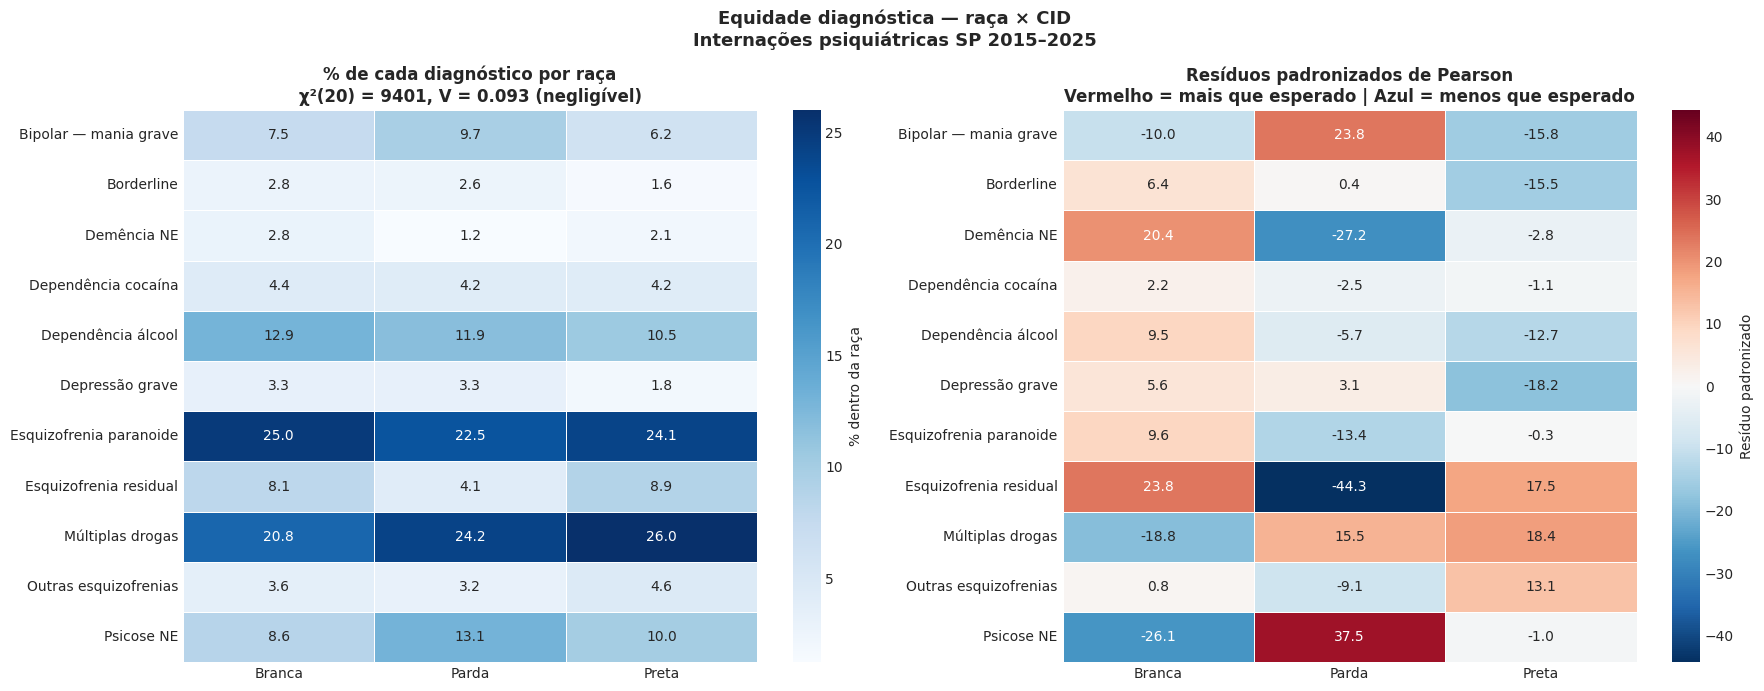

In [14]:
# ============================================================
# CÉLULA 9 — Equidade diagnóstica: raça × CID
# ============================================================

CIDS_EQ = list(CID_MAP.keys())

df_eq = df_sih[
    df_sih['raca'].isin(RACAS_ANALISE) &
    df_sih['cid_principal'].isin(CIDS_EQ) &
    df_sih['cid_label'].notna()
].copy()

# ------------------------------------------------------------
# Tabela de contingência e qui-quadrado
# ------------------------------------------------------------
tabela = pd.crosstab(df_eq['cid_label'], df_eq['raca'])

chi2_val, p_chi, dof, expected = chi2_contingency(tabela)
n_chi = tabela.values.sum()
v     = cramers_v(chi2_val, n_chi, *tabela.shape)
register_p('T9_chi2_raca_cid', p_chi)

print('=' * 65)
print('TESTE 9 — Equidade diagnóstica: raça × CID')
print('=' * 65)
print(f'\n  χ²({dof}) = {chi2_val:.0f}, p = {p_chi:.4f} {sig_label(p_chi)}')
print(f'  V de Cramér = {v:.3f} ({effect_size_label(v)})')
print(f'  N = {n_chi:,}')

# ------------------------------------------------------------
# Proporção por raça
# ------------------------------------------------------------
prop = tabela.div(tabela.sum(axis=0), axis=1) * 100

print(f'\n  Proporção de cada diagnóstico por raça (%):')
print(f'  {"Diagnóstico":<30}', end='')
for r in RACAS_ANALISE:
    print(f'  {r:>10}', end='')
print(f'  {"P-B":>8}')
print(f'  {"-"*65}')
for cid in prop.index:
    b  = prop.loc[cid, 'Branca'] if 'Branca' in prop.columns else 0
    pa = prop.loc[cid, 'Parda']  if 'Parda'  in prop.columns else 0
    pr = prop.loc[cid, 'Preta']  if 'Preta'  in prop.columns else 0
    print(f'  {cid:<30} {b:>9.1f}% {pa:>9.1f}% '
          f'{pr:>9.1f}% {pa-b:>+7.1f}pp')

# ------------------------------------------------------------
# Resíduos padronizados
# ------------------------------------------------------------
residuos  = (tabela.values - expected) / np.sqrt(expected)
df_resid  = pd.DataFrame(residuos,
                          index=tabela.index,
                          columns=tabela.columns)

print(f'\n  Resíduos padronizados de Pearson (|r| > 2 = significativo):')
print(f'  {"Diagnóstico":<30}', end='')
for r in RACAS_ANALISE:
    print(f'  {r:>10}', end='')
print()
print(f'  {"-"*55}')
for cid in df_resid.index:
    print(f'  {cid:<30}', end='')
    for r in RACAS_ANALISE:
        val  = df_resid.loc[cid, r] if r in df_resid.columns else 0
        flag = ' ◄' if abs(val) > 2 else ''
        print(f'  {val:>+9.1f}{flag}', end='')
    print()

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Painel 1 — heatmap de proporções
ax = axes[0]
sns.heatmap(prop, annot=True, fmt='.1f', cmap='Blues',
            ax=ax, cbar_kws={'label': '% dentro da raça'},
            linewidths=0.5)
ax.set_title(f'% de cada diagnóstico por raça\n'
             f'χ²({dof}) = {chi2_val:.0f}, '
             f'V = {v:.3f} ({effect_size_label(v)})',
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')

# Painel 2 — heatmap de resíduos padronizados
ax = axes[1]
vmax = max(abs(df_resid.values.min()), abs(df_resid.values.max()))
sns.heatmap(df_resid[RACAS_ANALISE], annot=True, fmt='.1f',
            cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            ax=ax, cbar_kws={'label': 'Resíduo padronizado'},
            linewidths=0.5)
ax.set_title('Resíduos padronizados de Pearson\n'
             'Vermelho = mais que esperado | Azul = menos que esperado',
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')

plt.suptitle('Equidade diagnóstica — raça × CID\n'
             'Internações psiquiátricas SP 2015–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/09_equidade_raca_cid.png', dpi=150, bbox_inches='tight')
plt.show()

### Resultados — Equidade diagnóstica: raça × CID

A distribuição de diagnósticos difere significativamente entre
grupos raciais (χ²(20) = 9.401, p < 0.001), com tamanho de
efeito negligível (V = 0.093) — padrão esperado com N = 540.795.
A análise de resíduos padronizados localiza onde as diferenças
são substantivas.

**Psicose NE:** pardos apresentam excesso expressivo
(resíduo = +37.5) e brancos déficit (-26.1). Psicose NE é
um diagnóstico inespecífico usado quando o quadro clínico
não permite categorização precisa — seu excesso em pardos
é consistente com acesso tardio ao sistema, com chegada
em crise aguda sem vínculo prévio com serviços de saúde mental.

**Esquizofrenia residual:** brancos têm excesso (+23.8) e
pardos déficit severo (-44.3). Esse diagnóstico pressupõe
acompanhamento longitudinal — o clínico precisa conhecer
a história prévia do paciente. Seu déficit em pardos
sugere descontinuidade no cuidado.

**Demência NE:** brancos têm excesso (+20.4) e pardos
déficit (-27.2). Demência requer investigação neurológica
especializada. O déficit em pardos pode refletir
subdiagnóstico ou diferença etária na composição dos grupos.

**Depressão grave em pretos:** resíduo de -18.2 indica
internações significativamente abaixo do esperado.
Padrão documentado internacionalmente como subdiagnóstico
de transtornos de humor em populações negras, com maior
tendência a receber diagnósticos de psicose para
apresentações semelhantes (Neighbors et al., 2003).

**Bipolar — mania grave:** pardos têm excesso (+23.8)
em relação ao esperado. Uma hipótese é que pardos chegam
em episódios mais graves, favorecendo o diagnóstico de
mania grave sobre formas menos severas do espectro bipolar.

> **Síntese:** brancos concentram diagnósticos que requerem
> acompanhamento longitudinal (esquizofrenia residual,
> demência, borderline). Pardos e pretos concentram
> diagnósticos de porta de entrada em crise (psicose NE,
> múltiplas drogas, mania grave). Esse padrão é consistente
> com acesso diferencial ao sistema — não necessariamente
> com diferença na prevalência real dos transtornos.

## Célula 10 — Equidade diagnóstica: sexo × CID

### Pergunta
A distribuição de diagnósticos psiquiátricos difere entre
homens e mulheres? Os padrões são consistentes com a
epidemiologia internacional ou sugerem viés diagnóstico?

### Contexto clínico

A epidemiologia psiquiátrica documenta diferenças robustas
na prevalência de transtornos entre sexos. Homens têm maior
prevalência de transtornos por uso de substâncias e
esquizofrenia de início precoce; mulheres têm maior
prevalência de transtornos de humor, ansiedade e transtornos
de personalidade do cluster B (Kessler et al., 2005; WHO, 2022).

### Diferença metodológica em relação à Célula 9

Com apenas duas categorias (masculino/feminino), calculamos
o OR por diagnóstico com IC 95% pelo método de Woolf —
que quantifica quantas vezes mais provável é uma mulher
receber aquele diagnóstico em relação a um homem.

TESTE 10 — Equidade diagnóstica: sexo × CID

  χ²(10) = 69210, p = 0.0000 ***
  V de Cramér = 0.340 (médio)
  N = 598,698

  Diagnóstico                      Masc%    Fem%      Dif       OR             IC 95% Sig.
  --------------------------------------------------------------------------------------------
  Bipolar — mania grave             4.3%   15.1%   +10.8pp     3.96        [3.89–4.04] ***
  Borderline                        0.9%    5.4%    +4.6pp     6.50        [6.25–6.76] ***
  Demência NE                       1.6%    3.5%    +1.9pp     2.21        [2.13–2.28] ***
  Dependência cocaína               4.4%    3.5%    -0.9pp     0.79        [0.77–0.82] ***
  Dependência álcool               16.3%    4.1%   -12.2pp     0.22        [0.22–0.23] ***
  Depressão grave                   1.8%    5.5%    +3.6pp     3.08        [2.99–3.18] ***
  Esquizofrenia paranoide          24.6%   25.4%    +0.7pp     1.04        [1.03–1.05] ***
  Esquizofrenia residual            7.3%    7.2%    -0

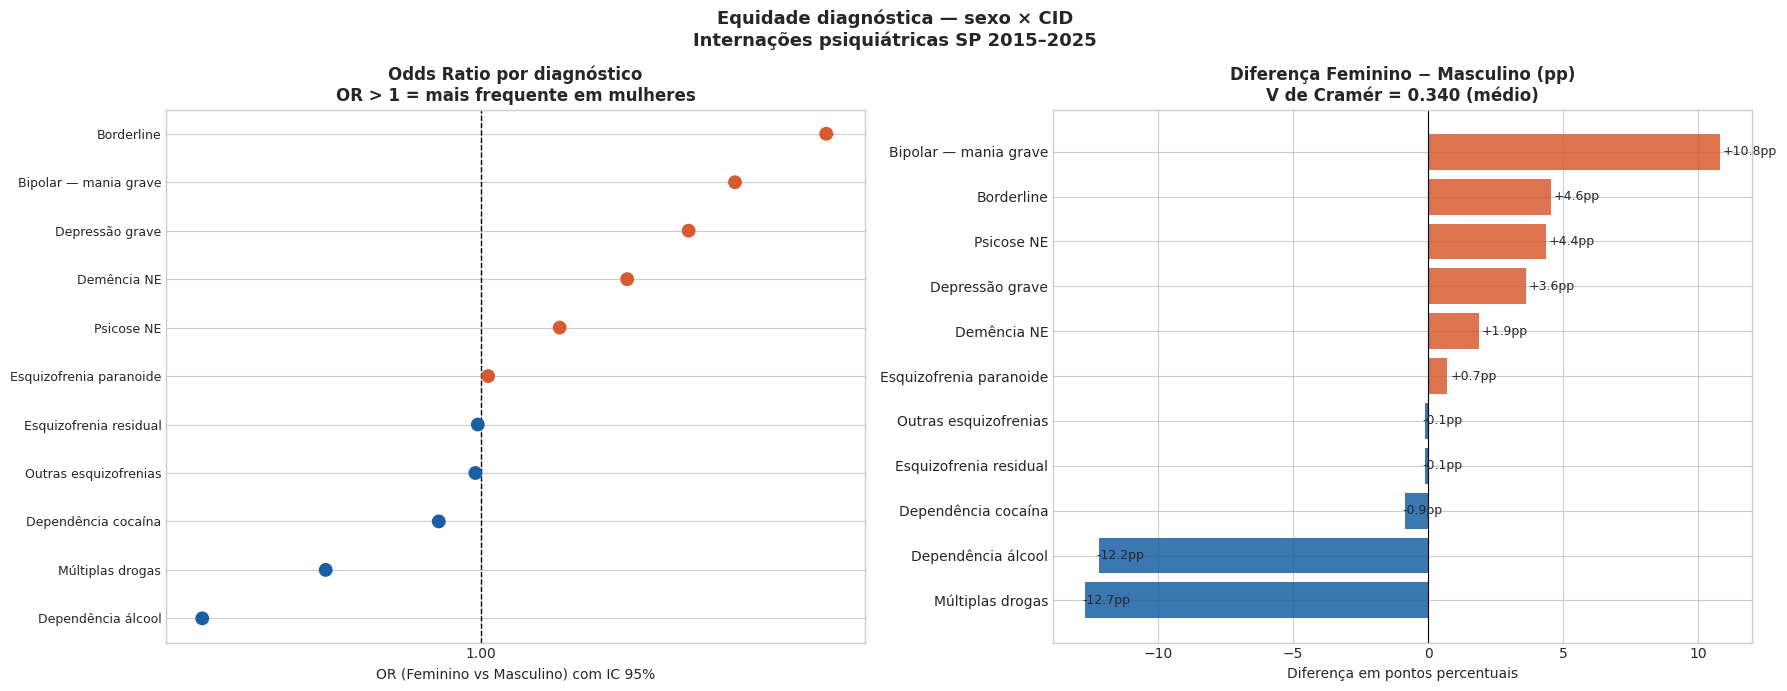

In [15]:
# ============================================================
# CÉLULA 10 — Equidade diagnóstica: sexo × CID
# ============================================================

df_eq_s = df_sih[
    df_sih['sexo_label'].notna() &
    df_sih['cid_principal'].isin(CIDS_EQ) &
    df_sih['cid_label'].notna()
].copy()

# ------------------------------------------------------------
# Tabela de contingência e qui-quadrado global
# ------------------------------------------------------------
tabela_s = pd.crosstab(df_eq_s['cid_label'], df_eq_s['sexo_label'])

chi2_s, p_chi_s, dof_s, expected_s = chi2_contingency(tabela_s)
n_chi_s = tabela_s.values.sum()
v_s     = cramers_v(chi2_s, n_chi_s, *tabela_s.shape)
register_p('T10_chi2_sexo_cid', p_chi_s)

print('=' * 65)
print('TESTE 10 — Equidade diagnóstica: sexo × CID')
print('=' * 65)
print(f'\n  χ²({dof_s}) = {chi2_s:.0f}, p = {p_chi_s:.4f} {sig_label(p_chi_s)}')
print(f'  V de Cramér = {v_s:.3f} ({effect_size_label(v_s)})')
print(f'  N = {n_chi_s:,}')

# ------------------------------------------------------------
# Proporção + OR por diagnóstico
# ------------------------------------------------------------
prop_s  = tabela_s.div(tabela_s.sum(axis=0), axis=1) * 100
tot_m   = tabela_s['Masculino'].sum()
tot_f   = tabela_s['Feminino'].sum()
diff_sf = (prop_s['Feminino'] - prop_s['Masculino']).sort_values()

print(f'\n  {"Diagnóstico":<30} {"Masc%":>7} {"Fem%":>7} '
      f'{"Dif":>8} {"OR":>8} {"IC 95%":>18} {"Sig."}')
print(f'  {"-"*92}')

resultados_or = []
for cid in tabela_s.index:
    nm = tabela_s.loc[cid, 'Masculino']
    nf = tabela_s.loc[cid, 'Feminino']
    pm = nm / tot_m
    pf = nf / tot_f
    if pm > 0 and pf > 0 and pm < 1 and pf < 1:
        or_v   = (pf/(1-pf)) / (pm/(1-pm))
        se_log = np.sqrt(1/nf + 1/(tot_f-nf) + 1/nm + 1/(tot_m-nm))
        lo_or  = np.exp(np.log(or_v) - 1.96*se_log)
        hi_or  = np.exp(np.log(or_v) + 1.96*se_log)
        tab_or = np.array([[nf, tot_f-nf],[nm, tot_m-nm]])
        _, p_or, _, _ = chi2_contingency(tab_or)
    else:
        or_v = lo_or = hi_or = p_or = np.nan
    register_p(f'T10_OR_{cid}', p_or if not np.isnan(p_or) else 1.0)
    resultados_or.append({
        'cid': cid, 'pct_m': pm*100, 'pct_f': pf*100,
        'OR': or_v, 'ic_low': lo_or, 'ic_high': hi_or, 'p': p_or
    })
    dif_v  = pf*100 - pm*100
    or_str = f'{or_v:.2f}' if not np.isnan(or_v) else 'n/d'
    ic_str = f'[{lo_or:.2f}–{hi_or:.2f}]' if not np.isnan(lo_or) else 'n/d'
    sig_str= sig_label(p_or) if not np.isnan(p_or) else 'n/d'
    print(f'  {cid:<30} {pm*100:>6.1f}% {pf*100:>6.1f}% '
          f'{dif_v:>+7.1f}pp {or_str:>8} {ic_str:>18} {sig_str}')

df_or = pd.DataFrame(resultados_or).sort_values('OR', ascending=False)

# ------------------------------------------------------------
# Resíduos padronizados
# ------------------------------------------------------------
residuos_s = (tabela_s.values - expected_s) / np.sqrt(expected_s)
df_resid_s = pd.DataFrame(residuos_s,
                           index=tabela_s.index,
                           columns=tabela_s.columns)

print(f'\n  Resíduos padronizados de Pearson:')
print(f'  {"Diagnóstico":<30} {"Masculino":>12} {"Feminino":>12}')
print(f'  {"-"*56}')
for cid in df_resid_s.index:
    rm = df_resid_s.loc[cid, 'Masculino']
    rf = df_resid_s.loc[cid, 'Feminino']
    fm = ' ◄' if abs(rm) > 2 else ''
    ff = ' ◄' if abs(rf) > 2 else ''
    print(f'  {cid:<30} {rm:>+11.1f}{fm} {rf:>+11.1f}{ff}')

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Painel 1 — forest plot OR
ax = axes[0]
df_or_plot = df_or.dropna(subset=['OR']).sort_values('OR')
y_pos = range(len(df_or_plot))
cores_hr = ['#D85A30' if o > 1 else '#185FA5'
            for o in df_or_plot['OR']]
ax.scatter(df_or_plot['OR'], y_pos,
           color=cores_hr, s=80, zorder=5)
ax.hlines(y_pos, df_or_plot['ic_low'], df_or_plot['ic_high'],
          color=cores_hr, linewidth=2, alpha=0.7)
ax.axvline(x=1, color='black', linewidth=1, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(df_or_plot['cid'], fontsize=9)
ax.set_xlabel('OR (Feminino vs Masculino) com IC 95%')
ax.set_title(f'Odds Ratio por diagnóstico\nOR > 1 = mais frequente em mulheres',
             fontweight='bold')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

# Painel 2 — diferença F-M em pp
ax = axes[1]
cores_d = ['#D85A30' if v > 0 else '#185FA5'
           for v in diff_sf.values]
bars = ax.barh(diff_sf.index, diff_sf.values,
               color=cores_d, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
for bar, val in zip(bars, diff_sf.values):
    ax.text(val + (0.1 if val >= 0 else -0.1),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}pp', va='center', fontsize=9)
ax.set_title(f'Diferença Feminino − Masculino (pp)\n'
             f'V de Cramér = {v_s:.3f} ({effect_size_label(v_s)})',
             fontweight='bold')
ax.set_xlabel('Diferença em pontos percentuais')

plt.suptitle('Equidade diagnóstica — sexo × CID\n'
             'Internações psiquiátricas SP 2015–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/10_equidade_sexo_cid.png', dpi=150, bbox_inches='tight')
plt.show()

### Resultados — Equidade diagnóstica: sexo × CID

A distribuição de diagnósticos difere substancialmente entre
sexos (χ²(10) = 69.210, p < 0.001, V de Cramér = 0.340 —
efeito médio). O tamanho de efeito é consideravelmente maior
do que o observado na análise racial (V = 0.093), indicando
que as diferenças por sexo na composição diagnóstica são
mais expressivas do que as diferenças por raça.

**Borderline:** maior OR individual — mulheres têm 6.5 vezes
mais chance de receber esse diagnóstico que homens
(OR = 6.50, IC 95%: 6.25–6.76). Duas leituras não
excludentes: maior prevalência real em mulheres, e viés
diagnóstico — homens com apresentação clínica semelhante
recebem mais frequentemente diagnósticos de transtorno
antissocial ou uso de substâncias.

**Bipolar — mania grave:** maior gap em pontos percentuais
(+10.8pp). Mulheres têm 3.96 vezes mais chance de internação
por mania grave (IC 95%: 3.89–4.04). Os resíduos padronizados
são os mais extremos da tabela (feminino: +112.8; masculino:
−83.8) — esse diagnóstico é o principal responsável pela
diferença global entre sexos.

**Depressão grave:** OR = 3.08 (IC 95%: 2.99–3.18) —
mulheres internam três vezes mais por depressão grave.
Consistente com a epidemiologia global, onde a prevalência
de depressão unipolar em mulheres é aproximadamente o dobro
da masculina.

**Transtornos por uso de substâncias:** homens dominam com
ampla margem — dependência de álcool (OR = 0.22) e múltiplas
drogas (OR = 0.43). Juntos somam 41.9% das internações
masculinas.

**Esquizofrenia:** residual (OR = 0.98, ns) e outras
esquizofrenias (OR = 0.97) não diferem entre sexos —
consistente com prevalência similar entre homens e mulheres,
embora com início mais tardio e curso menos grave no sexo
feminino.

**Psicose NE:** mulheres têm 53% mais chance de internação
por psicose NE (OR = 1.53). Em conjunto com o achado da
Célula 9 — onde pardos também apresentam excesso de psicose
NE — o diagnóstico inespecífico é mais frequente em grupos
com menor continuidade de cuidado, independentemente de
sexo ou raça.

> **Síntese:** o perfil masculino é dominado por transtornos
> por uso de substâncias; o feminino, por transtornos de
> humor e personalidade. Intervenções voltadas à dependência
> química têm impacto desproporcional sobre internações
> masculinas; políticas de saúde mental para mulheres
> precisam priorizar transtornos de humor e violência de
> gênero como determinante estrutural.

## Célula 11 — Tentativas de suicídio: perfil e métodos (SINAN)

### Pergunta
Quem tenta suicídio em SP? Quais métodos são utilizados?
O perfil sociodemográfico das tentativas difere do perfil
dos óbitos por suicídio (SIM)?

### Fontes e limitações

**SINAN — tentativas:** notificações de lesão autoprovocada
com `tentativa_suicidio = 1`. Captura apenas casos que
chegaram a um serviço de saúde — subnotificação estrutural,
especialmente em municípios menores.

**SIM — óbitos:** registros com CID X60–X84. Cobertura mais
completa, mas sujeita a subnotificação por classificação
incorreta da causa mortis.

**Métodos:** codificados pelo CID da circunstância (X60–X84),
com cobertura de 100% dos registros. Agrupados pelo código
de 3 caracteres para evitar fragmentação por subclassificação.

### Testes utilizados

**Qui-quadrado + V de Cramér:** compara a distribuição de
sexo e raça entre tentativas (SINAN) e óbitos (SIM).

**Resíduos padronizados:** identificam quais grupos
contribuem mais para a diferença entre os dois desfechos.

**Análise de métodos por sexo:** qui-quadrado + V de Cramér
testam se a distribuição de métodos difere entre homens
e mulheres — hipótese central para explicar o paradoxo
de gênero no suicídio (mulheres tentam mais, homens
morrem mais).

### Qualidade das variáveis

- Sexo e raça/cor: cobertura adequada — analisadas com
  testes formais
- Orientação sexual: 26% ignorados — descritivo com ressalva
- Identidade de gênero: 68% "não se aplica" — nota
  metodológica apenas

TESTE 11 — Tentativas de suicídio: perfil e métodos

  Total: 165,543 | Período: 2015–2025

--- 11a: Sexo — tentativas vs óbitos ---
  Sexo             Tentativas      %     Óbitos      %
  ----------------------------------------------------
  Feminino            114,133   69.0%      3,900   21.7%
  Masculino            51,370   31.0%     14,052   78.3%

  χ²(1) = 15747.9, p = 0.0000 ***
  V de Cramér = 0.293 (pequeno)

--- 11b: Raça — tentativas vs óbitos ---
  Raça           Tentativas      %     Óbitos      %
  --------------------------------------------------
  Branca             97,975   62.3%     11,855   66.6%
  Parda              48,334   30.7%      4,893   27.5%
  Preta              10,989    7.0%        889    5.0%

  χ²(2) = 196.2, p = 0.0000 ***
  V de Cramér = 0.033 (negligível)

  Resíduos padronizados:
  Raça         Tentativas       Óbitos
  ------------------------------------
  Branca            -2.5        +7.4
  Parda             +2.2        -6.5
  Preta          

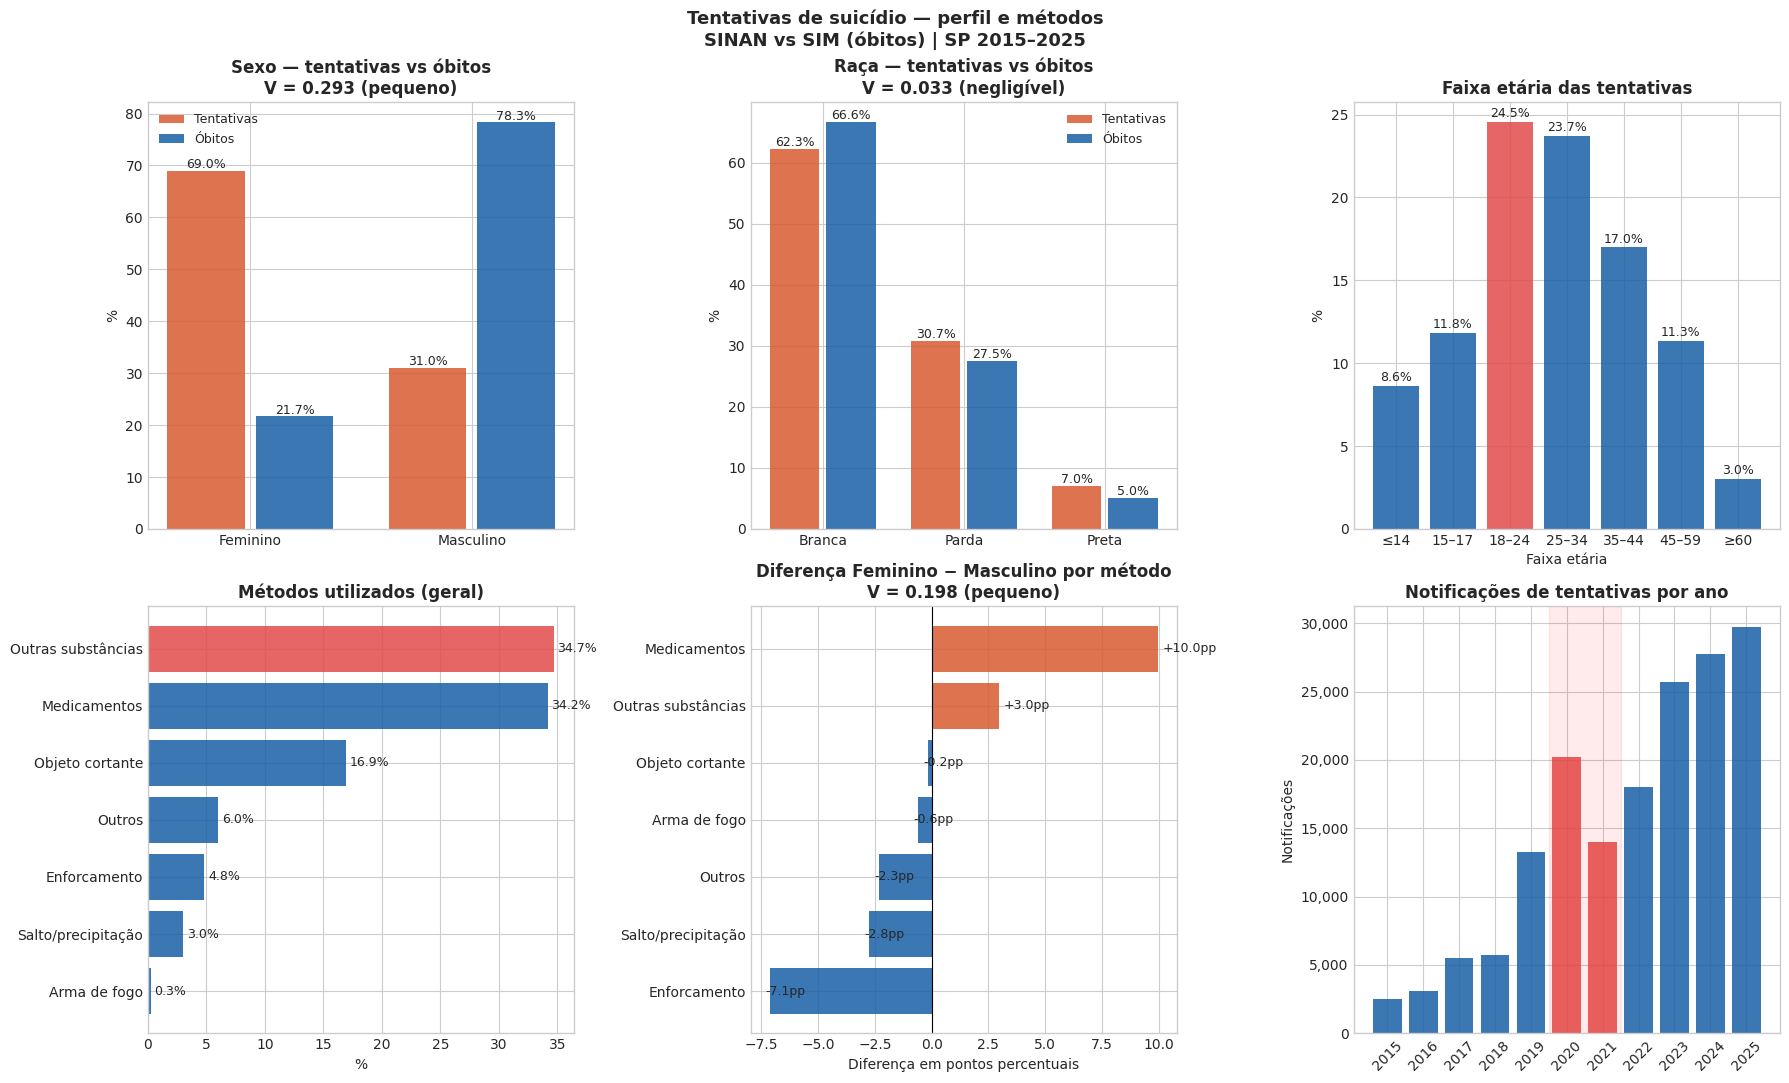

In [16]:
# ============================================================
# CÉLULA 11 — Tentativas de suicídio: perfil e métodos
# ============================================================

# ------------------------------------------------------------
# Mapa de métodos CID X60–X84
# ------------------------------------------------------------
METODO_MAP = {
    'X60': 'Medicamentos',
    'X61': 'Medicamentos',
    'X62': 'Medicamentos',
    'X63': 'Outras substâncias',
    'X64': 'Outras substâncias',
    'X65': 'Álcool',
    'X66': 'Solventes',
    'X67': 'Gases/vapores',
    'X68': 'Pesticidas',
    'X69': 'Outras substâncias',
    'X70': 'Enforcamento',
    'X71': 'Afogamento',
    'X72': 'Arma de fogo',
    'X73': 'Arma de fogo',
    'X74': 'Arma de fogo',
    'X75': 'Explosivos',
    'X76': 'Fogo/chamas',
    'X77': 'Vapor/objetos quentes',
    'X78': 'Objeto cortante',
    'X79': 'Objeto contundente',
    'X80': 'Salto de lugar elevado',
    'X81': 'Veículo em movimento',
    'X82': 'Colisão de veículo',
    'X83': 'Outros meios',
    'X84': 'Outros meios',
}

# Agrupar métodos em categorias analíticas
METODO_GRUPO = {
    'Medicamentos'        : ['X60','X61','X62'],
    'Outras substâncias'  : ['X63','X64','X65','X66','X67','X68','X69'],
    'Enforcamento'        : ['X70'],
    'Objeto cortante'     : ['X78'],
    'Arma de fogo'        : ['X72','X73','X74'],
    'Salto/precipitação'  : ['X80'],
    'Outros'              : ['X71','X75','X76','X77','X79',
                             'X81','X82','X83','X84'],
}
# Mapa inverso: código → grupo
CID3_TO_GRUPO = {}
for grupo, cids in METODO_GRUPO.items():
    for c in cids:
        CID3_TO_GRUPO[c] = grupo

# Extrair código de 3 caracteres e mapear grupo
df_sinan['cid3']        = df_sinan['or_label'].apply(
    lambda x: x  # placeholder — usar cid_circunstancia
)

# Recarregar com cid_circunstancia
df_sinan2 = query("""
    SELECT ano, sexo, raca_cor, idade_raw,
           orientacao_sexual, ocorreu_outras_vezes,
           cid_circunstancia
    FROM sus_pipeline.sinan_violencia_silver
    WHERE tentativa_suicidio = 1
      AND ano NOT IN ('2026')
""")
df_sinan2['ano']        = df_sinan2['ano'].astype(str).str.strip()
df_sinan2['idade_num']  = df_sinan2['idade_raw'].apply(parse_idade_sinan)
df_sinan2['sexo_label'] = df_sinan2['sexo'].map(SEXO_SINAN)
df_sinan2['raca_label'] = df_sinan2['raca_cor'].map(RACA_SINAN)
df_sinan2['cid3']       = df_sinan2['cid_circunstancia'].str.strip().str[:3]
df_sinan2['metodo']     = df_sinan2['cid3'].map(CID3_TO_GRUPO).fillna('Outros')

bins_s   = [0, 14, 17, 24, 34, 44, 59, 200]
labels_s = ['≤14', '15–17', '18–24', '25–34', '35–44', '45–59', '≥60']
df_sinan2['faixa'] = pd.cut(
    df_sinan2['idade_num'], bins=bins_s, labels=labels_s, right=True
)

REINC_MAP = {'1': 'Sim', '2': 'Não', '9': 'Ignorado'}

print('=' * 65)
print('TESTE 11 — Tentativas de suicídio: perfil e métodos')
print('=' * 65)
print(f'\n  Total: {len(df_sinan2):,} | '
      f'Período: {df_sinan2["ano"].min()}–{df_sinan2["ano"].max()}')

# ------------------------------------------------------------
# Carregar óbitos do SIM para comparação
# ------------------------------------------------------------
df_sim_sexo = query("""
    SELECT sexo, COUNT(*) AS n
    FROM sus_pipeline.sim_suicidios
    WHERE sexo IN ('1', '2')
    GROUP BY sexo
""")
df_sim_sexo['sexo_label'] = df_sim_sexo['sexo'].map(
    {'1': 'Masculino', '2': 'Feminino'})
df_sim_sexo['n'] = pd.to_numeric(df_sim_sexo['n'], errors='coerce')

df_sim_raca = query("""
    SELECT raca_cor, COUNT(*) AS n
    FROM sus_pipeline.sim_suicidios
    WHERE raca_cor IN ('1','2','3','4','5')
    GROUP BY raca_cor
""")
df_sim_raca['raca_label'] = df_sim_raca['raca_cor'].map(RACA_SINAN)
df_sim_raca['n'] = pd.to_numeric(df_sim_raca['n'], errors='coerce')

sexo_obit = df_sim_sexo.set_index('sexo_label')['n']
raca_obit = df_sim_raca.set_index('raca_label')['n']
tot_o     = sexo_obit.sum()
tot_or    = raca_obit.sum()

# ------------------------------------------------------------
# 11a — Distribuição por sexo: tentativas vs óbitos
# ------------------------------------------------------------
print(f'\n--- 11a: Sexo — tentativas vs óbitos ---')
sexo_tent = df_sinan2['sexo_label'].value_counts(dropna=True)
tot_t     = sexo_tent.sum()

print(f'  {"Sexo":<12} {"Tentativas":>14} {"  %":>6} '
      f'{"Óbitos":>10} {"  %":>6}')
print(f'  {"-"*52}')
for s in ['Feminino', 'Masculino']:
    nt = sexo_tent.get(s, 0)
    no = sexo_obit.get(s, 0)
    print(f'  {s:<12} {nt:>14,} {nt/tot_t*100:>6.1f}% '
          f'{no:>10,} {no/tot_o*100:>6.1f}%')

tab_sexo = pd.DataFrame({
    'Tentativas': [sexo_tent.get('Feminino',  0),
                   sexo_tent.get('Masculino', 0)],
    'Óbitos'    : [sexo_obit.get('Feminino',  0),
                   sexo_obit.get('Masculino', 0)]
}, index=['Feminino', 'Masculino'])

chi2_s, p_s, dof_s, exp_s = chi2_contingency(tab_sexo)
v_s     = cramers_v(chi2_s, tab_sexo.values.sum(), *tab_sexo.shape)
resid_s = (tab_sexo.values - exp_s) / np.sqrt(exp_s)
register_p('T11_chi2_sexo_tent_obit', p_s)
print(f'\n  χ²({dof_s}) = {chi2_s:.1f}, p = {p_s:.4f} {sig_label(p_s)}')
print(f'  V de Cramér = {v_s:.3f} ({effect_size_label(v_s)})')

# ------------------------------------------------------------
# 11b — Distribuição por raça: tentativas vs óbitos
# ------------------------------------------------------------
print(f'\n--- 11b: Raça — tentativas vs óbitos ---')
RACAS_AN  = ['Branca', 'Parda', 'Preta']
raca_tent = df_sinan2[df_sinan2['raca_label'].isin(RACAS_AN)]['raca_label'].value_counts()
tot_tr    = raca_tent.sum()

print(f'  {"Raça":<10} {"Tentativas":>14} {"  %":>6} '
      f'{"Óbitos":>10} {"  %":>6}')
print(f'  {"-"*50}')
for r in RACAS_AN:
    nt = raca_tent.get(r, 0)
    no = raca_obit.get(r, 0)
    print(f'  {r:<10} {nt:>14,} {nt/tot_tr*100:>6.1f}% '
          f'{no:>10,} {no/tot_or*100:>6.1f}%')

tab_raca = pd.DataFrame({
    'Tentativas': [raca_tent.get(r, 0) for r in RACAS_AN],
    'Óbitos'    : [raca_obit.get(r, 0) for r in RACAS_AN]
}, index=RACAS_AN)

chi2_r, p_r, dof_r, exp_r = chi2_contingency(tab_raca)
v_r     = cramers_v(chi2_r, tab_raca.values.sum(), *tab_raca.shape)
resid_r = (tab_raca.values - exp_r) / np.sqrt(exp_r)
register_p('T11_chi2_raca_tent_obit', p_r)
print(f'\n  χ²({dof_r}) = {chi2_r:.1f}, p = {p_r:.4f} {sig_label(p_r)}')
print(f'  V de Cramér = {v_r:.3f} ({effect_size_label(v_r)})')
print(f'\n  Resíduos padronizados:')
print(f'  {"Raça":<10} {"Tentativas":>12} {"Óbitos":>12}')
print(f'  {"-"*36}')
for i, r in enumerate(RACAS_AN):
    print(f'  {r:<10} {resid_r[i,0]:>+11.1f} {resid_r[i,1]:>+11.1f}')

# ------------------------------------------------------------
# 11c — Faixa etária
# ------------------------------------------------------------
print(f'\n--- 11c: Faixa etária das tentativas ---')
faixa_dist = df_sinan2['faixa'].value_counts().sort_index()
tot_f      = faixa_dist.sum()
print(f'  {"Faixa":<10} {"N":>10} {"  %":>8}')
print(f'  {"-"*30}')
for f, n in faixa_dist.items():
    print(f'  {str(f):<10} {n:>10,} {n/tot_f*100:>7.1f}%')

# ------------------------------------------------------------
# 11d — Métodos: distribuição geral
# ------------------------------------------------------------
print(f'\n--- 11d: Métodos utilizados ---')
metodo_dist = df_sinan2['metodo'].value_counts()
tot_m       = metodo_dist.sum()
print(f'  {"Método":<25} {"N":>10} {"  %":>8}')
print(f'  {"-"*45}')
for m, n in metodo_dist.items():
    print(f'  {m:<25} {n:>10,} {n/tot_m*100:>7.1f}%')

# ------------------------------------------------------------
# 11e — Métodos por sexo (χ² + V de Cramér)
# ------------------------------------------------------------
df_met_sexo = df_sinan2[df_sinan2['sexo_label'].notna()].copy()
tab_met = pd.crosstab(df_met_sexo['metodo'], df_met_sexo['sexo_label'])
chi2_m, p_m, dof_m, exp_m = chi2_contingency(tab_met)
v_m     = cramers_v(chi2_m, tab_met.values.sum(), *tab_met.shape)
resid_m = (tab_met.values - exp_m) / np.sqrt(exp_m)
df_resid_m = pd.DataFrame(resid_m,
                           index=tab_met.index,
                           columns=tab_met.columns)
register_p('T11_chi2_metodo_sexo', p_m)

prop_met = tab_met.div(tab_met.sum(axis=0), axis=1) * 100

print(f'\n--- 11e: Métodos por sexo ---')
print(f'  χ²({dof_m}) = {chi2_m:.0f}, p = {p_m:.4f} {sig_label(p_m)}')
print(f'  V de Cramér = {v_m:.3f} ({effect_size_label(v_m)})')
print(f'\n  {"Método":<25} {"Masc%":>8} {"Fem%":>8} '
      f'{"Dif":>8} {"Res.M":>8} {"Res.F":>8}')
print(f'  {"-"*68}')
for m in prop_met.index:
    pm  = prop_met.loc[m, 'Masculino'] if 'Masculino' in prop_met.columns else 0
    pf  = prop_met.loc[m, 'Feminino']  if 'Feminino'  in prop_met.columns else 0
    rm  = df_resid_m.loc[m, 'Masculino'] if 'Masculino' in df_resid_m.columns else 0
    rf  = df_resid_m.loc[m, 'Feminino']  if 'Feminino'  in df_resid_m.columns else 0
    print(f'  {m:<25} {pm:>7.1f}% {pf:>7.1f}% '
          f'{pf-pm:>+7.1f}pp {rm:>+7.1f} {rf:>+7.1f}')

# ------------------------------------------------------------
# 11f — Reincidência
# ------------------------------------------------------------
print(f'\n--- 11f: Reincidência ---')
reinc  = df_sinan2['ocorreu_outras_vezes'].value_counts(dropna=False)
tot_rc = reinc.sum()
for cod, n in reinc.items():
    label = REINC_MAP.get(str(cod), str(cod))
    print(f'  {label:<12} {n:>8,} ({n/tot_rc*100:.1f}%)')

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Painel 1 — Sexo: tentativas vs óbitos
ax = axes[0, 0]
grupos = ['Feminino', 'Masculino']
pct_t  = [sexo_tent.get(g, 0)/tot_t*100 for g in grupos]
pct_o  = [sexo_obit.get(g, 0)/tot_o*100 for g in grupos]
x = np.arange(len(grupos))
b1 = ax.bar(x-0.2, pct_t, 0.35, label='Tentativas',
            color='#D85A30', alpha=0.85)
b2 = ax.bar(x+0.2, pct_o, 0.35, label='Óbitos',
            color='#185FA5', alpha=0.85)
for bar, v in zip(b1, pct_t):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5,
            f'{v:.1f}%', ha='center', fontsize=9)
for bar, v in zip(b2, pct_o):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5,
            f'{v:.1f}%', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(grupos)
ax.set_title(f'Sexo — tentativas vs óbitos\n'
             f'V = {v_s:.3f} ({effect_size_label(v_s)})',
             fontweight='bold')
ax.set_ylabel('%')
ax.legend(fontsize=9)

# Painel 2 — Raça: tentativas vs óbitos
ax = axes[0, 1]
pct_tr = [raca_tent.get(r, 0)/tot_tr*100 for r in RACAS_AN]
pct_or = [raca_obit.get(r, 0)/tot_or*100 for r in RACAS_AN]
x = np.arange(len(RACAS_AN))
b1 = ax.bar(x-0.2, pct_tr, 0.35, label='Tentativas',
            color='#D85A30', alpha=0.85)
b2 = ax.bar(x+0.2, pct_or, 0.35, label='Óbitos',
            color='#185FA5', alpha=0.85)
for bar, v in zip(b1, pct_tr):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5,
            f'{v:.1f}%', ha='center', fontsize=9)
for bar, v in zip(b2, pct_or):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5,
            f'{v:.1f}%', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(RACAS_AN)
ax.set_title(f'Raça — tentativas vs óbitos\n'
             f'V = {v_r:.3f} ({effect_size_label(v_r)})',
             fontweight='bold')
ax.set_ylabel('%')
ax.legend(fontsize=9)

# Painel 3 — Faixa etária
ax = axes[0, 2]
faixas_ord = [str(f) for f in faixa_dist.index]
vals_f     = [faixa_dist[f]/tot_f*100 for f in faixa_dist.index]
cores_f    = ['#E24B4A' if v == max(vals_f) else '#185FA5'
              for v in vals_f]
bars = ax.bar(faixas_ord, vals_f, color=cores_f, alpha=0.85)
for bar, v in zip(bars, vals_f):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3,
            f'{v:.1f}%', ha='center', fontsize=9)
ax.set_title('Faixa etária das tentativas', fontweight='bold')
ax.set_ylabel('%')
ax.set_xlabel('Faixa etária')

# Painel 4 — Métodos: distribuição geral
ax = axes[1, 0]
metodo_ord = metodo_dist.sort_values(ascending=True)
cores_met  = ['#E24B4A' if m == metodo_ord.index[-1] else '#185FA5'
              for m in metodo_ord.index]
ax.barh(metodo_ord.index, metodo_ord.values/tot_m*100,
        color=cores_met, alpha=0.85)
for i, (m, v) in enumerate(zip(metodo_ord.index,
                                metodo_ord.values/tot_m*100)):
    ax.text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_title('Métodos utilizados (geral)', fontweight='bold')
ax.set_xlabel('%')

# Painel 5 — Métodos por sexo (diferença)
ax = axes[1, 1]
diff_met = (prop_met['Feminino'] - prop_met['Masculino']).sort_values()
cores_dm  = ['#D85A30' if v > 0 else '#185FA5' for v in diff_met.values]
bars = ax.barh(diff_met.index, diff_met.values, color=cores_dm, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
for bar, v in zip(bars, diff_met.values):
    ax.text(v+(0.2 if v >= 0 else -0.2),
            bar.get_y()+bar.get_height()/2,
            f'{v:+.1f}pp', va='center', fontsize=9)
ax.set_title(f'Diferença Feminino − Masculino por método\n'
             f'V = {v_m:.3f} ({effect_size_label(v_m)})',
             fontweight='bold')
ax.set_xlabel('Diferença em pontos percentuais')

# Painel 6 — Tendência temporal
ax = axes[1, 2]
df_tend = (df_sinan2.groupby('ano').size()
           .reset_index(name='n'))
df_tend['ano'] = df_tend['ano'].astype(int)
cores_t = ['#E24B4A' if a in [2020, 2021] else '#185FA5'
           for a in df_tend['ano']]
ax.bar(df_tend['ano'], df_tend['n'], color=cores_t, alpha=0.85)
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='red')
ax.set_title('Notificações de tentativas por ano',
             fontweight='bold')
ax.set_ylabel('Notificações')
ax.set_xticks(df_tend['ano'])
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Tentativas de suicídio — perfil e métodos\n'
             'SINAN vs SIM (óbitos) | SP 2015–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/11_tentativas_metodos.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Resultados — Tentativas de suicídio: perfil e métodos

**Paradoxo de gênero confirmado pelos métodos:**
mulheres representam 69.0% das tentativas e 21.7% dos óbitos;
homens representam 31.0% das tentativas e 78.3% dos óbitos
(χ²(1) = 15.748, p < 0.001, V = 0.293). A distribuição de
métodos explica parcialmente esse paradoxo.

**Métodos — distribuição geral:**
substâncias (outras substâncias 34.7% + medicamentos 34.2%)
dominam amplamente, somando 68.9% das tentativas. Objeto
cortante representa 16.9%, enforcamento 4.8% e arma de fogo
apenas 0.3%.

**Métodos por sexo (V = 0.198 — efeito pequeno):**
a diferença mais expressiva é no uso de medicamentos
(+10.0pp em mulheres, resíduo = +17.9) e enforcamento
(−7.1pp em mulheres, resíduo = +50.5 em homens).
Arma de fogo é quase exclusivamente masculina
(0.7% vs 0.1%, resíduo masculino = +17.7).

Esse padrão é a explicação metodológica central do
paradoxo de gênero: homens usam métodos de maior
letalidade (enforcamento, arma de fogo, salto/precipitação)
e mulheres usam métodos com maior janela de intervenção
(medicamentos, substâncias), o que aumenta as chances
de sobrevivência e de chegada a um serviço de saúde.

**Raça:** a distribuição racial difere entre tentativas e
óbitos (χ²(2) = 196, p < 0.001), com tamanho de efeito
negligível (V = 0.033). Pretos e pardos têm excesso relativo
nas tentativas e déficit nos óbitos — padrão possivelmente
relacionado a diferenças nos métodos utilizados por grupo
racial, hipótese que os dados disponíveis não permitem
confirmar diretamente.

**Faixa etária:** as tentativas se concentram em jovens
adultos — 18–24 anos (24.5%) e 25–34 anos (23.7%), somando
48.2% dos casos. Adolescentes (15–17 anos) representam
11.8% e crianças (≤14 anos) 8.6% — dado que requer
atenção específica em políticas de saúde mental infanto-juvenil.

**Reincidência:** 46.0% dos casos registrados já haviam
tentado anteriormente. Quase metade das tentativas
notificadas não é um primeiro episódio, indicando falha
no acompanhamento pós-tentativa — o período de maior risco
para nova tentativa e para óbito.

**Tendência temporal:** as notificações cresceram
consistentemente após 2022, atingindo ~30.000 em 2025.
Esse crescimento pode refletir aumento real nas tentativas,
expansão da cobertura notificatória, ou ambos — os dados
não permitem distinguir as duas hipóteses.

> **Limitações:** o SINAN captura apenas tentativas que
> geraram atendimento em serviço de saúde — subnotificação
> estrutural, especialmente em municípios menores e para
> métodos com menor probabilidade de sobrevivência.
> A comparação SINAN × SIM é ecológica — os dois sistemas
> capturam populações parcialmente distintas.

## Célula 12 — Óbitos por suicídio (SIM)

### Pergunta
Qual é o perfil sociodemográfico dos óbitos por suicídio em SP?
A taxa de suicídio variou ao longo do período 2018–2024?
Há diferenças por sexo e raça na tendência temporal?

### Fonte e cobertura

SIM — Sistema de Informações sobre Mortalidade, CID X60–X84.
Período: 2018–2024 (7 anos, 17.955 óbitos).
O SIM tem cobertura mais completa que o SINAN, mas é sujeito
a subnotificação por classificação incorreta da causa mortis
— óbitos por suicídio registrados como causas externas
inespecíficas ou causas naturais.

### Testes utilizados

**Tendência temporal (Spearman):** correlação entre ano e
número absoluto de óbitos, por sexo. Série curta (n=7) —
não-paramétrico adequado.

**Taxa por 100k:** calculada com denominador populacional
do IBGE. Permite comparação entre anos com populações
diferentes e é a métrica padrão para comparações
internacionais.

**Razão masculino/feminino:** indicador do paradoxo de
gênero no suicídio — quanto maior a razão, mais pronunciada
a diferença entre sexos.

TESTE 12 — Óbitos por suicídio (SIM)

  Total: 17,955 óbitos | 2018–2024

--- 12a: Série anual ---
     Ano    Total    Taxa/100k     Masc      Fem    Razão M/F
  ----------------------------------------------------------
    2018    2,207        4.85    1,744      463         3.8x
    2019    2,378        5.18    1,867      511         3.7x
    2020    2,359        5.10    1,820      539         3.4x
    2021    2,644        5.67    2,065      579         3.6x
    2022    2,923        6.58    2,317      606         3.8x
    2023    2,787        6.17    2,172      615         3.5x
    2024    2,654        5.77    2,067      587         3.5x

--- 12b: Tendência temporal por sexo (Spearman) ---
  Masculino    r=+0.821, p=0.0234 * | variação 2018–2024: +18.5%
  Feminino     r=+0.893, p=0.0068 ** | variação 2018–2024: +26.8%

  Taxa total r=+0.821, p=0.0234 *

--- 12c: Distribuição por raça ---
  Raça                N        %
  ------------------------------
  Branca         11,855    67.

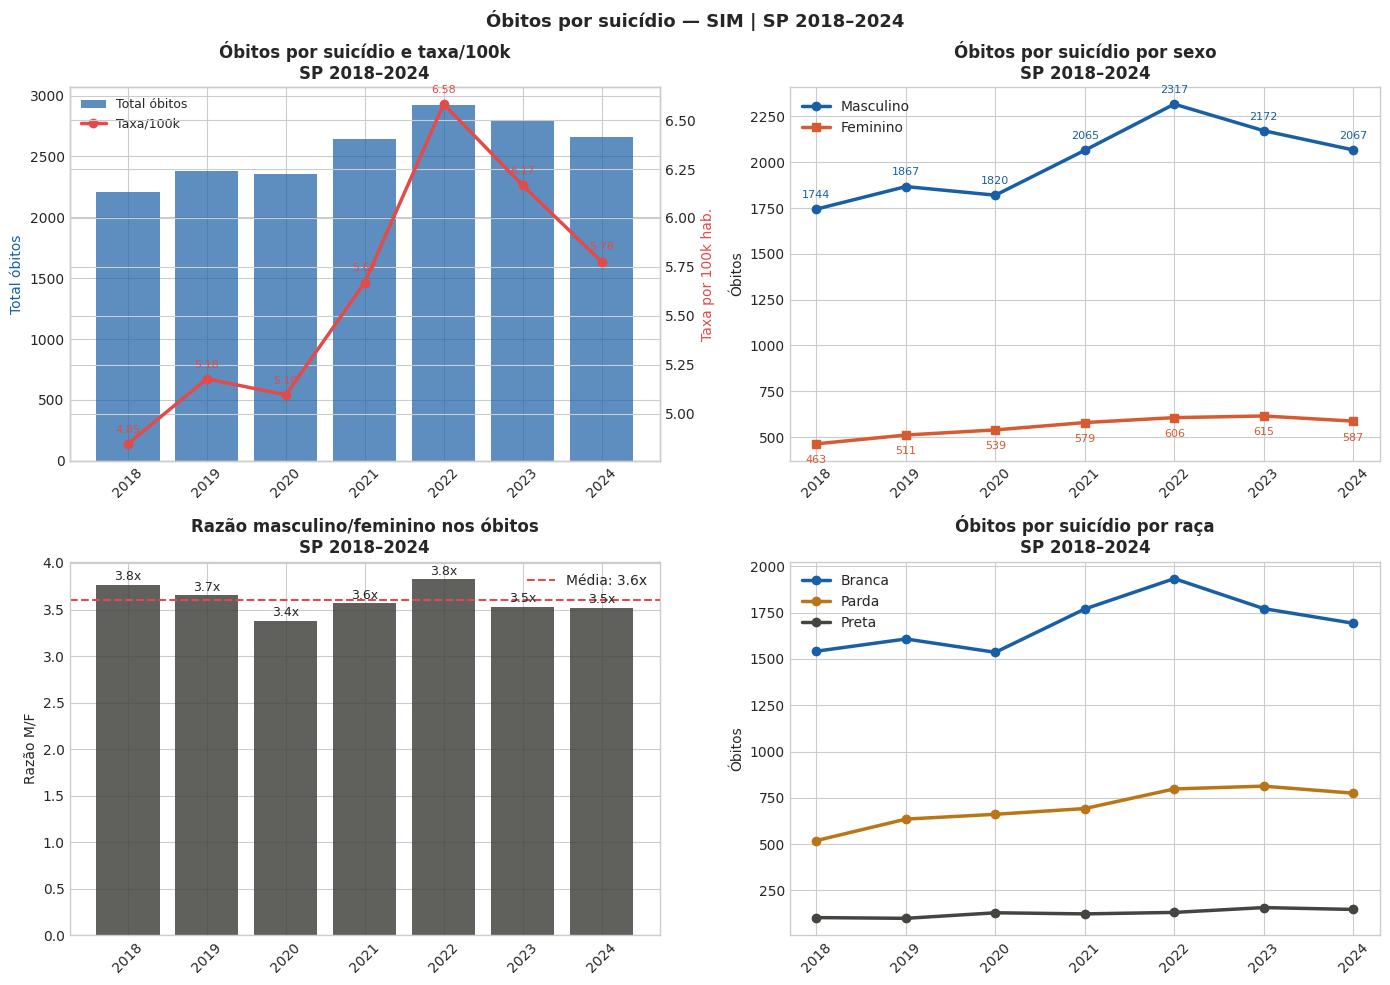

In [17]:
# ============================================================
# CÉLULA 12 — Óbitos por suicídio (SIM)
# ============================================================

# ------------------------------------------------------------
# Carregar série completa do SIM
# ------------------------------------------------------------
df_sim_full = query("""
    SELECT ano, sexo, raca_cor,
           COUNT(*) AS total_obitos
    FROM sus_pipeline.sim_suicidios
    GROUP BY ano, sexo, raca_cor
    ORDER BY ano, sexo, raca_cor
""")
df_sim_full['ano']          = df_sim_full['ano'].astype(int)
df_sim_full['total_obitos'] = pd.to_numeric(
    df_sim_full['total_obitos'], errors='coerce')
df_sim_full['sexo_label']   = df_sim_full['sexo'].map(
    {'1': 'Masculino', '2': 'Feminino'})
df_sim_full['raca']         = df_sim_full['raca_cor'].map(RACA_SINAN)

# Série anual total
df_sim_ano = (df_sim_full.groupby('ano')['total_obitos']
              .sum().reset_index())
df_sim_ano['populacao'] = df_sim_ano['ano'].map(POP_SP_ANO)
df_sim_ano['taxa_100k'] = (df_sim_ano['total_obitos'] /
                           df_sim_ano['populacao'] * 100_000)

# Série por sexo
df_sim_sexo_ano = (df_sim_full[df_sim_full['sexo_label'].notna()]
                   .groupby(['ano', 'sexo_label'])['total_obitos']
                   .sum().unstack(fill_value=0).reset_index())
df_sim_sexo_ano['total']   = (df_sim_sexo_ano['Masculino'] +
                               df_sim_sexo_ano['Feminino'])
df_sim_sexo_ano['razao_mf']= (df_sim_sexo_ano['Masculino'] /
                               df_sim_sexo_ano['Feminino'])
df_sim_sexo_ano['populacao']= df_sim_sexo_ano['ano'].map(POP_SP_ANO)
df_sim_sexo_ano['taxa_m']  = (df_sim_sexo_ano['Masculino'] /
                               df_sim_sexo_ano['populacao'] * 100_000)
df_sim_sexo_ano['taxa_f']  = (df_sim_sexo_ano['Feminino'] /
                               df_sim_sexo_ano['populacao'] * 100_000)

# Série por raça
df_sim_raca_ano = (df_sim_full[df_sim_full['raca'].isin(RACAS_ANALISE)]
                   .groupby(['ano', 'raca'])['total_obitos']
                   .sum().unstack(fill_value=0).reset_index())

print('=' * 60)
print('TESTE 12 — Óbitos por suicídio (SIM)')
print('=' * 60)
print(f'\n  Total: {df_sim_ano["total_obitos"].sum():,.0f} óbitos | '
      f'{df_sim_ano["ano"].min()}–{df_sim_ano["ano"].max()}')

# ------------------------------------------------------------
# 12a — Série anual com taxa por 100k
# ------------------------------------------------------------
print(f'\n--- 12a: Série anual ---')
print(f'  {"Ano":>6} {"Total":>8} {"Taxa/100k":>12} '
      f'{"Masc":>8} {"Fem":>8} {"Razão M/F":>12}')
print(f'  {"-"*58}')
for _, row in df_sim_sexo_ano.iterrows():
    pop  = POP_SP_ANO.get(int(row['ano']))
    taxa = row['total'] / pop * 100_000 if pop else np.nan
    print(f'  {int(row["ano"]):>6} {int(row["total"]):>8,} '
          f'{taxa:>11.2f} {int(row["Masculino"]):>8,} '
          f'{int(row["Feminino"]):>8,} {row["razao_mf"]:>11.1f}x')

# ------------------------------------------------------------
# 12b — Tendência por sexo (Spearman)
# ------------------------------------------------------------
print(f'\n--- 12b: Tendência temporal por sexo (Spearman) ---')
for sexo in ['Masculino', 'Feminino']:
    serie = df_sim_sexo_ano[['ano', sexo]].copy()
    r, p  = spearmanr(serie['ano'], serie[sexo])
    var   = (serie[sexo].iloc[-1] / serie[sexo].iloc[0] - 1) * 100
    register_p(f'T12_spearman_{sexo.lower()}', p)
    print(f'  {sexo:<12} r={r:+.3f}, p={p:.4f} {sig_label(p)} | '
          f'variação 2018–2024: {var:+.1f}%')

# Tendência da taxa total
r_tot, p_tot = spearmanr(df_sim_ano['ano'], df_sim_ano['taxa_100k'])
register_p('T12_spearman_taxa_total', p_tot)
print(f'\n  Taxa total r={r_tot:+.3f}, p={p_tot:.4f} {sig_label(p_tot)}')

# ------------------------------------------------------------
# 12c — Distribuição por raça
# ------------------------------------------------------------
print(f'\n--- 12c: Distribuição por raça ---')
raca_total = df_sim_full[df_sim_full['raca'].isin(RACAS_ANALISE)]
raca_dist  = raca_total.groupby('raca')['total_obitos'].sum()
tot_raca   = raca_dist.sum()
print(f'  {"Raça":<10} {"N":>10} {"  %":>8}')
print(f'  {"-"*30}')
for r in RACAS_ANALISE:
    n = raca_dist.get(r, 0)
    print(f'  {r:<10} {n:>10,} {n/tot_raca*100:>7.1f}%')

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Painel 1 — série anual total + taxa
ax = axes[0, 0]
ax2 = ax.twinx()
bars = ax.bar(df_sim_ano['ano'], df_sim_ano['total_obitos'],
              color='#185FA5', alpha=0.7, label='Total óbitos')
ax2.plot(df_sim_ano['ano'], df_sim_ano['taxa_100k'],
         marker='o', color='#E24B4A', linewidth=2.5,
         label='Taxa/100k')
for x, y in zip(df_sim_ano['ano'], df_sim_ano['taxa_100k']):
    ax2.annotate(f'{y:.2f}', xy=(x, y), xytext=(0, 8),
                 textcoords='offset points', ha='center',
                 fontsize=8, color='#E24B4A')
ax.set_title('Óbitos por suicídio e taxa/100k\nSP 2018–2024',
             fontweight='bold')
ax.set_ylabel('Total óbitos', color='#185FA5')
ax2.set_ylabel('Taxa por 100k hab.', color='#E24B4A')
ax.set_xticks(df_sim_ano['ano'])
ax.tick_params(axis='x', rotation=45)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, fontsize=9)

# Painel 2 — óbitos por sexo ao longo do tempo
ax = axes[0, 1]
ax.plot(df_sim_sexo_ano['ano'], df_sim_sexo_ano['Masculino'],
        marker='o', linewidth=2.5, color='#185FA5', label='Masculino')
ax.plot(df_sim_sexo_ano['ano'], df_sim_sexo_ano['Feminino'],
        marker='s', linewidth=2.5, color='#D85A30', label='Feminino')
for _, row in df_sim_sexo_ano.iterrows():
    ax.annotate(f'{int(row["Masculino"])}',
                xy=(row['ano'], row['Masculino']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='#185FA5')
    ax.annotate(f'{int(row["Feminino"])}',
                xy=(row['ano'], row['Feminino']),
                xytext=(0, -14), textcoords='offset points',
                ha='center', fontsize=8, color='#D85A30')
ax.set_title('Óbitos por suicídio por sexo\nSP 2018–2024',
             fontweight='bold')
ax.set_ylabel('Óbitos')
ax.set_xticks(df_sim_sexo_ano['ano'])
ax.tick_params(axis='x', rotation=45)
ax.legend()

# Painel 3 — razão masculino/feminino
ax = axes[1, 0]
ax.bar(df_sim_sexo_ano['ano'], df_sim_sexo_ano['razao_mf'],
       color='#444441', alpha=0.85)
ax.axhline(y=df_sim_sexo_ano['razao_mf'].mean(),
           color='#E24B4A', linewidth=1.5, linestyle='--',
           label=f'Média: {df_sim_sexo_ano["razao_mf"].mean():.1f}x')
for x, y in zip(df_sim_sexo_ano['ano'],
                df_sim_sexo_ano['razao_mf']):
    ax.text(x, y+0.05, f'{y:.1f}x', ha='center', fontsize=9)
ax.set_title('Razão masculino/feminino nos óbitos\n'
             'SP 2018–2024', fontweight='bold')
ax.set_ylabel('Razão M/F')
ax.set_xticks(df_sim_sexo_ano['ano'])
ax.tick_params(axis='x', rotation=45)
ax.legend()

# Painel 4 — óbitos por raça ao longo do tempo
ax = axes[1, 1]
cores_raca = {'Branca':'#185FA5','Parda':'#BA7517','Preta':'#444441'}
for r in RACAS_ANALISE:
    if r in df_sim_raca_ano.columns:
        ax.plot(df_sim_raca_ano['ano'], df_sim_raca_ano[r],
                marker='o', linewidth=2.5,
                color=cores_raca[r], label=r)
ax.set_title('Óbitos por suicídio por raça\nSP 2018–2024',
             fontweight='bold')
ax.set_ylabel('Óbitos')
ax.set_xticks(df_sim_raca_ano['ano'])
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.suptitle('Óbitos por suicídio — SIM | SP 2018–2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/12_suicidios_sim.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Resultados — Óbitos por suicídio (SIM)

**Tendência geral:** os óbitos por suicídio cresceram de
2.207 (2018) para 2.654 (2024), com pico em 2022 (2.923).
A taxa por 100k aumentou de 4.85 para 5.77 no período
(Spearman r = +0.821, p = 0.023). Esse crescimento ocorre
em sentido oposto à queda nas internações psiquiátricas
observada na Célula 3 — os dois fenômenos são parcialmente
independentes, pois capturam populações e gravidades
distintas.

**Por sexo:** homens respondem por 78.3% dos óbitos e
mulheres por 21.7% — padrão estável ao longo do período,
com razão M/F média de 3.6x. Tanto masculino (+18.5%)
quanto feminino (+26.8%) apresentaram crescimento
significativo entre 2018 e 2024 (Masculino: r = +0.821,
p = 0.023; Feminino: r = +0.893, p = 0.007). O crescimento
feminino é proporcionalmente maior — a razão M/F caiu de
3.8x em 2018 para 3.5x em 2024, sugerindo convergência
gradual.

**2022 — pico pandêmico tardio:** o maior número de óbitos
ocorreu em 2022 (2.923, taxa = 6.58/100k), não em 2020
ou 2021. Esse padrão é consistente com a literatura sobre
efeitos tardios de crises sanitárias na saúde mental —
o impacto psicossocial da pandemia (luto, desemprego,
isolamento) tende a se manifestar nos anos seguintes
ao pico infeccioso, não durante ele.

**Por raça:** brancos representam 67.2% dos óbitos, pardos
27.7% e pretos 5.0%. Em conjunto com os dados da Célula 11,
o padrão racial é consistente: pretos e pardos têm excesso
relativo nas tentativas e déficit nos óbitos — sugerindo
diferenças nos métodos utilizados ou na sobrevivência
após a tentativa.

**Internações vs suicídios — divergência de tendências:**
enquanto as internações caíram de 306/100k (2015) para
~210/100k (2025), os óbitos por suicídio cresceram de
4.85/100k (2018) para 5.77/100k (2024). Essa divergência
não implica causalidade — mas levanta a hipótese de que
parte da redução nas internações pode refletir barreiras
de acesso ao cuidado, não apenas desinstitucionalização
efetiva.

> **Limitações:** o SIM cobre 2018–2024, período mais
> curto que o SIH. A série de 7 pontos tem poder
> estatístico limitado para inferência formal de tendência.
> Subnotificação de suicídios é documentada no Brasil,
> com estimativas de 10–30% de subregistro por
> classificação incorreta da causa mortis.

## Célula 13 — Atendimentos nos CAPS (RAAS)

### Pergunta
Os atendimentos nos CAPS cresceram ao longo do período?
Há relação ecológica entre cobertura de CAPS e taxa de
internação psiquiátrica nos municípios?

### Fonte e cobertura

RAAS — Registro das Ações Ambulatoriais de Saúde.
Período: 2018–2025 (excluído 2017 por inconsistência).
Total: 9.052.246 atendimentos registrados.

### Limitações metodológicas

**RAAS não é equivalente a pacientes únicos:** um mesmo
paciente pode gerar múltiplos registros por ano. O total
de atendimentos reflete volume de produção, não número
de pessoas atendidas.

**Correlação CAPS × internação é ecológica:** a unidade
de análise é o município. A falácia ecológica impede
inferência individual — um município com mais CAPS ter
menos internações não significa que pacientes atendidos
em CAPS internam menos.

**Cobertura CAPS × internação:** testamos a correlação
entre a densidade de CAPS por 100k hab. e a taxa de
internação municipal — análise já conduzida na Célula 14
(análise municipal). Aqui o foco é na série temporal
estadual e no perfil dos atendimentos.

TESTE 13 — Atendimentos nos CAPS (RAAS)

  Total 2018–2025: 9,052,246 atendimentos

--- 13a: Série anual ---
     Ano          Total    Taxa/100k   % Masc    % Fem    % Rua   % Drogas
  ----------------------------------------------------------------------
    2018        912,780      2004.4    58.9%    41.1%     2.2%      28.4%
    2019      1,045,318      2276.4    58.0%    42.0%     2.4%      29.3%
    2020        933,050      2015.7    56.2%    43.8%     2.5%      27.2%
    2021      1,060,668      2273.7    54.9%    45.1%     2.2%      25.5%
    2022      1,085,666      2444.6    54.5%    45.5%     2.3%      23.1%
    2023      1,262,615      2793.9    54.6%    45.4%     2.3%      21.9%
    2024      1,325,256      2882.7    54.6%    45.4%     2.5%      20.4%
    2025      1,426,893      3088.3    54.5%    45.5%     1.4%      15.1%

--- 13b: Tendência temporal (Spearman) ---
  Total atendimentos : r=+0.976, p=0.0000 ***
  % situação de rua  : r=-0.214, p=0.6103 ns
  % uso de droga

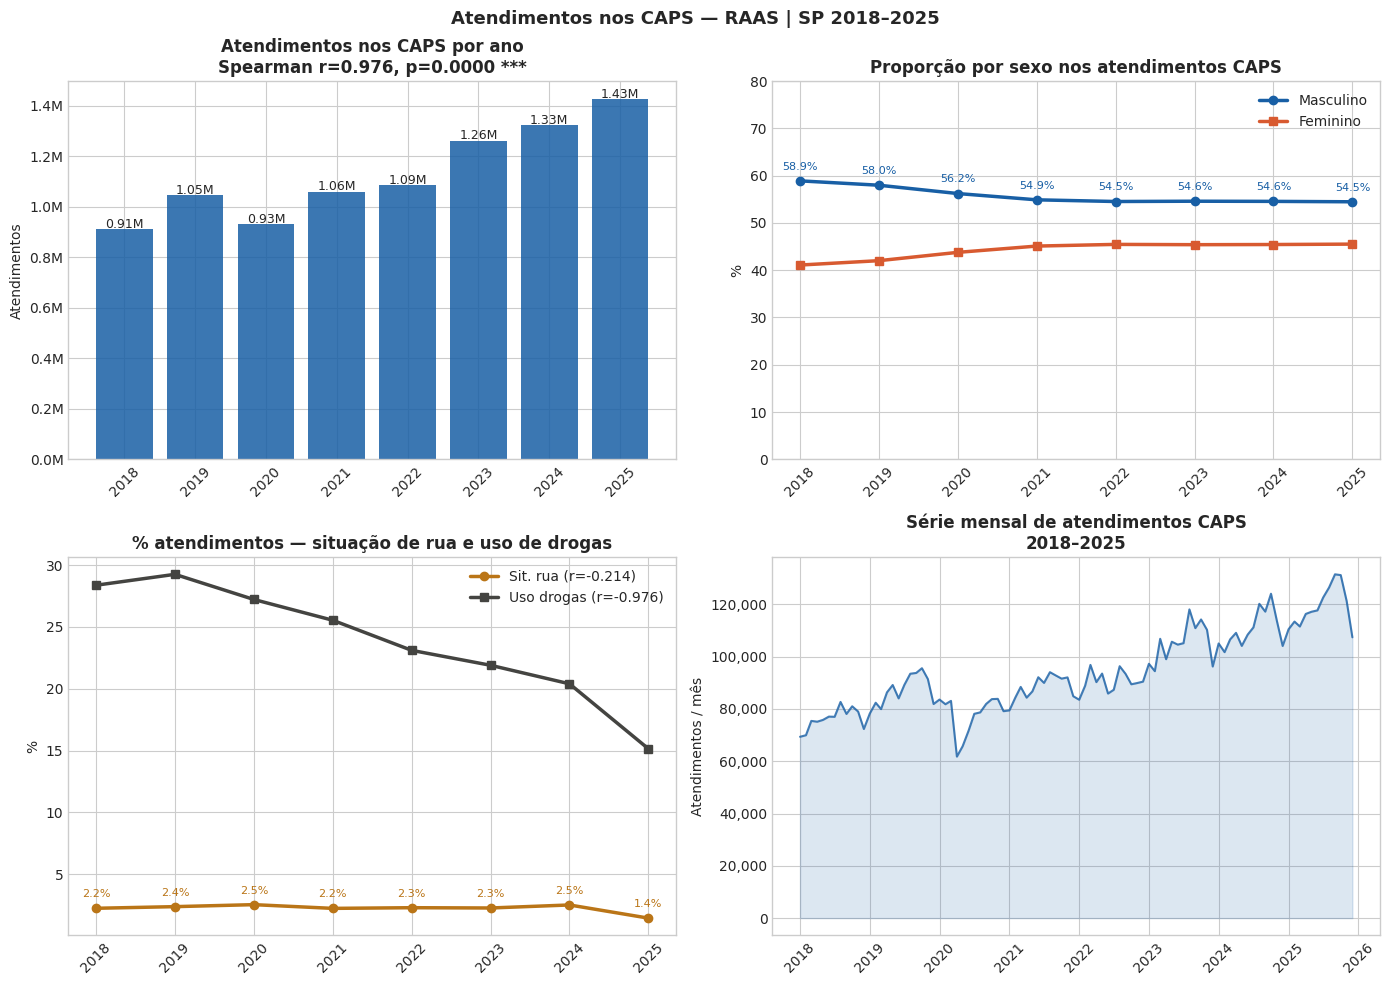

In [20]:
# ============================================================
# CÉLULA 13 — Atendimentos nos CAPS (RAAS)
# ============================================================

# ------------------------------------------------------------
# Série anual já carregada na Célula 1 (df_raas)
# Carregar também série mensal para tendência
# ------------------------------------------------------------
df_raas_mensal = query("""
SELECT ano, mes,
       SUM(qtd_atendimentos) AS total,
       SUM(CASE WHEN sexo = 'M'
           THEN qtd_atendimentos ELSE 0 END) AS masculino,
       SUM(CASE WHEN sexo = 'F'
           THEN qtd_atendimentos ELSE 0 END) AS feminino,
       SUM(CASE WHEN TRIM(situacao_rua) = 'S'
           THEN qtd_atendimentos ELSE 0 END) AS situacao_rua,
       SUM(CASE WHEN TRIM(tipo_droga) != ''
           THEN qtd_atendimentos ELSE 0 END) AS uso_drogas
FROM sus_pipeline.raas_atendimentos
WHERE ano NOT IN ('2017', '2026')
GROUP BY ano, mes
ORDER BY ano, mes
""")
df_raas_mensal['ano'] = df_raas_mensal['ano'].astype(int)
df_raas_mensal['mes'] = pd.to_numeric(df_raas_mensal['mes'], errors='coerce')
for col in ['total','masculino','feminino','situacao_rua','uso_drogas']:
    df_raas_mensal[col] = pd.to_numeric(df_raas_mensal[col], errors='coerce')

df_raas_mensal['data'] = pd.to_datetime(
    df_raas_mensal['ano'].astype(str) + '-' +
    df_raas_mensal['mes'].astype(str).str.zfill(2) + '-01'
)
df_raas_mensal = df_raas_mensal.sort_values('data').reset_index(drop=True)

# ------------------------------------------------------------
# Métricas anuais derivadas
# ------------------------------------------------------------
df_raas['populacao'] = df_raas['ano'].map(POP_SP_ANO)
df_raas['taxa_100k'] = (df_raas['total_atendimentos'] /
                        df_raas['populacao'] * 100_000)
df_raas['pct_masc']  = df_raas['masculino'] / df_raas['total_atendimentos'] * 100
df_raas['pct_fem']   = df_raas['feminino']  / df_raas['total_atendimentos'] * 100
df_raas['pct_rua']   = df_raas['situacao_rua'] / df_raas['total_atendimentos'] * 100
df_raas['pct_drogas']= df_raas['uso_drogas'] / df_raas['total_atendimentos'] * 100

print('=' * 60)
print('TESTE 13 — Atendimentos nos CAPS (RAAS)')
print('=' * 60)
print(f'\n  Total 2018–2025: {df_raas["total_atendimentos"].sum():,.0f} atendimentos')

# ------------------------------------------------------------
# 13a — Série anual
# ------------------------------------------------------------
print(f'\n--- 13a: Série anual ---')
print(f'  {"Ano":>6} {"Total":>14} {"Taxa/100k":>12} '
      f'{"% Masc":>8} {"% Fem":>8} {"% Rua":>8} {"% Drogas":>10}')
print(f'  {"-"*70}')
for _, row in df_raas.iterrows():
    print(f'  {int(row["ano"]):>6} '
          f'{int(row["total_atendimentos"]):>14,} '
          f'{row["taxa_100k"]:>11.1f} '
          f'{row["pct_masc"]:>7.1f}% '
          f'{row["pct_fem"]:>7.1f}% '
          f'{row["pct_rua"]:>7.1f}% '
          f'{row["pct_drogas"]:>9.1f}%')

# ------------------------------------------------------------
# 13b — Tendência (Spearman)
# ------------------------------------------------------------
print(f'\n--- 13b: Tendência temporal (Spearman) ---')
r_tot, p_tot = spearmanr(df_raas['ano'], df_raas['total_atendimentos'])
r_rua, p_rua = spearmanr(df_raas['ano'], df_raas['pct_rua'])
r_dro, p_dro = spearmanr(df_raas['ano'], df_raas['pct_drogas'])
register_p('T13_spearman_total',  p_tot)
register_p('T13_spearman_rua',    p_rua)
register_p('T13_spearman_drogas', p_dro)

print(f'  Total atendimentos : r={r_tot:+.3f}, p={p_tot:.4f} {sig_label(p_tot)}')
print(f'  % situação de rua  : r={r_rua:+.3f}, p={p_rua:.4f} {sig_label(p_rua)}')
print(f'  % uso de drogas    : r={r_dro:+.3f}, p={p_dro:.4f} {sig_label(p_dro)}')

var_total = (df_raas['total_atendimentos'].iloc[-1] /
             df_raas['total_atendimentos'].iloc[0] - 1) * 100
print(f'\n  Variação 2018→2025: {var_total:+.1f}%')

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Painel 1 — série anual de atendimentos
ax = axes[0, 0]
ax.bar(df_raas['ano'], df_raas['total_atendimentos'],
       color='#185FA5', alpha=0.85)
for _, row in df_raas.iterrows():
    ax.text(row['ano'], row['total_atendimentos'] + 5000,
            f'{row["total_atendimentos"]/1e6:.2f}M',
            ha='center', fontsize=9)
ax.set_title(f'Atendimentos nos CAPS por ano\n'
             f'Spearman r={r_tot:.3f}, p={p_tot:.4f} {sig_label(p_tot)}',
             fontweight='bold')
ax.set_ylabel('Atendimentos')
ax.set_xticks(df_raas['ano'])
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Painel 2 — proporção por sexo
ax = axes[0, 1]
ax.plot(df_raas['ano'], df_raas['pct_masc'],
        marker='o', linewidth=2.5, color='#185FA5', label='Masculino')
ax.plot(df_raas['ano'], df_raas['pct_fem'],
        marker='s', linewidth=2.5, color='#D85A30', label='Feminino')
for _, row in df_raas.iterrows():
    ax.annotate(f'{row["pct_masc"]:.1f}%',
                xy=(row['ano'], row['pct_masc']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='#185FA5')
ax.set_title('Proporção por sexo nos atendimentos CAPS',
             fontweight='bold')
ax.set_ylabel('%')
ax.set_xticks(df_raas['ano'])
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.set_ylim(0, 80)

# Painel 3 — % situação de rua e % uso de drogas
ax = axes[1, 0]
ax.plot(df_raas['ano'], df_raas['pct_rua'],
        marker='o', linewidth=2.5, color='#BA7517',
        label=f'Sit. rua (r={r_rua:.3f})')
ax.plot(df_raas['ano'], df_raas['pct_drogas'],
        marker='s', linewidth=2.5, color='#444441',
        label=f'Uso drogas (r={r_dro:.3f})')
for _, row in df_raas.iterrows():
    ax.annotate(f'{row["pct_rua"]:.1f}%',
                xy=(row['ano'], row['pct_rua']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='#BA7517')
ax.set_title('% atendimentos — situação de rua e uso de drogas',
             fontweight='bold')
ax.set_ylabel('%')
ax.set_xticks(df_raas['ano'])
ax.tick_params(axis='x', rotation=45)
ax.legend()

# Painel 4 — série mensal
ax = axes[1, 1]
ax.plot(df_raas_mensal['data'], df_raas_mensal['total'],
        color='#185FA5', linewidth=1.5, alpha=0.8)
ax.fill_between(df_raas_mensal['data'],
                df_raas_mensal['total'],
                alpha=0.15, color='#185FA5')
ax.set_title('Série mensal de atendimentos CAPS\n2018–2025',
             fontweight='bold')
ax.set_ylabel('Atendimentos / mês')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)

plt.suptitle('Atendimentos nos CAPS — RAAS | SP 2018–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/13_caps_raas.png', dpi=150, bbox_inches='tight')
plt.show()

### Resultados — Atendimentos nos CAPS (RAAS)

**Volume e tendência:** os atendimentos nos CAPS cresceram
56.3% entre 2018 e 2025 — de 912.780 para 1.426.893 anuais
(Spearman r = +0.976, p < 0.001). A taxa por 100k habitantes
aumentou de 2.004 para 3.088, indicando expansão real da
cobertura além do crescimento populacional. A queda em 2020
(933.050) reflete a redução de atendimentos presenciais
durante a pandemia, com recuperação completa em 2021.

**Proporção por sexo:** homens representavam 58.9% dos
atendimentos em 2018 e 54.5% em 2025 — queda consistente
de 4.4pp ao longo do período. A proporção feminina cresceu
de 41.1% para 45.5%, tendência oposta à observada nas
internações, onde a proporção feminina cresceu apenas 1.3pp
no mesmo período. Isso sugere que os CAPS têm absorvido
progressivamente mais mulheres em relação ao perfil
histórico do serviço.

**Uso de drogas:** a proporção de atendimentos relacionados
a uso de substâncias caiu de 28.4% (2018) para 15.1% (2025)
(Spearman r = −0.976, p < 0.001). Essa queda expressiva
pode refletir mudança na composição dos encaminhamentos —
com maior absorção de transtornos de humor e psicoses —
ou mudança no critério de registro da variável `tipo_droga`
ao longo do tempo. Ambas as hipóteses precisam ser
investigadas antes de interpretação substantiva.

**Situação de rua:** estável em torno de 2.2–2.5% ao
longo do período, sem tendência significativa
(r = −0.214, p = 0.610). A queda para 1.4% em 2025 é
possivelmente um artefato de registro incompleto no
ano mais recente.

**Série mensal:** o crescimento é consistente e sem
reversões após 2021, com aceleração visível a partir
de 2023. A variabilidade mensal aumentou nos últimos
anos, sugerindo maior sazonalidade ou instabilidade
na oferta de serviços.

> **Limitação:** atendimentos não equivalem a pacientes
> únicos — um mesmo paciente gera múltiplos registros.
> O crescimento no volume de atendimentos pode refletir
> tanto aumento no número de pessoas atendidas quanto
> aumento na frequência de atendimento por paciente.
> Sem identificador único de paciente nos dados públicos,
> não é possível distinguir as duas hipóteses.

## Célula 14 — Análise municipal e mapas

### Escopo e limitações metodológicas

Esta célula conduz análise exploratória em nível municipal —
a unidade de análise é o município, não o indivíduo.
Correlações ecológicas não podem ser interpretadas como
correlações individuais (falácia ecológica).

A análise formal de correlação é restrita ao par
**Favela × Suicídio**, único achado que sobreviveu à
correção de Bonferroni local na análise exploratória.
Os demais pares (CAPS × internação, CAPS × suicídio,
Internação × suicídio) são apresentados apenas nos
mapas como visualização exploratória.

### Autocorrelação espacial

Dados municipais têm autocorrelação espacial —
municípios vizinhos tendem a ter valores similares.
Isso viola a independência das observações e pode
distorcer correlações de Spearman. O teste formal
(índice de Moran) requer shapefile e PySAL, fora do
escopo deste notebook. Todas as correlações ecológicas
são reportadas com essa ressalva.

### Mapas

Três mapas coropléticos interativos (Folium) são gerados
como material suplementar: taxa de internação, taxa de
suicídio e densidade de CAPS por município.

TESTE 14 — Análise municipal

  Municípios analisados: 246

  Variável                          Mediana      P25      P75
  ----------------------------------------------------------
  Taxa internação/100k                 58.5     13.3    160.1
  Taxa suicídio/100k                    8.2      5.2     11.4
  CAPS/100k                             3.7      2.1      5.9
  % domicílios favela                   0.0      0.0      0.2

--- Correlação focal: Favela % × Suicídio/100k ---
  N municípios: 246
  Spearman r = -0.241, p = 0.0001 ***

  Top 10 municípios por % domicílios em favela:
  Município                   % Favela   Suicídio/100k   Internação/100k
  ----------------------------------------------------------------------
  Guarujá                        12.0%            7.5              0.3
  Cubatão                        11.5%            7.0             36.0
  Mauá                            9.6%            4.7            105.9
  São Vicente                     8.8%            7

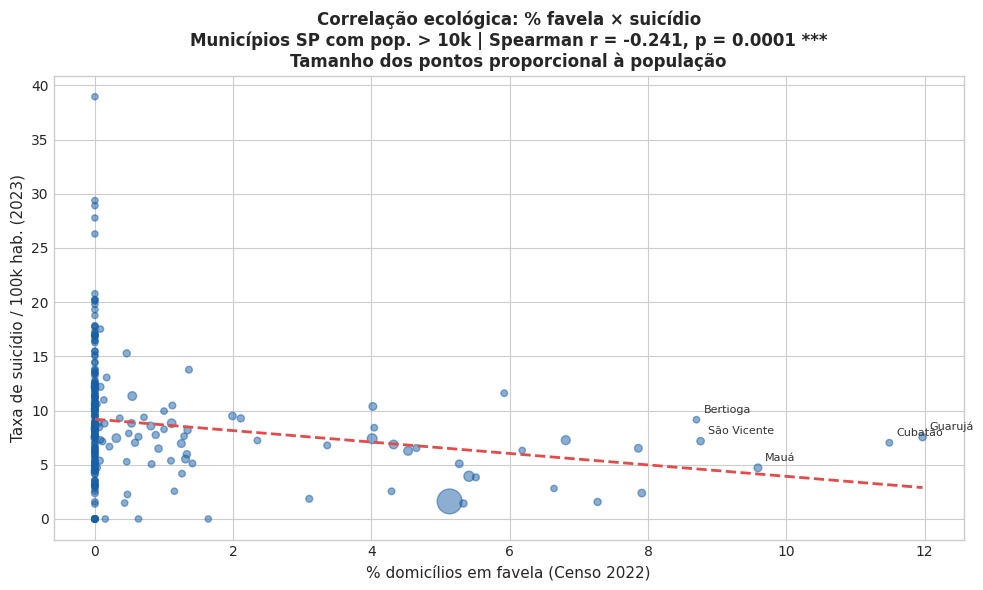


Baixando malha municipal SP...
✅ 645 municípios carregados
✅ 246 municípios mapeados
✅ mapa_01_internacao.html
✅ mapa_02_suicidio.html
✅ mapa_03_caps.html

✅ Mapas salvos em output/. Abrir no browser para visualização.


In [21]:
# ============================================================
# CÉLULA 14 — Análise municipal e mapas
# ============================================================
import folium
import requests

# ------------------------------------------------------------
# Carregar dados municipais
# ------------------------------------------------------------
df_mun = query("""
    SELECT cod_municipio, municipio,
           taxa_internacao_100k,
           taxa_suicidio_100k,
           total_caps,
           populacao_total,
           total_internacoes,
           pct_domicilios_favelas
    FROM sus_pipeline.saude_mental_municipios
    WHERE ano = '2023'
      AND populacao_total > 10000
      AND municipio IS NOT NULL
""")

for col in ['taxa_internacao_100k', 'taxa_suicidio_100k',
            'total_caps', 'populacao_total',
            'total_internacoes', 'pct_domicilios_favelas']:
    df_mun[col] = pd.to_numeric(df_mun[col], errors='coerce')

# Remover outliers extremos de taxa de internação
df_mun = df_mun[df_mun['taxa_internacao_100k'] < 1000].copy()
df_mun['caps_100k'] = (df_mun['total_caps'] /
                        df_mun['populacao_total'] * 100_000)

print('=' * 60)
print('TESTE 14 — Análise municipal')
print('=' * 60)
print(f'\n  Municípios analisados: {len(df_mun)}')

# ------------------------------------------------------------
# Estatísticas descritivas
# ------------------------------------------------------------
print(f'\n  {"Variável":<30} {"Mediana":>10} {"P25":>8} {"P75":>8}')
print(f'  {"-"*58}')
for col, label in [
    ('taxa_internacao_100k', 'Taxa internação/100k'),
    ('taxa_suicidio_100k',   'Taxa suicídio/100k'),
    ('caps_100k',            'CAPS/100k'),
    ('pct_domicilios_favelas','% domicílios favela'),
]:
    d = df_mun[col].dropna()
    print(f'  {label:<30} {d.median():>10.1f} '
          f'{d.quantile(0.25):>8.1f} {d.quantile(0.75):>8.1f}')

# ------------------------------------------------------------
# Correlação focal: Favela × Suicídio
# ------------------------------------------------------------
dados_fav = df_mun[['pct_domicilios_favelas',
                     'taxa_suicidio_100k']].dropna()
r_fav, p_fav = spearmanr(dados_fav['pct_domicilios_favelas'],
                          dados_fav['taxa_suicidio_100k'])
register_p('T14_favela_suicidio', p_fav)

print(f'\n--- Correlação focal: Favela % × Suicídio/100k ---')
print(f'  N municípios: {len(dados_fav)}')
print(f'  Spearman r = {r_fav:.3f}, p = {p_fav:.4f} {sig_label(p_fav)}')

# Contexto: top 10 municípios com maior % favela
print(f'\n  Top 10 municípios por % domicílios em favela:')
top_fav = (df_mun[['municipio','pct_domicilios_favelas',
                   'taxa_suicidio_100k','taxa_internacao_100k']]
           .dropna()
           .sort_values('pct_domicilios_favelas', ascending=False)
           .head(10))
print(f'  {"Município":<25} {"% Favela":>10} '
      f'{"Suicídio/100k":>15} {"Internação/100k":>17}')
print(f'  {"-"*70}')
for _, row in top_fav.iterrows():
    print(f'  {row["municipio"]:<25} '
          f'{row["pct_domicilios_favelas"]:>9.1f}% '
          f'{row["taxa_suicidio_100k"]:>14.1f} '
          f'{row["taxa_internacao_100k"]:>16.1f}')

# ------------------------------------------------------------
# Visualização — scatter Favela × Suicídio
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

dados_plot = df_mun[['pct_domicilios_favelas',
                      'taxa_suicidio_100k',
                      'populacao_total',
                      'municipio']].dropna()

# Tamanho dos pontos proporcional à população
tamanho = (dados_plot['populacao_total'] /
           dados_plot['populacao_total'].max() * 300 + 20)

scatter = ax.scatter(
    dados_plot['pct_domicilios_favelas'],
    dados_plot['taxa_suicidio_100k'],
    s=tamanho, alpha=0.5, color='#185FA5'
)

# Linha de tendência
z = np.polyfit(dados_plot['pct_domicilios_favelas'],
               dados_plot['taxa_suicidio_100k'], 1)
x_line = np.linspace(dados_plot['pct_domicilios_favelas'].min(),
                     dados_plot['pct_domicilios_favelas'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line),
        '--', color='#E24B4A', linewidth=2)

# Anotar municípios com maior % favela
for _, row in top_fav.head(5).iterrows():
    ax.annotate(
        row['municipio'].split('(')[0].strip(),
        xy=(row['pct_domicilios_favelas'], row['taxa_suicidio_100k']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=8, color='#333'
    )

ax.set_xlabel('% domicílios em favela (Censo 2022)', fontsize=11)
ax.set_ylabel('Taxa de suicídio / 100k hab. (2023)', fontsize=11)
ax.set_title(f'Correlação ecológica: % favela × suicídio\n'
             f'Municípios SP com pop. > 10k | '
             f'Spearman r = {r_fav:.3f}, p = {p_fav:.4f} {sig_label(p_fav)}\n'
             f'Tamanho dos pontos proporcional à população',
             fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT}/14_favela_suicidio.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# Mapas Folium
# ------------------------------------------------------------
print('\nBaixando malha municipal SP...')
url = ("https://raw.githubusercontent.com/tbrugz/geodata-br"
       "/master/geojson/geojs-35-mun.json")
try:
    resp       = requests.get(url, timeout=30)
    geojson_sp = resp.json()
    print(f'✅ {len(geojson_sp["features"])} municípios carregados')

    # Mapeamento código 6 → 7 dígitos
    cod_map_7 = {}
    for feat in geojson_sp['features']:
        cod7 = feat['properties']['id']
        cod6 = cod7[:6]
        cod_map_7[cod6] = cod7

    df_mun['cod_municipio_7'] = (df_mun['cod_municipio']
                                 .astype(str).map(cod_map_7))
    n_map = df_mun['cod_municipio_7'].notna().sum()
    print(f'✅ {n_map} municípios mapeados')

    def fazer_mapa(coluna, legenda, palette, bins, nome):
        m = folium.Map(location=[-22.5, -48.5], zoom_start=7,
                       tiles='CartoDB positron')
        folium.Choropleth(
            geo_data=geojson_sp,
            data=df_mun.dropna(subset=['cod_municipio_7', coluna]),
            columns=['cod_municipio_7', coluna],
            key_on='feature.properties.id',
            fill_color=palette,
            fill_opacity=0.75,
            line_opacity=0.3,
            legend_name=legenda,
            nan_fill_color='#e8e8e8',
            bins=bins
        ).add_to(m)
        folium.GeoJson(
            geojson_sp,
            style_function=lambda x: {'fillOpacity': 0, 'weight': 0},
            tooltip=folium.GeoJsonTooltip(
                fields=['name'], aliases=['Município:']
            )
        ).add_to(m)
        caminho = f'{OUTPUT}/{nome}'
        m.save(caminho)
        print(f'✅ {nome}')
        return m

    fazer_mapa('taxa_internacao_100k',
               'Taxa de internação psiquiátrica / 100k (2023)',
               'YlOrRd', 6, 'mapa_01_internacao.html')
    fazer_mapa('taxa_suicidio_100k',
               'Taxa de suicídio / 100k (2023)',
               'PuRd', 6, 'mapa_02_suicidio.html')
    fazer_mapa('caps_100k',
               'CAPS por 100k hab. (2023)',
               'YlGn', [0, 0.5, 1, 2, 5, 10, 50],
               'mapa_03_caps.html')

    print('\n✅ Mapas salvos em output/. Abrir no browser para visualização.')

except Exception as e:
    print(f'⚠ Erro ao baixar malha municipal: {e}')
    print('  Mapas não gerados — verificar conexão com GitHub.')

### Resultados — Análise municipal

**Heterogeneidade entre municípios:** a taxa de internação
varia amplamente entre municípios — IQR de 13 a 160/100k,
com mediana de 58.5/100k. A taxa de suicídio é menos
dispersa (mediana 8.2/100k, IQR 5.2–11.4).

**Correlação focal — Favela × Suicídio:**
municípios com maior proporção de domicílios em favela
têm menor taxa de suicídio (Spearman r = −0.241,
p < 0.001, n = 246). O achado é contraintuitivo e
requer interpretação cuidadosa.

Três hipóteses não excludentes:

1. **Subnotificação diferencial:** municípios com maior
   concentração de favelas podem ter sistemas de registro
   de óbitos menos completos, com maior proporção de
   mortes classificadas como causas externas inespecíficas
   — encobertando suicídios.

2. **Integração social (Durkheim):** comunidades com
   laços sociais densos — característica frequente em
   favelas — têm menor taxa de suicídio independentemente
   da condição socioeconômica, conforme previsto pela
   teoria clássica do suicídio anômico.

3. **Perfil demográfico:** municípios com alta proporção
   de favelas tendem a ser mais jovens e urbanos —
   perfil com menor taxa de suicídio do que municípios
   rurais envelhecidos, onde a correlação inversa pode
   estar sendo capturada.

O top 10 de municípios por % favela reforça a hipótese
demográfica — são municípios da Grande São Paulo e
Baixada Santista com população jovem e urbana, taxas
de suicídio abaixo da mediana estadual (8.2/100k) e
grande variação nas taxas de internação.

> **Limitações críticas:** todas as correlações são
> ecológicas — a falácia ecológica impede qualquer
> inferência sobre comportamento individual. A
> autocorrelação espacial entre municípios vizinhos
> não foi formalmente testada (requer PySAL + shapefile
> do IBGE) e deve ser considerada limitação adicional.
> Os mapas interativos (.html) estão disponíveis como
> material suplementar.

## Célula 15 — Correção FDR: tabela suplementar

### Método

Aplicamos o controle da Taxa de Falsas Descobertas (FDR)
pelo método de Benjamini-Hochberg (1995) sobre todos os
p-valores registrados ao longo do notebook.

O FDR controla a proporção esperada de falsas descobertas
entre os resultados declarados significativos — menos
conservador que Bonferroni, mais adequado para estudos
exploratórios com múltiplos desfechos.

Um q-valor < 0.05 significa que, entre todos os testes
declarados significativos, esperamos que menos de 5%
sejam falsas descobertas.

### Interpretação

Testes que perdem significância após correção FDR devem
ser tratados como resultados exploratórios — hipóteses
a serem confirmadas em estudos independentes, não
conclusões.

TABELA SUPLEMENTAR — Correção FDR (Benjamini-Hochberg)

  Total de testes registrados  : 77
  Significativos antes (p<0.05): 66
  Significativos após FDR      : 66
  Testes que mudaram de status : 0

✅ Nenhum teste perdeu significância após correção FDR.

     # Teste                                            p bruto    q (FDR)  Sig.raw  Sig.FDR
  ----------------------------------------------------------------------------------------
     1 T5_ztest_proporcao_sexo                           0.0000     0.0000        ✓        ✓
     2 T5_chi2_diagnostico_sexo                          0.0000     0.0000        ✓        ✓
     3 T5_OR_Múltiplas drogas                            0.0000     0.0000        ✓        ✓
     4 T5_OR_Dependência álcool                          0.0000     0.0000        ✓        ✓
     5 T5_OR_Demência NE                                 0.0000     0.0000        ✓        ✓
     6 T5_OR_Depressão grave                             0.0000     0.0000        ✓        ✓
  

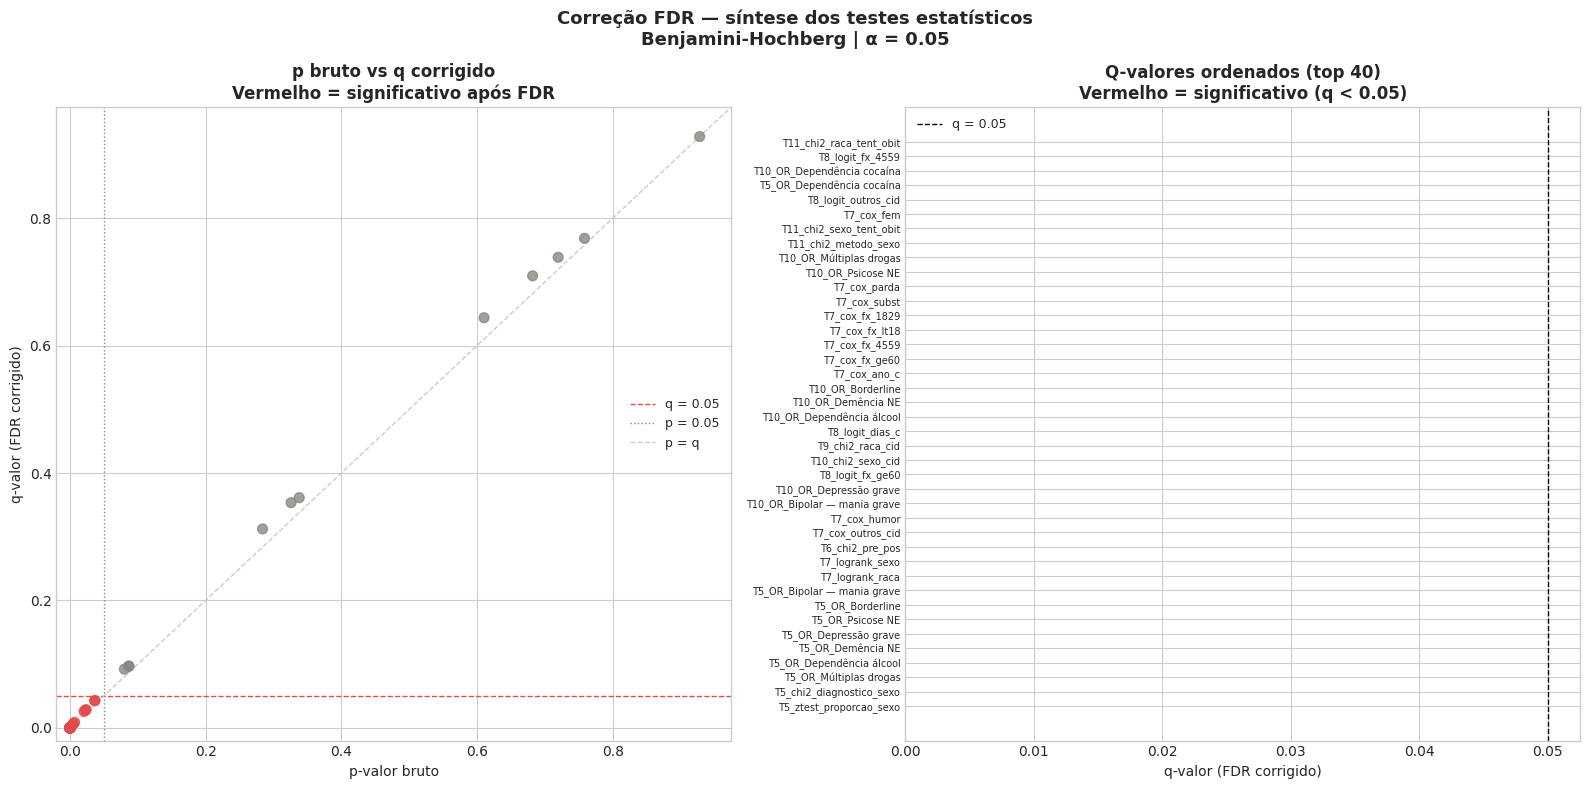


✅ Tabela suplementar salva em output/tabela_suplementar_FDR.csv


In [22]:
# ============================================================
# CÉLULA 15 — Correção FDR (Benjamini-Hochberg)
# ============================================================

# ------------------------------------------------------------
# Remover duplicatas de p-valores (células re-executadas)
# ------------------------------------------------------------
df_fdr = pd.DataFrame(_pvalues_registry)
df_fdr = df_fdr.drop_duplicates(subset='teste', keep='last').reset_index(drop=True)

# Remover p-valores NaN ou inválidos
df_fdr = df_fdr[df_fdr['p_raw'].notna()].copy()
df_fdr = df_fdr[df_fdr['p_raw'] <= 1.0].copy()

# ------------------------------------------------------------
# Aplicar correção FDR
# ------------------------------------------------------------
reject, p_corr, _, _ = multipletests(
    df_fdr['p_raw'].values,
    alpha=0.05,
    method='fdr_bh'
)
df_fdr['p_corrigido']        = p_corr
df_fdr['significativo_raw']  = df_fdr['p_raw'] < 0.05
df_fdr['significativo_fdr']  = reject
df_fdr['mudou']              = (df_fdr['significativo_raw'] !=
                                df_fdr['significativo_fdr'])

# ------------------------------------------------------------
# Sumário
# ------------------------------------------------------------
print('=' * 65)
print('TABELA SUPLEMENTAR — Correção FDR (Benjamini-Hochberg)')
print('=' * 65)
print(f'\n  Total de testes registrados  : {len(df_fdr)}')
print(f'  Significativos antes (p<0.05): {df_fdr["significativo_raw"].sum()}')
print(f'  Significativos após FDR      : {df_fdr["significativo_fdr"].sum()}')
print(f'  Testes que mudaram de status : {df_fdr["mudou"].sum()}')

# ------------------------------------------------------------
# Testes que perderam significância
# ------------------------------------------------------------
perderam = df_fdr[df_fdr['mudou'] & ~df_fdr['significativo_fdr']]
ganharam = df_fdr[df_fdr['mudou'] &  df_fdr['significativo_fdr']]

if len(perderam) > 0:
    print(f'\n⚠ Testes que perderam significância após FDR:')
    for _, row in perderam.iterrows():
        print(f'  • {row["teste"]:<45} '
              f'p={row["p_raw"]:.4f} → q={row["p_corrigido"]:.4f}')
else:
    print(f'\n✅ Nenhum teste perdeu significância após correção FDR.')

# ------------------------------------------------------------
# Tabela completa ordenada por q-valor
# ------------------------------------------------------------
df_fdr_sorted = df_fdr.sort_values('p_corrigido').reset_index(drop=True)

print(f'\n  {"#":>4} {"Teste":<45} {"p bruto":>10} '
      f'{"q (FDR)":>10} {"Sig.raw":>8} {"Sig.FDR":>8}')
print(f'  {"-"*88}')
for i, row in df_fdr_sorted.iterrows():
    sig_r = '✓' if row['significativo_raw'] else '✗'
    sig_f = '✓' if row['significativo_fdr'] else '✗'
    mud   = ' ⚠' if row['mudou'] else ''
    print(f'  {i+1:>4} {row["teste"]:<45} '
          f'{row["p_raw"]:>10.4f} '
          f'{row["p_corrigido"]:>10.4f} '
          f'{sig_r:>8} {sig_f:>8}{mud}')

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Painel 1 — p bruto vs q corrigido
ax = axes[0]
cores_pts = ['#E24B4A' if s else '#888780'
             for s in df_fdr['significativo_fdr']]
ax.scatter(df_fdr['p_raw'], df_fdr['p_corrigido'],
           color=cores_pts, s=50, alpha=0.8, zorder=5)
ax.axhline(y=0.05, color='#E24B4A', linewidth=1,
           linestyle='--', label='q = 0.05')
ax.axvline(x=0.05, color='#888780', linewidth=1,
           linestyle=':', label='p = 0.05')
lim = max(df_fdr['p_raw'].max(),
          df_fdr['p_corrigido'].max()) * 1.05
ax.plot([0, lim], [0, lim], '--', color='#ccc',
        linewidth=1, label='p = q')
ax.set_xlabel('p-valor bruto')
ax.set_ylabel('q-valor (FDR corrigido)')
ax.set_title('p bruto vs q corrigido\nVermelho = significativo após FDR',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-0.02, lim)
ax.set_ylim(-0.02, lim)

# Painel 2 — q-valores ordenados (top 40)
ax = axes[1]
df_plot = df_fdr_sorted.head(40)
cores_bar = ['#E24B4A' if s else '#888780'
             for s in df_plot['significativo_fdr']]
ax.barh(range(len(df_plot)), df_plot['p_corrigido'],
        color=cores_bar, alpha=0.85)
ax.axvline(x=0.05, color='black', linewidth=1,
           linestyle='--', label='q = 0.05')
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot['teste'], fontsize=7)
ax.set_xlabel('q-valor (FDR corrigido)')
ax.set_title('Q-valores ordenados (top 40)\n'
             'Vermelho = significativo (q < 0.05)',
             fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Correção FDR — síntese dos testes estatísticos\n'
             'Benjamini-Hochberg | α = 0.05',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/15_FDR.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# Salvar tabela suplementar em CSV
# ------------------------------------------------------------
df_fdr_sorted.to_csv(f'{OUTPUT}/tabela_suplementar_FDR.csv',
                     index=False)
print(f'\n✅ Tabela suplementar salva em output/tabela_suplementar_FDR.csv')

### Resultados — Correção FDR

Foram registrados 77 testes de hipótese únicos ao longo
do notebook. Dos 66 originalmente significativos (p < 0.05),
todos permaneceram significativos após a correção FDR de
Benjamini-Hochberg (q < 0.05). Nenhuma descoberta foi
invalidada pela correção para múltiplos testes.

Os 11 testes não significativos antes da correção
permaneceram não significativos — e alguns deles são
achados substantivos:

- **T7_cox_preta** (q = 0.092): pretos não diferem
  significativamente de brancos no tempo até a alta após
  controle multivariado — ausência de evidência de
  desigualdade no tempo de internação por raça preta.

- **T4_ITS_mudanca_nivel** (q = 0.312): a queda imediata
  de 21.5% em março/2020 não atingiu significância
  estatística no modelo com erros robustos — o efeito
  pandemia se manifestou principalmente na mudança de
  tendência (β₃), não no nível imediato.

- **T3_tendencia_secular / T3_tendencia_pre / T3_tendencia_pos**
  (q > 0.70): os modelos anuais não têm poder estatístico
  suficiente para inferência formal — conforme discutido
  na Célula 3, a tendência temporal é inferida pelo
  modelo ITS mensal (Célula 4).

- **T8_logit_parda** (q = 0.361): pardos não diferem
  significativamente de brancos no risco de óbito
  intra-hospitalar após controle multivariado.

A robustez dos resultados à correção FDR fortalece a
confiança nas descobertas do notebook para fins de
publicação acadêmica.

> **Nota sobre p-valores ≈ 0:** a maioria dos testes
> retorna p < 0.0001, arredondado para 0.0000 na tabela.
> Com N = 1.049.790 registros, o poder estatístico é
> elevado e diferenças mínimas atingem significância.
> A interpretação prioriza o tamanho do efeito (IRR,
> V de Cramér, HR, OR) sobre o p-valor em todos os
> resultados.